# Rutgers SQL Data: Merging Physiological and Demographic Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

## Retrieve data exported from MySQL Workbench

**Note:** With clause hit "limits" during the joining of physiological + demographic data. exported each merged dataset to perform this in Python

**Datasets included (06/01/26):**
- BAA
- CGE
- Stress_pic
- Stress_suppl
- Stress_prevention
- VT1
- VT2
- VT3 (waiting on cohort 5 data to finish being processed)...Also, currently not in this notebook since there are only a select few HRV variables (and VT3 HRV data is already log transformed)
- WTP
- Athlete

In [2]:
physio_df = pd.read_csv('/Users/thomasgooding/Desktop/Rutgers_SQLdata/Clean_scripts/B1_6p_physio_06012026.csv')

physio_df.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,RRISVlf,RRISLf,RRISHf,RRISLfHF,RRISnLf,RRISnHf,RRI,RRIWMean,RVFMean,RVFDev
0,141000,BAA,B1,616.0,791.0,688.0,16.0,0.5,27.0,2.3,...,276.0,150.0,101.0,148.5,0.588,0.396,2648.09619,689.0,0.25,0.03
1,141001,BAA,B1,462.0,1300.0,1079.0,116.0,59.9,117.0,10.7,...,915.0,4234.0,3738.0,113.3,0.524,0.462,105498.84400,1092.0,0.24,0.08
2,141002,BAA,B1,802.0,1560.0,1227.0,148.0,71.8,116.0,12.1,...,1142.0,3907.0,3426.0,114.0,0.526,0.461,34559.87110,1238.0,0.30,0.04
3,141003,BAA,B1,729.0,977.0,843.0,58.0,49.2,54.0,6.9,...,378.0,462.0,1215.0,38.0,0.274,0.720,9710.73926,847.0,0.27,0.03
4,141005,BAA,B1,710.0,1124.0,955.0,79.0,61.3,77.0,8.3,...,1309.0,1229.0,1256.0,97.8,0.489,0.500,23163.79100,962.0,0.33,0.04


In [3]:
### VT1 ID6 values weren't properly added to 6-digit code for both physio and demographic data
## fixed here
vt1_mask = physio_df['from_study'] == 'VT1'

physio_df.loc[vt1_mask, 'ID6'] += 150000

In [4]:
physio_df[physio_df['from_study'] == 'VT1'].head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,RRISVlf,RRISLf,RRISHf,RRISLfHF,RRISnLf,RRISnHf,RRI,RRIWMean,RVFMean,RVFDev
413,152000,VT1,B1,689.0,1066.0,838.0,39.0,19.7,53.0,4.7,...,355.0,573.0,443.0,129.2,0.433,NaN,1472.699951,841.0,0.32,0.09
414,152002,VT1,B1,673.0,992.0,850.0,33.0,10.6,57.0,3.9,...,655.0,709.0,230.0,308.1,0.243,NaN,43971.300781,853.0,0.32,0.03
415,152004,VT1,B1,702.0,961.0,814.0,24.0,1.4,38.0,2.9,...,232.0,369.0,194.0,190.0,0.340,NaN,4259.700195,816.0,0.24,0.02
416,152006,VT1,B1,620.0,829.0,707.0,20.0,2.1,35.0,2.9,...,385.0,598.0,244.0,245.6,0.287,NaN,39710.000000,709.0,0.25,0.03
417,152008,VT1,B1,725.0,1052.0,918.0,29.0,8.0,51.0,3.2,...,1028.0,1824.0,256.0,712.3,0.123,NaN,37984.000000,921.0,0.24,0.09


In [5]:
physio_df[physio_df['from_study'] == 'VT2'].head()
### Need to add the values into the participant ID to get them to merge properly

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,RRISVlf,RRISLf,RRISHf,RRISLfHF,RRISnLf,RRISnHf,RRI,RRIWMean,RVFMean,RVFDev
425,2039,VT2,B1,786.0,1085.0,950.0,36.0,15.9,52.0,3.8,...,988.0,467.0,377.0,123.9,0.548,0.442,9739.488281,953.0,0.25,0.05
426,2040,VT2,B1,720.0,1092.0,892.0,70.0,49.7,60.0,7.8,...,521.0,1637.0,963.0,169.9,0.622,0.366,54830.480469,897.0,0.32,0.04
427,2042,VT2,B1,692.0,1052.0,844.0,51.0,29.3,75.0,6.0,...,936.0,1031.0,1794.0,57.5,0.363,0.632,22290.375000,850.0,0.21,0.06
428,2043,VT2,B1,822.0,1298.0,1111.0,72.0,51.7,75.0,6.5,...,756.0,516.0,821.0,62.9,0.383,0.609,12296.926758,1116.0,0.27,0.02
429,2045,VT2,B1,750.0,1064.0,875.0,47.0,30.1,54.0,5.3,...,231.0,694.0,1073.0,64.7,0.391,0.604,16921.037109,878.0,0.25,0.08


In [6]:
### VT1 ID6 values weren't properly added to 6-digit code for both physio and demographic data
## fixed here
mask = physio_df['from_study'] == 'VT2'

physio_df.loc[mask, 'ID6'] += 150000
# physio_df[physio_df['from_study']=='VT2' ## looks good

In [7]:
physio_df['from_study'].unique()

array(['BAA', 'CGE', 'stress_pic', 'stress_prevention', 'stress_suppl',
       'VT1', 'VT2', 'WTP', 'Athlete'], dtype=object)

In [8]:
physio_df[physio_df['from_study']=='VT2']
## ID6 for VT2 looks correct.

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,RRISVlf,RRISLf,RRISHf,RRISLfHF,RRISnLf,RRISnHf,RRI,RRIWMean,RVFMean,RVFDev
425,152039,VT2,B1,786.0,1085.0,950.0,36.0,15.9,52.0,3.8,...,988.0,467.0,377.0,123.9,0.548,0.442,9.739488e+03,953.0,0.25,0.05
426,152040,VT2,B1,720.0,1092.0,892.0,70.0,49.7,60.0,7.8,...,521.0,1637.0,963.0,169.9,0.622,0.366,5.483048e+04,897.0,0.32,0.04
427,152042,VT2,B1,692.0,1052.0,844.0,51.0,29.3,75.0,6.0,...,936.0,1031.0,1794.0,57.5,0.363,0.632,2.229038e+04,850.0,0.21,0.06
428,152043,VT2,B1,822.0,1298.0,1111.0,72.0,51.7,75.0,6.5,...,756.0,516.0,821.0,62.9,0.383,0.609,1.229693e+04,1116.0,0.27,0.02
429,152045,VT2,B1,750.0,1064.0,875.0,47.0,30.1,54.0,5.3,...,231.0,694.0,1073.0,64.7,0.391,0.604,1.692104e+04,878.0,0.25,0.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1076,152122,VT2,6P,846.0,1366.0,1129.0,114.0,47.0,139.0,10.1,...,463.0,11764.0,2353.0,500.0,0.831,0.166,1.206678e+06,1146.0,0.09,0.00
1077,152123,VT2,6P,585.0,933.0,748.0,45.0,26.0,95.0,6.1,...,702.0,7159.0,489.0,1464.7,0.934,0.064,7.403628e+05,760.0,0.09,0.00
1078,152124,VT2,6P,615.0,985.0,775.0,51.0,24.4,98.0,6.5,...,490.0,8024.0,483.0,1660.4,0.942,0.057,8.329456e+05,788.0,0.09,0.00
1079,152125,VT2,6P,549.0,1001.0,759.0,69.0,28.9,123.0,9.0,...,311.0,11487.0,817.0,1405.8,0.931,0.066,1.228370e+06,779.0,0.09,0.00


In [9]:
# demo_df = pd.read_csv('/Users/thomasgooding/Desktop/Rutgers_SQLdata/Clean_scripts/full_demographics_04212026.csv') ## Old data
demo_df = pd.read_csv('/Users/thomasgooding/Desktop/Rutgers_SQLdata/Clean_scripts/full_demographics_05252026.csv')

demo_df.head()

,ID6,from_study,age,height,weight,bmi,sex,race,race_text,race_code_cleaned,ethnicity,hispanic
0,220085,Athlete,NaN,NaN,NaN,NaN,F,NaN,NaN,NaN,NaN,NaN
1,220107,Athlete,NaN,NaN,NaN,NaN,F,NaN,NaN,NaN,NaN,NaN
2,220109,Athlete,NaN,NaN,NaN,NaN,M,NaN,NaN,NaN,NaN,NaN
3,220126,Athlete,NaN,NaN,NaN,NaN,M,NaN,NaN,NaN,NaN,NaN
4,220137,Athlete,NaN,NaN,NaN,NaN,M,NaN,NaN,NaN,NaN,NaN


In [10]:
demo_df['from_study'].value_counts()

from_study
Athlete              251
stress_pic           242
WTP                  175
VT3                  129
stress_prevention     97
CGE                   95
baa                   82
VT2                   81
stress_suppl          31
VT1                   24
Name: count, dtype: int64

In [11]:
demo_df[demo_df['from_study'] == 'VT2']['ID6'].head()
## matches the physio_df values for VT2, so now merges properly.

822    152039
823    152040
824    152041
825    152042
826    152043
Name: ID6, dtype: int64

## Join Physio + Demographic data

- Using LEFT JOIN onto Physio data since we are most interested in the physio data (if missing physio data, participants with only demographic data won't be included.)

In [12]:
physio_demo_df = physio_df.merge(demo_df, how = 'left', on='ID6', suffixes=['_phys', '_demo'])
physio_demo_df.rename(columns={'from_study_phys':'from_study'}, inplace=True)
physio_demo_df.drop('from_study_demo', axis=1, inplace=True)

physio_demo_df.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,age,height,weight,bmi,sex,race,race_text,race_code_cleaned,ethnicity,hispanic
0,141000,BAA,B1,616.0,791.0,688.0,16.0,0.5,27.0,2.3,...,21.0,NaN,NaN,NaN,F,2.0,Asian,2.0,1.0,yes
1,141001,BAA,B1,462.0,1300.0,1079.0,116.0,59.9,117.0,10.7,...,24.0,NaN,NaN,NaN,F,6.0,Other,6.0,5.0,no
2,141002,BAA,B1,802.0,1560.0,1227.0,148.0,71.8,116.0,12.1,...,25.0,NaN,NaN,NaN,F,5.0,White,5.0,5.0,no
3,141003,BAA,B1,729.0,977.0,843.0,58.0,49.2,54.0,6.9,...,21.0,NaN,NaN,NaN,F,2.0,Asian,2.0,1.0,yes
4,141005,BAA,B1,710.0,1124.0,955.0,79.0,61.3,77.0,8.3,...,22.0,NaN,NaN,NaN,F,2.0,Asian,2.0,1.0,no


#### filter athlete df

In [13]:
athlete_id_df = pd.read_excel('/Users/thomasgooding/Library/CloudStorage/OneDrive-WashingtonStateUniversity(email.wsu.edu)/TMG- Personal/Rutgers University/SQL data to import/completed/Ath Good HRV data.xlsx')

athlete_id_df['Ath HRV ID'] = athlete_id_df['Ath HRV ID'].str.replace('-', '')
athlete_id_df.rename(columns={'Ath HRV ID': 'ID6'}, inplace=True)
athlete_id_df['ID6'] = athlete_id_df['ID6'].astype(int)

athlete_id_df.head().sort_values('ID6')

,ID6
0,220085
1,220169
2,220242
3,220337
4,220404


In [14]:
Athlete_df = physio_demo_df[physio_demo_df['from_study']=='Athlete']

Athlete_df['ID6'].sort_values().head()

1349    220085
1600    220085
1350    220107
1601    220107
1486    220109
Name: ID6, dtype: int64

In [15]:
## mask of IDs to keep in the Athlete_df based on the athlete_id_df
ids_to_keep = list(athlete_id_df['ID6'])

In [16]:
Athlete_df_filtered = Athlete_df[Athlete_df['ID6'].isin(ids_to_keep)].copy()

In [17]:
# Athlete_df['ID6'].nunique()
# Athlete_df_filtered['ID6'].nunique()

## 251 --> 109 unique IDs after filtering to only those in the athlete_id_df 

In [18]:
### drop Athlete from study and add new filtered Athlete_df to physio_demo_df

physio_demo_df.drop(physio_demo_df[physio_demo_df['from_study']=='Athlete'].index, inplace=True)

physio_demo_df = pd.concat([physio_demo_df, Athlete_df_filtered], ignore_index=True)

# physio_demo_df[physio_demo_df['from_study'] =='Athlete']['ID6'].nunique() ## confirmed 109 unique IDs in the Athlete group after filtering

In [19]:
physio_demo_df.to_excel('physio_demo_merged_05252026.xlsx', index=False)

## Exported here to use in the abridged (cleaner) EDA notebook.

## Exploratory Data Analysis of full dataset

### Counts of data distribution

- number of participants from each study DB
- count of participants with full and partial demographic data (H+W, race + ethnicity)

In [20]:
print(f'There are {physio_demo_df["ID6"].nunique()} total unique participants in the merged dataset.')
physio_demo_df['from_study'].value_counts()

There are 694 total unique participants in the merged dataset.


from_study
stress_pic           332
Athlete              218
stress_prevention    190
WTP                  178
VT2                  142
BAA                  140
CGE                  102
stress_suppl          62
VT1                   24
Name: count, dtype: int64

In [21]:
## Quick count of participants by study and timepoint get get a snapshot of the data distribution across studies and timepoints.
print(f'There are {physio_demo_df["ID6"].nunique()} total unique participants in the merged dataset.')
physio_demo_df.groupby('from_study', as_index=False, observed=True)['timepoint'].value_counts()

There are 694 total unique participants in the merged dataset.


,from_study,timepoint,count
0,Athlete,6P,109
1,Athlete,B1,109
2,BAA,6P,70
3,BAA,B1,70
4,CGE,6P,51
5,CGE,B1,51
6,VT1,6P,12
7,VT1,B1,12
8,VT2,6P,71
9,VT2,B1,71


### Missing Data check 

In [22]:
print(f'There are {len(physio_demo_df)} rows in the merged dataset.')
print(" ")
missing_values_df = pd.DataFrame({
    'count': physio_demo_df.isnull().sum(),
    'percent_missing': (physio_demo_df.isnull().sum() / len(physio_demo_df)) * 100 
}).sort_values(by='percent_missing', ascending=False).round(2).reset_index().rename(columns={'index': 'column'})

print(missing_values_df[missing_values_df['percent_missing'] > 0])

There are 1388 rows in the merged dataset.
 
               column  count  percent_missing
0              height    718            51.73
1                 bmi    718            51.73
2              weight    718            51.73
3            RRIWMean    612            44.09
4                 age    238            17.15
5                 RRI    236            17.00
6             RRISnHf    233            16.79
7            hispanic    230            16.57
8   race_code_cleaned    230            16.57
9           race_text    230            16.57
10               race    230            16.57
11          ethnicity    226            16.28
12            RRISVlf    218            15.71
13            RVFMean    218            15.71
14            RRISnLf    218            15.71
15           RRISLfHF    218            15.71
16              HRDev    218            15.71
17            RRISUlf    218            15.71
18              HRMax    218            15.71
19              HRMin    218       

In [23]:
data = {
    'column': 'Total rows',
    'count' : len(physio_demo_df),
    'percent_missing': 100.0
}

total_df = pd.DataFrame(data, index=[0])

total_df.head()
missing_values_df = pd.concat([missing_values_df, total_df], ignore_index=True)

In [24]:
missing_values_df.sort_values(by='count', ascending=False, inplace=True)

missing_values_df

,column,count,percent_missing
36,Total rows,1388,100.00
1,bmi,718,51.73
0,height,718,51.73
2,weight,718,51.73
3,RRIWMean,612,44.09
4,age,238,17.15
5,RRI,236,17.00
6,RRISnHf,233,16.79
7,hispanic,230,16.57
8,race_code_cleaned,230,16.57


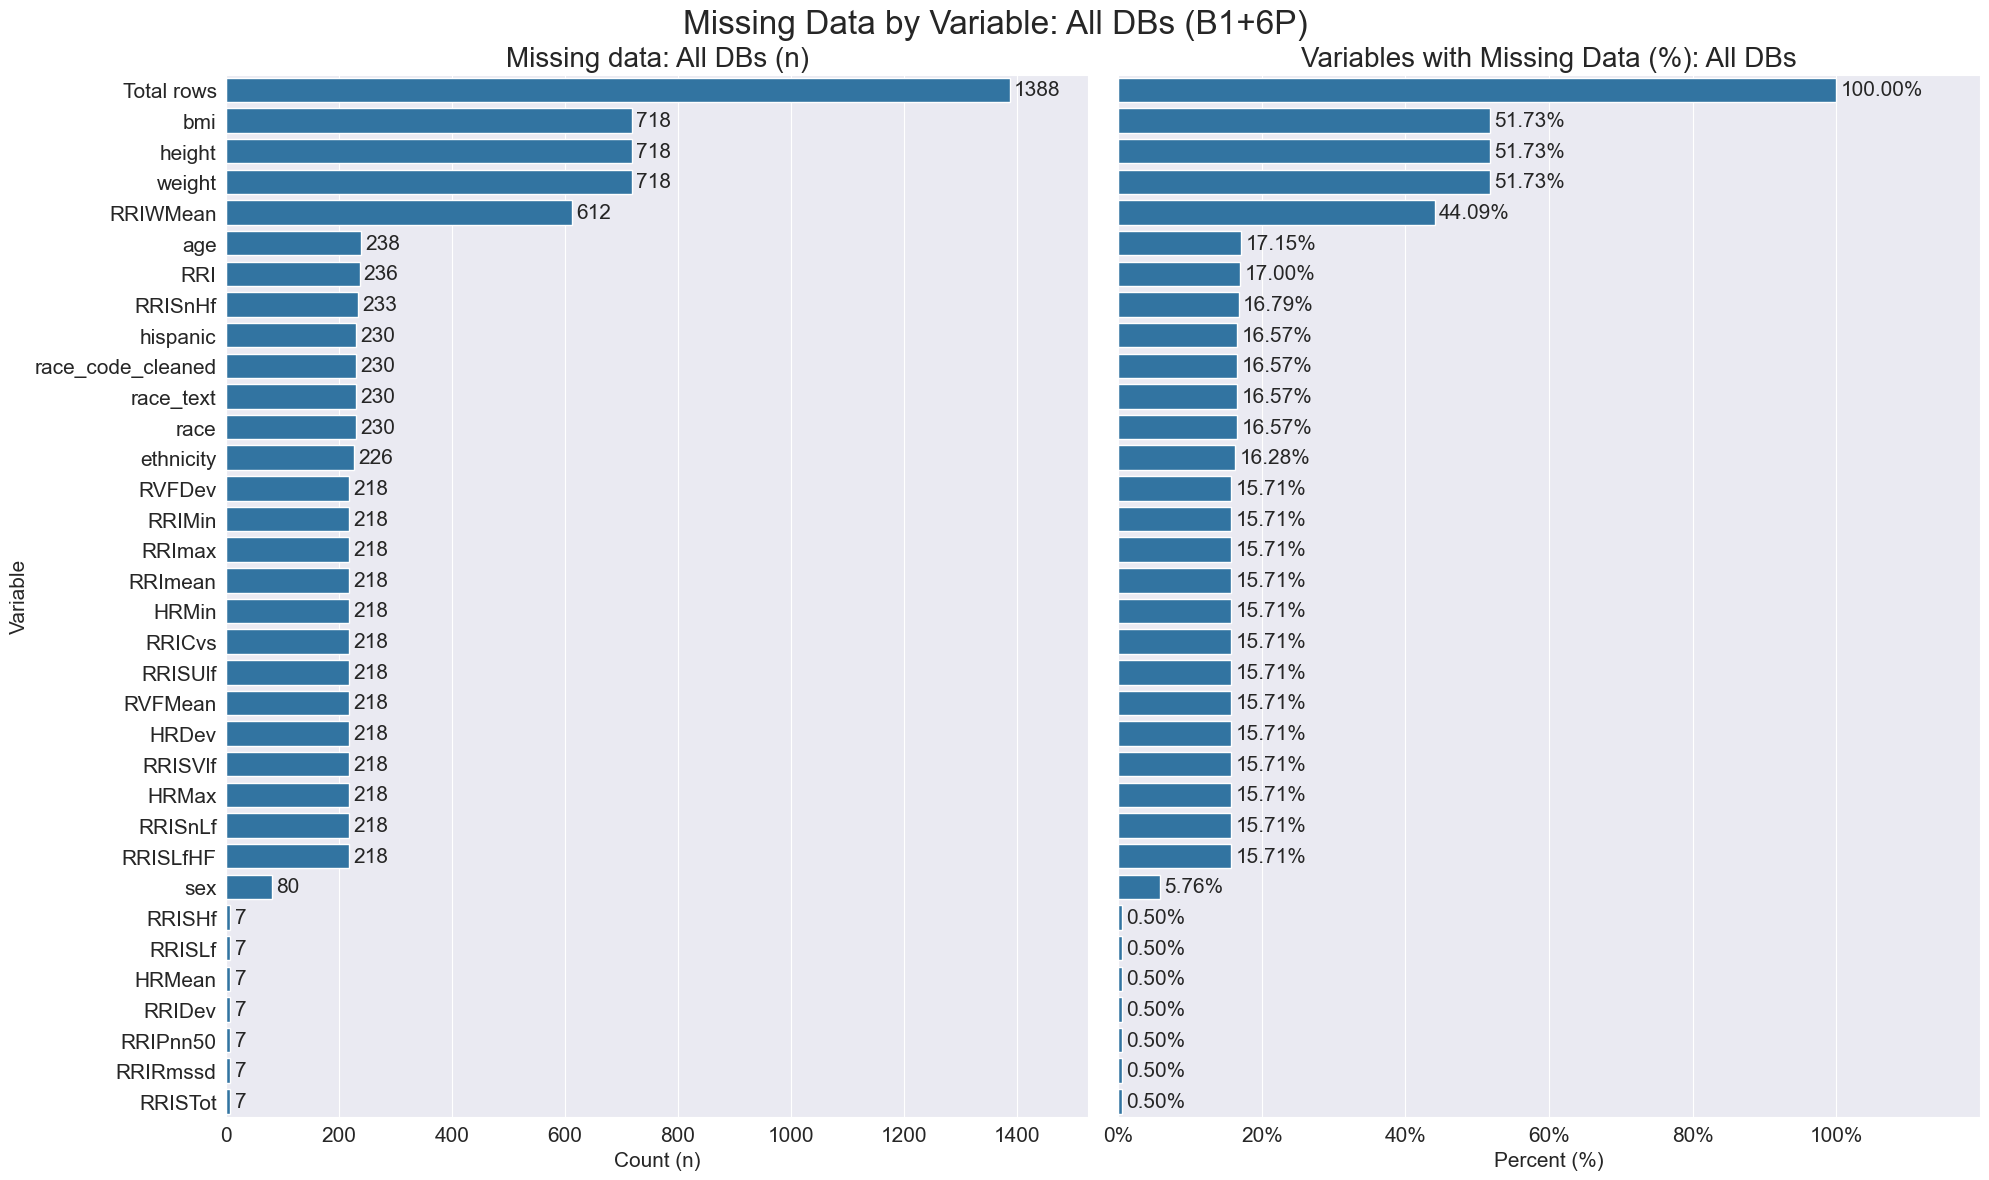

In [25]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1,2,sharey=True, figsize=(20,12))

### Filter_df to only include variables with missing data for better visualization
filtered_df = missing_values_df[missing_values_df['percent_missing'] > 0].copy().reset_index(drop=True)

ax1= sns.barplot(y=filtered_df['column'], x=filtered_df['count'], ax=ax[0])

ax1.set_ylabel('Variable',fontsize=15)
ax1.set_xlabel('Count (n)',fontsize=15)
# ax1.tick_params(axis='x', rotation=-90)
ax1.bar_label(ax1.containers[0], fmt='%.0f', padding=3, fontsize=15)
ax1.tick_params(axis='both', which='major', labelsize=15)
ax1.set_title('Missing data: All DBs (n)', fontsize=20)

#### Second Plot 
ax2= sns.barplot(y=filtered_df['column'], x=filtered_df['percent_missing'], ax=ax[1])

ax2.set_ylabel('Variable', fontsize=15)
ax2.set_xlabel('Percent (%)',fontsize=15)
ax2.set_xticks(np.arange(0,101,20), labels=['0%', '20%', '40%', '60%', '80%', '100%'])
# ax2.tick_params(axis='x', rotation=0)
ax2.tick_params(axis='both', which='major', labelsize=15)
ax2.bar_label(ax2.containers[0], fmt='%.2f%%', padding=3, fontsize=15)
ax2.set_title('Missing data: All DBs (n)', fontsize=20)
ax2.set_title('Variables with Missing Data (%): All DBs', fontsize=20)

fig.suptitle('Missing Data by Variable: All DBs (B1+6P)', fontsize=24)

## increase x-margins
current_max1 = missing_values_df['count'].max()
current_max2 = missing_values_df['percent_missing'].max()
ax1.set_xlim(0, current_max1 * 1.1)
ax2.set_xlim(0, current_max2 * 1.2)

plt.tight_layout()
plt.show()

### Extra observations in dataset check
- Each participant should only have 2 rows of observation
- resolve extra observations as of 05-25-2026

In [26]:
physio_demo_df['ID6'].value_counts().loc[lambda x: x > 2]

Series([], Name: count, dtype: int64)

In [27]:
extra_counts_df = (physio_demo_df['ID6'].value_counts().loc[lambda x: x > 2].index)

In [28]:
physio_demo_df[physio_demo_df['ID6'].isin(extra_counts_df)].sort_values(by='ID6')

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,age,height,weight,bmi,sex,race,race_text,race_code_cleaned,ethnicity,hispanic


In [29]:
physio_demo_df[physio_demo_df['from_study']=='Athlete'][['ID6','timepoint', 'RRI']]

,ID6,timepoint,RRI
1170,220513,B1,NaN
1171,222084,B1,NaN
1172,222513,B1,NaN
1173,222538,B1,NaN
1174,223018,B1,NaN
...,...,...,...
1383,222648,6P,NaN
1384,222750,6P,NaN
1385,222852,6P,NaN
1386,222868,6P,NaN


In [30]:
## Missing RRI by study 
## Used here since we've been consolidating and importing this data
(
    physio_demo_df
    .groupby('from_study', observed=True)['RRI']
    .agg(
        total_count='size',
        rri_count='count',           # non-missing values
        missing_count=lambda x: x.isna().sum()
    )
    .reset_index()
)

,from_study,total_count,rri_count,missing_count
0,Athlete,218,0,218
1,BAA,140,139,1
2,CGE,102,99,3
3,VT1,24,24,0
4,VT2,142,142,0
5,WTP,178,178,0
6,stress_pic,332,332,0
7,stress_prevention,190,190,0
8,stress_suppl,62,48,14


### Adding BMI and BMI categories

- Ranges and terms from CDC

In [31]:
physio_demo_df['bmi_cat'] = physio_demo_df['bmi'].apply(lambda x:
                                                        'Underweight' if x < 18.5 else
                                                        'Healthy weight' if 18.5 <= x < 25 else
                                                        'Overweight' if 25 <= x < 30 else
                                                        'Obese' if x >= 30 else
                                                        np.nan
                                                        )
physio_demo_df['bmi_code_cat'] = physio_demo_df['bmi'].apply(lambda x:
                                                        '1' if x < 18.5 else
                                                        '2' if 18.5 <= x < 25 else
                                                        '3' if 25 <= x < 30 else
                                                        '4' if 30 >= x else
                                                        np.nan
                                                        )
physio_demo_df['bmi_cat'] = pd.Categorical(physio_demo_df['bmi_cat'], categories=['Healthy weight', 'Underweight', 'Overweight', 'Obese'], ordered=True)

physio_demo_df[['ID6', 'from_study', 'bmi', 'bmi_cat', 'bmi_code_cat']].head()


,ID6,from_study,bmi,bmi_cat,bmi_code_cat
0,141000,BAA,NaN,NaN,NaN
1,141001,BAA,NaN,NaN,NaN
2,141002,BAA,NaN,NaN,NaN
3,141003,BAA,NaN,NaN,NaN
4,141005,BAA,NaN,NaN,NaN


In [32]:
bmi_df = physio_demo_df.groupby('bmi_cat', as_index=False, observed=False)['ID6'].count().rename(columns={'ID6': 'count'})

bmi_df['percent'] = ((bmi_df['count'] / bmi_df['count'].sum()) * 100).round(2)

bmi_df

,bmi_cat,count,percent
0,Healthy weight,378,56.42
1,Underweight,20,2.99
2,Overweight,194,28.96
3,Obese,78,11.64


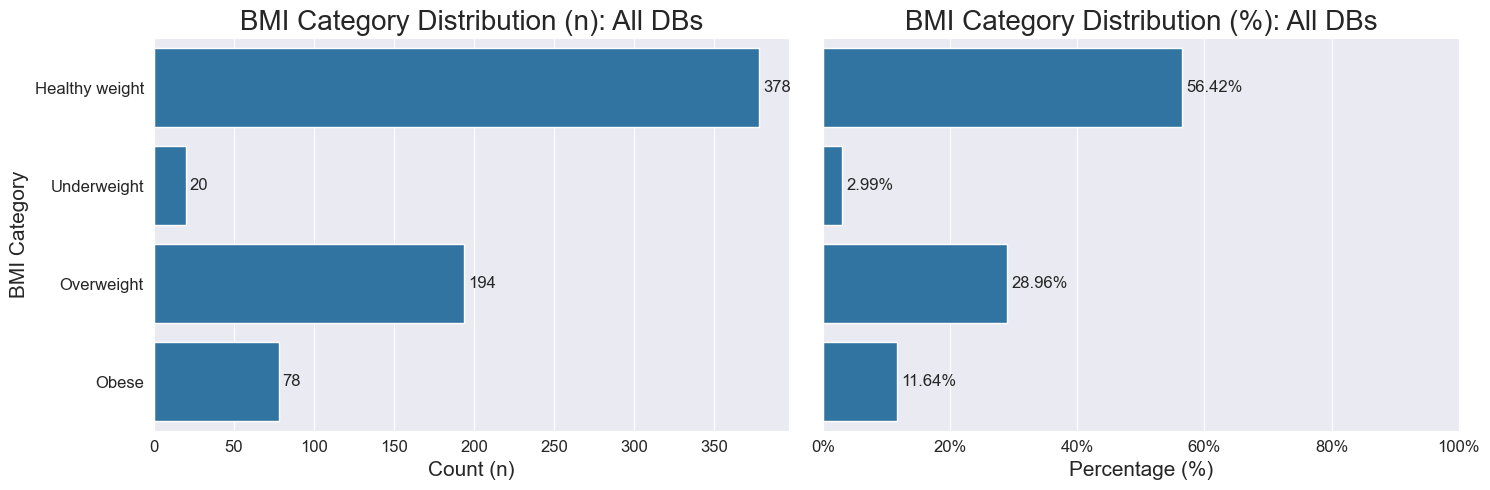

In [33]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1,2,sharey=True, figsize=(15,5))

ax1 = sns.barplot(data=bmi_df, y='bmi_cat', x='count', ax=ax[0])

ax1.bar_label(ax1.containers[0], label_type= 'edge', padding=3, fontsize=12)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.set_ylabel('BMI Category', fontsize=15)
ax1.set_xlabel('Count (n)', fontsize=15)
ax1.set_title('BMI Category Distribution (n): All DBs', fontsize=20)

# ax1.set_yticklabels([''], fontsize=12)

#### Second Plot
ax2 = sns.barplot(data=bmi_df, y='bmi_cat', x='percent', ax=ax[1])

ax2.bar_label(ax2.containers[0], fmt = '%.2f%%',
              label_type= 'edge', padding=3, fontsize=12)

ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.set_xlabel('Percentage (%)', fontsize=15)
ax2.set_xticks(np.arange(0,101,20), labels=[f'{i}%' for i in np.arange(0,101,20)])
ax2.set_title('BMI Category Distribution (%): All DBs', fontsize=20)

plt.tight_layout()

plt.show()

In [34]:
## Making a list of demographic variables for later use

demographic_variables = list(['sex',
                        'bmi_cat',
                         'race',
                         'race_text',
                         'ethnicity',
                         'hispanic']
)

demographic_variables

['sex', 'bmi_cat', 'race', 'race_text', 'ethnicity', 'hispanic']

In [35]:
physio_demo_df[demographic_variables] = physio_demo_df[demographic_variables].astype('category')
physio_demo_df[['from_study', 'timepoint']] = physio_demo_df[['from_study', 'timepoint']].astype('category')

In [36]:
physio_demo_df[demographic_variables].dtypes

sex          category
bmi_cat      category
race         category
race_text    category
ethnicity    category
hispanic     category
dtype: object

### Making subsets of data based on demographic variable completeness.

In [37]:
print("Potential Dataset options for physiological + demographic variables:")
print(f"This dataset includes {physio_demo_df['ID6'].nunique()} unique participants, regardless of demographic data.")

full_rows_df = physio_demo_df.dropna(subset=demographic_variables, axis=0).copy().reset_index(drop=True)
full_rows_b1_df = full_rows_df[full_rows_df['timepoint'] == 'B1'].copy().reset_index(names='n')
print(f"There are {full_rows_b1_df['ID6'].nunique()} unique participants with complete demographic data (age, height, weight, sex, race, ethnicity, hispanic) at baseline (B1).")

full_rows_df = physio_demo_df.dropna(subset=['age'], axis=0).copy().reset_index(drop=True)
full_rows_b1_df = full_rows_df[full_rows_df['timepoint'] == 'B1'].copy().reset_index(names='n')
print(f"There are {full_rows_b1_df['ID6'].nunique()} unique participants with complete age demographic data at baseline (B1).") ## missing 10 age values at B1

full_rows_df = physio_demo_df.dropna(subset=['age', 'height', 'weight'], axis=0).copy().reset_index(drop=True)
full_rows_b1_df = full_rows_df[full_rows_df['timepoint'] == 'B1'].copy().reset_index(names='n')
print(f"There are {full_rows_b1_df['ID6'].nunique()} unique participants with age + height + weight data at baseline (B1).")

full_rows_df = physio_demo_df.dropna(subset=['age', 'race', 'ethnicity'], axis=0).copy().reset_index(drop=True)
full_rows_b1_df = full_rows_df[full_rows_df['timepoint'] == 'B1'].copy().reset_index(names='n')
print(f"There are {full_rows_b1_df['ID6'].nunique()} unique participants with age + race + ethnicity data at baseline (B1).")

Potential Dataset options for physiological + demographic variables:
This dataset includes 694 unique participants, regardless of demographic data.
There are 321 unique participants with complete demographic data (age, height, weight, sex, race, ethnicity, hispanic) at baseline (B1).
There are 575 unique participants with complete age demographic data at baseline (B1).
There are 335 unique participants with age + height + weight data at baseline (B1).
There are 558 unique participants with age + race + ethnicity data at baseline (B1).


In [38]:
full_rows_b1_df.groupby('from_study', as_index=False, observed=True)['ID6'].nunique().rename(columns={'ID6': 'Count (n)'})

,from_study,Count (n)
0,BAA,65
1,CGE,47
2,VT2,68
3,WTP,88
4,stress_pic,165
5,stress_prevention,94
6,stress_suppl,31


In [39]:
## What is still missing from "full demographics rows" at B1 timepoint
missing_table = pd.DataFrame({
    'variable': full_rows_b1_df.columns,
    'missing_count': full_rows_b1_df.isna().sum(),
    'percent_missing': ((full_rows_b1_df.isna().sum() / len(full_rows_b1_df)) * 100).round(2)

}).reset_index(drop=True).sort_values(by='percent_missing', ascending=False)

missing_table[missing_table['percent_missing'] > 0]

,variable,missing_count,percent_missing
38,bmi_code_cat,276,49.46
29,weight,237,42.47
28,height,237,42.47
30,bmi,237,42.47
37,bmi_cat,237,42.47
24,RRIWMean,196,35.13
23,RRI,9,1.61
36,hispanic,2,0.36
22,RRISnHf,1,0.18


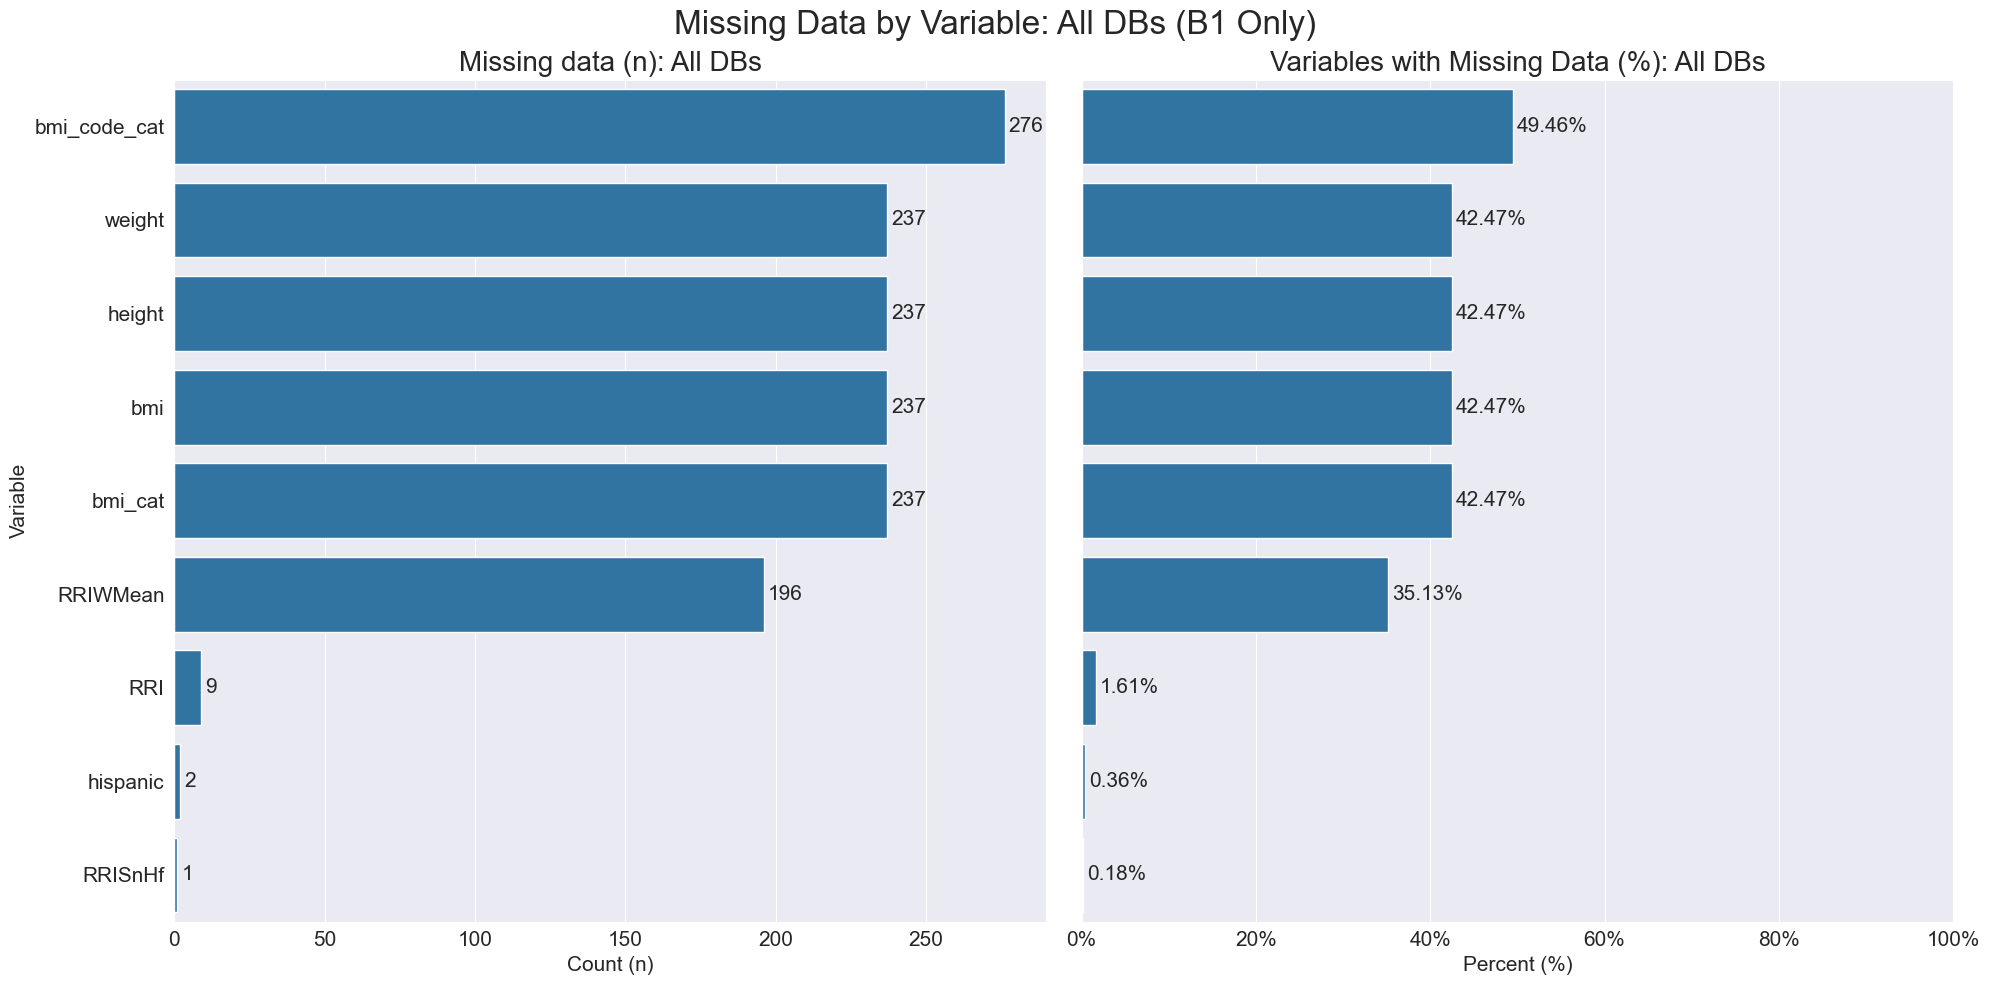

In [40]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1,2,sharey=True, figsize=(20,10))

### Filter_df to only include variables with missing data for better visualization
filtered_df = missing_table[missing_table['percent_missing'] > 0].copy().reset_index(drop=True)

ax1= sns.barplot(y=filtered_df['variable'], x=filtered_df['missing_count'], ax=ax[0])

ax1.set_ylabel('Variable',fontsize=15)
ax1.set_xlabel('Count (n)',fontsize=15)
# ax1.tick_params(axis='x', rotation=-90)
ax1.bar_label(ax1.containers[0], fmt='%.0f', padding=3, fontsize=15)
ax1.tick_params(axis='both', which='major', labelsize=15)
ax1.set_title('Missing data (n): All DBs', fontsize=20)

#### Second Plot 
ax2= sns.barplot(y=filtered_df['variable'], x=filtered_df['percent_missing'], ax=ax[1])

ax2.set_ylabel('Variable', fontsize=15)
ax2.set_xlabel('Percent (%)',fontsize=15)
ax2.set_xticks(np.arange(0,101,20), labels=['0%', '20%', '40%', '60%', '80%', '100%'])
# ax2.tick_params(axis='x', rotation=0)
ax2.tick_params(axis='both', which='major', labelsize=15)
ax2.bar_label(ax2.containers[0], fmt='%.2f%%', padding=3, fontsize=15)
ax2.set_title('Missing data: All DBs (n)', fontsize=20)
ax2.set_title('Variables with Missing Data (%): All DBs', fontsize=20)

fig.suptitle('Missing Data by Variable: All DBs (B1 Only)', fontsize=24)

plt.tight_layout()
plt.show()

### Demographics breakdown at baseline

In [41]:
physio_demo_df_B1 = physio_demo_df[physio_demo_df['timepoint'] == 'B1'].copy().reset_index(drop=True)

physio_demo_df_B1.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,weight,bmi,sex,race,race_text,race_code_cleaned,ethnicity,hispanic,bmi_cat,bmi_code_cat
0,141000,BAA,B1,616.0,791.0,688.0,16.0,0.5,27.0,2.3,...,NaN,NaN,F,2.0,Asian,2.0,1.0,yes,NaN,NaN
1,141001,BAA,B1,462.0,1300.0,1079.0,116.0,59.9,117.0,10.7,...,NaN,NaN,F,6.0,Other,6.0,5.0,no,NaN,NaN
2,141002,BAA,B1,802.0,1560.0,1227.0,148.0,71.8,116.0,12.1,...,NaN,NaN,F,5.0,White,5.0,5.0,no,NaN,NaN
3,141003,BAA,B1,729.0,977.0,843.0,58.0,49.2,54.0,6.9,...,NaN,NaN,F,2.0,Asian,2.0,1.0,yes,NaN,NaN
4,141005,BAA,B1,710.0,1124.0,955.0,79.0,61.3,77.0,8.3,...,NaN,NaN,F,2.0,Asian,2.0,1.0,no,NaN,NaN


### Participant retention from each study 

- Check to see count (n) of participants in MySQL databases, compared to count of participants found in Python after the physio + demographics dfs merge. 
- Difference = the n number of participants lost from data transferrance (incomplete data). I performed a LEFT JOIN to join demographic data onto the physiological data...If we didn't have an individual's physiological data, we weren't going to use them in the data analysis.

In [42]:
## Checking to see how many participants (n) made it from MySQL server to fully merged df at B1 timepoint, by study

study_count_df = physio_demo_df_B1.groupby('from_study', as_index=False, observed=True)['ID6'].nunique().rename(columns={'ID6': 'Count (n)'})

# study_count_df['SQL_count'] = []

study_names = {'BAA': 71, # BAA
'CGE': 90, # CGE
'VT1': 12, # VT1
'VT2': 71, # VT2
'WTP': 89, # WTP
'stress_pic': 166, # stress_pic
'stress_prevention': 95,
'stress_suppl': 31,
## VT3 Here
'Athlete': 251
}

study_count_df['SQL_count'] = study_count_df['from_study'].map(study_names)
study_count_df['n_lost'] = study_count_df['SQL_count'] - study_count_df['Count (n)']

print(study_count_df)

          from_study  Count (n)  SQL_count  n_lost
0            Athlete        109        251     142
1                BAA         70         71       1
2                CGE         51         90      39
3                VT1         12         12       0
4                VT2         71         71       0
5                WTP         89         89       0
6         stress_pic        166        166       0
7  stress_prevention         95         95       0
8       stress_suppl         31         31       0


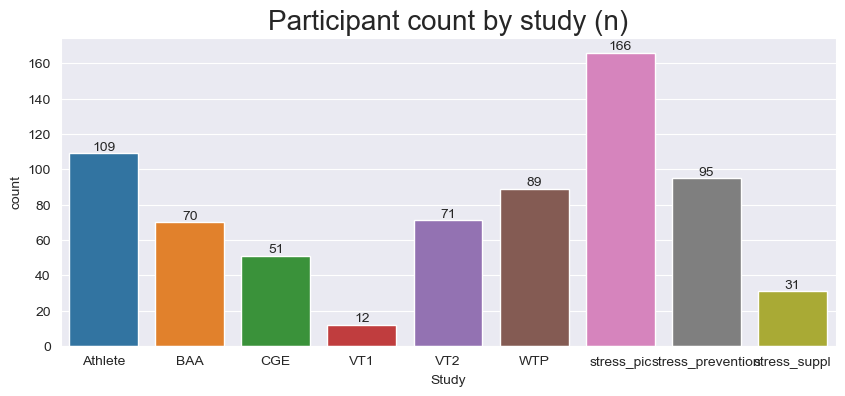

In [43]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.countplot(data=physio_demo_df_B1, x='from_study', hue='from_study')

for container in ax1.containers:
    ax1.bar_label(container, fontsize=10)

plt.title('Participant count by study (n)', fontsize=20)
plt.xlabel('Study')
plt.show()

### Age

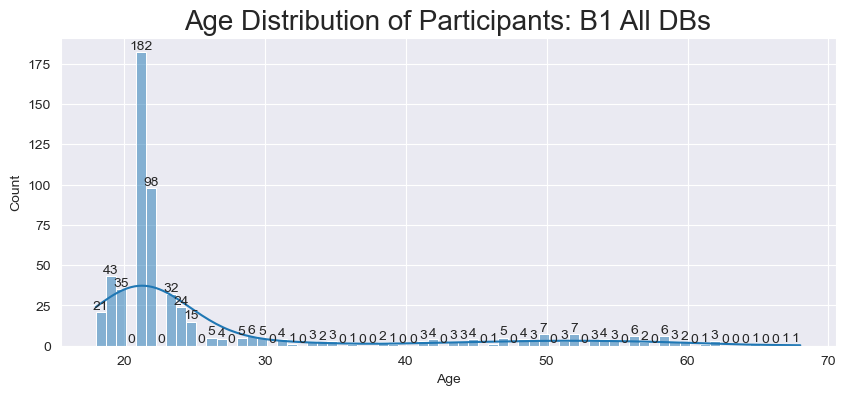

In [44]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=physio_demo_df_B1, x='age', kde=True)

ax1.set_xlabel('Age')
ax1.set_title('Age Distribution of Participants: B1 All DBs', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

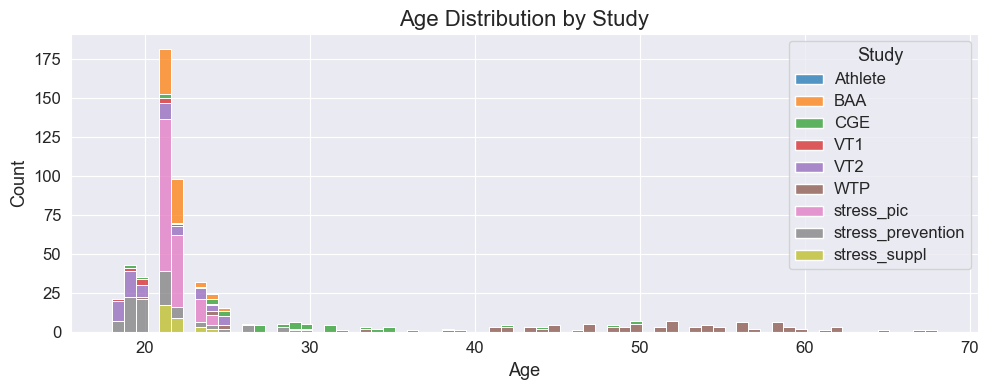

In [45]:
fig, ax = plt.subplots(figsize=(10, 4))

ax1 = sns.histplot(
    data=physio_demo_df_B1,
    x='age',
    hue='from_study',
    multiple='stack'
)

legend = ax1.get_legend()
legend.set_title('Study')
legend.get_title().set_fontsize(13)
for text in legend.get_texts():
    text.set_fontsize(12)

ax1.set_xlabel('Age', fontsize=13)
ax1.set_ylabel('Count', fontsize=13)
ax1.set_title('Age Distribution by Study', fontsize=16)
ax1.tick_params(axis='both', labelsize=12)


plt.tight_layout()
plt.show()

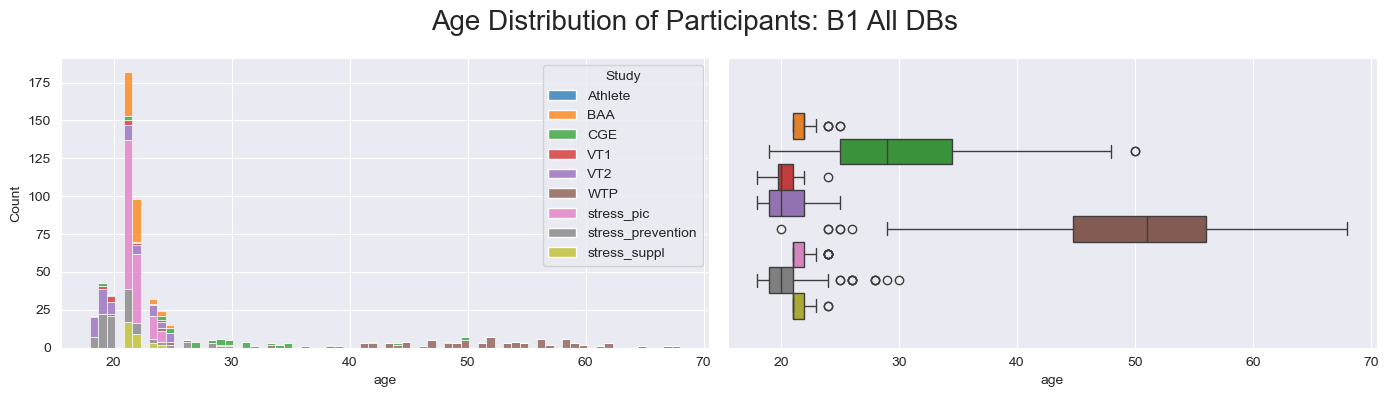

In [46]:
fig, ax = plt.subplots(1,2, figsize=(14,4))

ax1 = sns.histplot(data=physio_demo_df_B1, x='age', hue='from_study', multiple='stack',ax=ax[0])
ax1.get_legend().set_title('Study')

##### second plot
ax2 = sns.boxplot(data= physio_demo_df_B1, x='age', hue='from_study', ax=ax[1])

ax2.get_legend().remove()

plt.suptitle('Age Distribution of Participants: B1 All DBs', fontsize=20)
plt.tight_layout()

plt.show()

### Race

In [47]:
race_df = physio_demo_df_B1.groupby(['race_text']).size().reset_index(name='count')

race_df['percentage'] = (race_df['count']/ race_df['count'].sum()*100).round(2)

race_df = race_df.sort_values(by='percentage', ascending=False)

race_df

/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_66383/2899392366.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  race_df = physio_demo_df_B1.groupby(['race_text']).size().reset_index(name='count')


,race_text,count,percentage
5,White,397,68.57
1,Asian,84,14.51
2,Black or African American,52,8.98
4,Other,34,5.87
3,Native Hawaiian or Other Pacific Islander,9,1.55
0,American Indian or Alaska Native,3,0.52


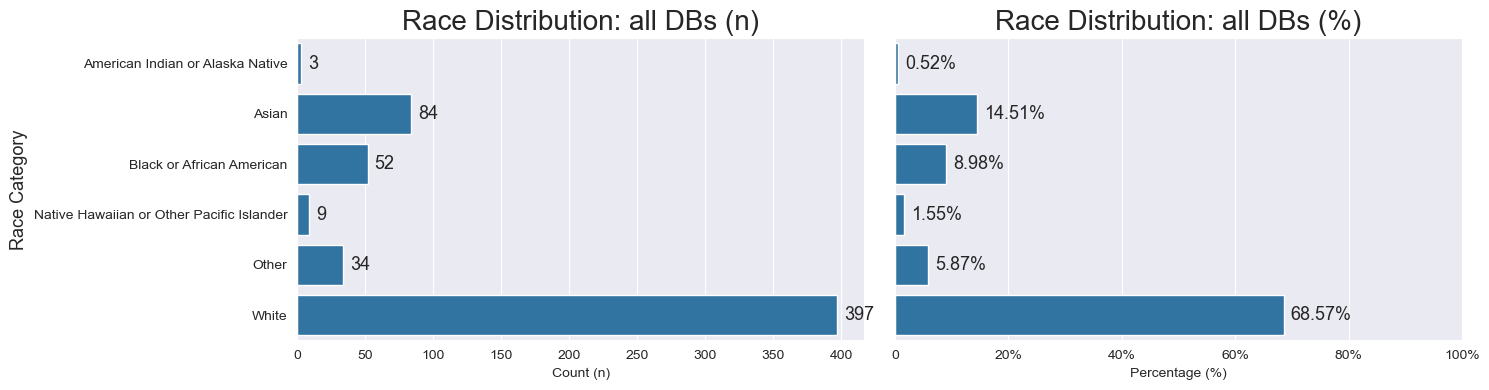

In [48]:
fig, ax = plt.subplots(1,2, sharey=True, figsize=(15,4))

ax1 = sns.barplot(data=race_df, x='count', y='race_text', ax=ax[0])

ax1.set_xlabel('Count (n)')
ax1.set_title('Race Distribution: all DBs (n)', fontsize=20)
ax1.bar_label(ax1.containers[0], fontsize=13, padding=5),
ax1.set_ylabel('Race Category', fontsize=13)

#### second plot
ax2 = sns.barplot(data=race_df, x='percentage', y='race_text', ax=ax[1])

ax2.set_xlabel('Percentage (%)')
ax2.set_title('Race Distribution: all DBs (%)', fontsize=20)
for container in ax2.containers:
    ax2.bar_label(container, labels=[f'{v.get_width():0.2f}%' for v in container], fontsize=13, padding=5)
ax2.set_xticks(np.arange(0,101,20), labels=['0', '20%', '40%', '60%', '80%', '100%'])

plt.tight_layout()
plt.show()

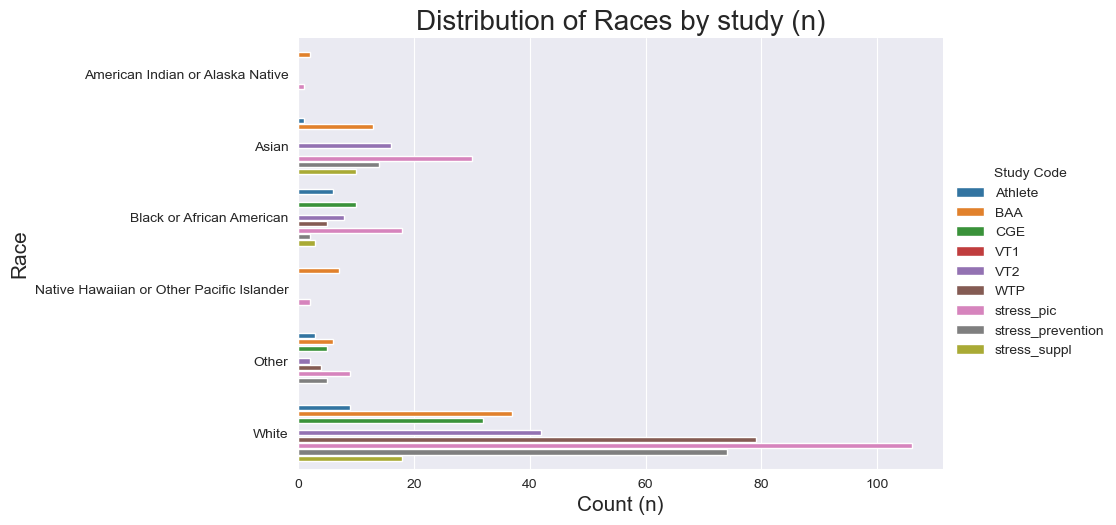

In [49]:
ax1 = sns.catplot(data= physio_demo_df_B1, y='race_text', hue='from_study', kind='count',
                 height= 5,
                 aspect = 2,
                 gap=0.2
)

plt.title('Distribution of Races by study (n)', fontsize=20)
ax1.legend.set_title('Study Code')
ax1.set_axis_labels('Count (n)', 'Race', fontsize=15)
    
plt.show()

### Sex

In [50]:
sex_df = physio_demo_df_B1.groupby(['sex'], observed=True).size().reset_index(name='count')

sex_df['percentage'] = ((sex_df['count'] / sex_df['count'].sum())*100).round(2)

sex_df

,sex,count,percentage
0,F,387,59.17
1,M,267,40.83


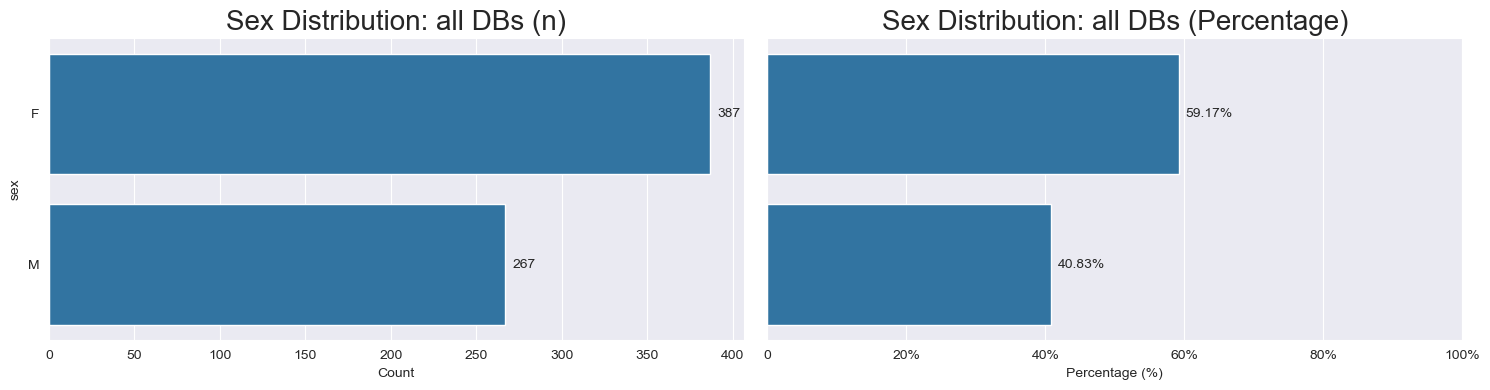

In [51]:
fig, ax = plt.subplots(1,2, sharey=True, figsize=(15,4))

ax1 = sns.barplot(data=sex_df, x='count', y='sex', ax=ax[0])

ax1.set_xlabel('Count')
ax1.set_title('Sex Distribution: all DBs (n)', fontsize=20)
ax1.bar_label(ax1.containers[0], fontsize=10, padding=5),

# ax1.set_xticks(np.arange(0,101,20), labels=['0', '20%', '40%', '60%', '80%', '100%'])


ax2 = sns.barplot(data=sex_df, x='percentage', y='sex', ax=ax[1])

ax2.set_xlabel('Percentage (%)')
ax2.set_title('Sex Distribution: all DBs (Percentage)', fontsize=20)

for container in ax2.containers:
    ax2.bar_label(container, labels=[f'{v.get_width():.2f}%' for v in container], fontsize=10, padding= 5)


ax2.set_xticks(np.arange(0,101,20), labels=['0', '20%', '40%', '60%', '80%', '100%'])
plt.tight_layout()
plt.show()

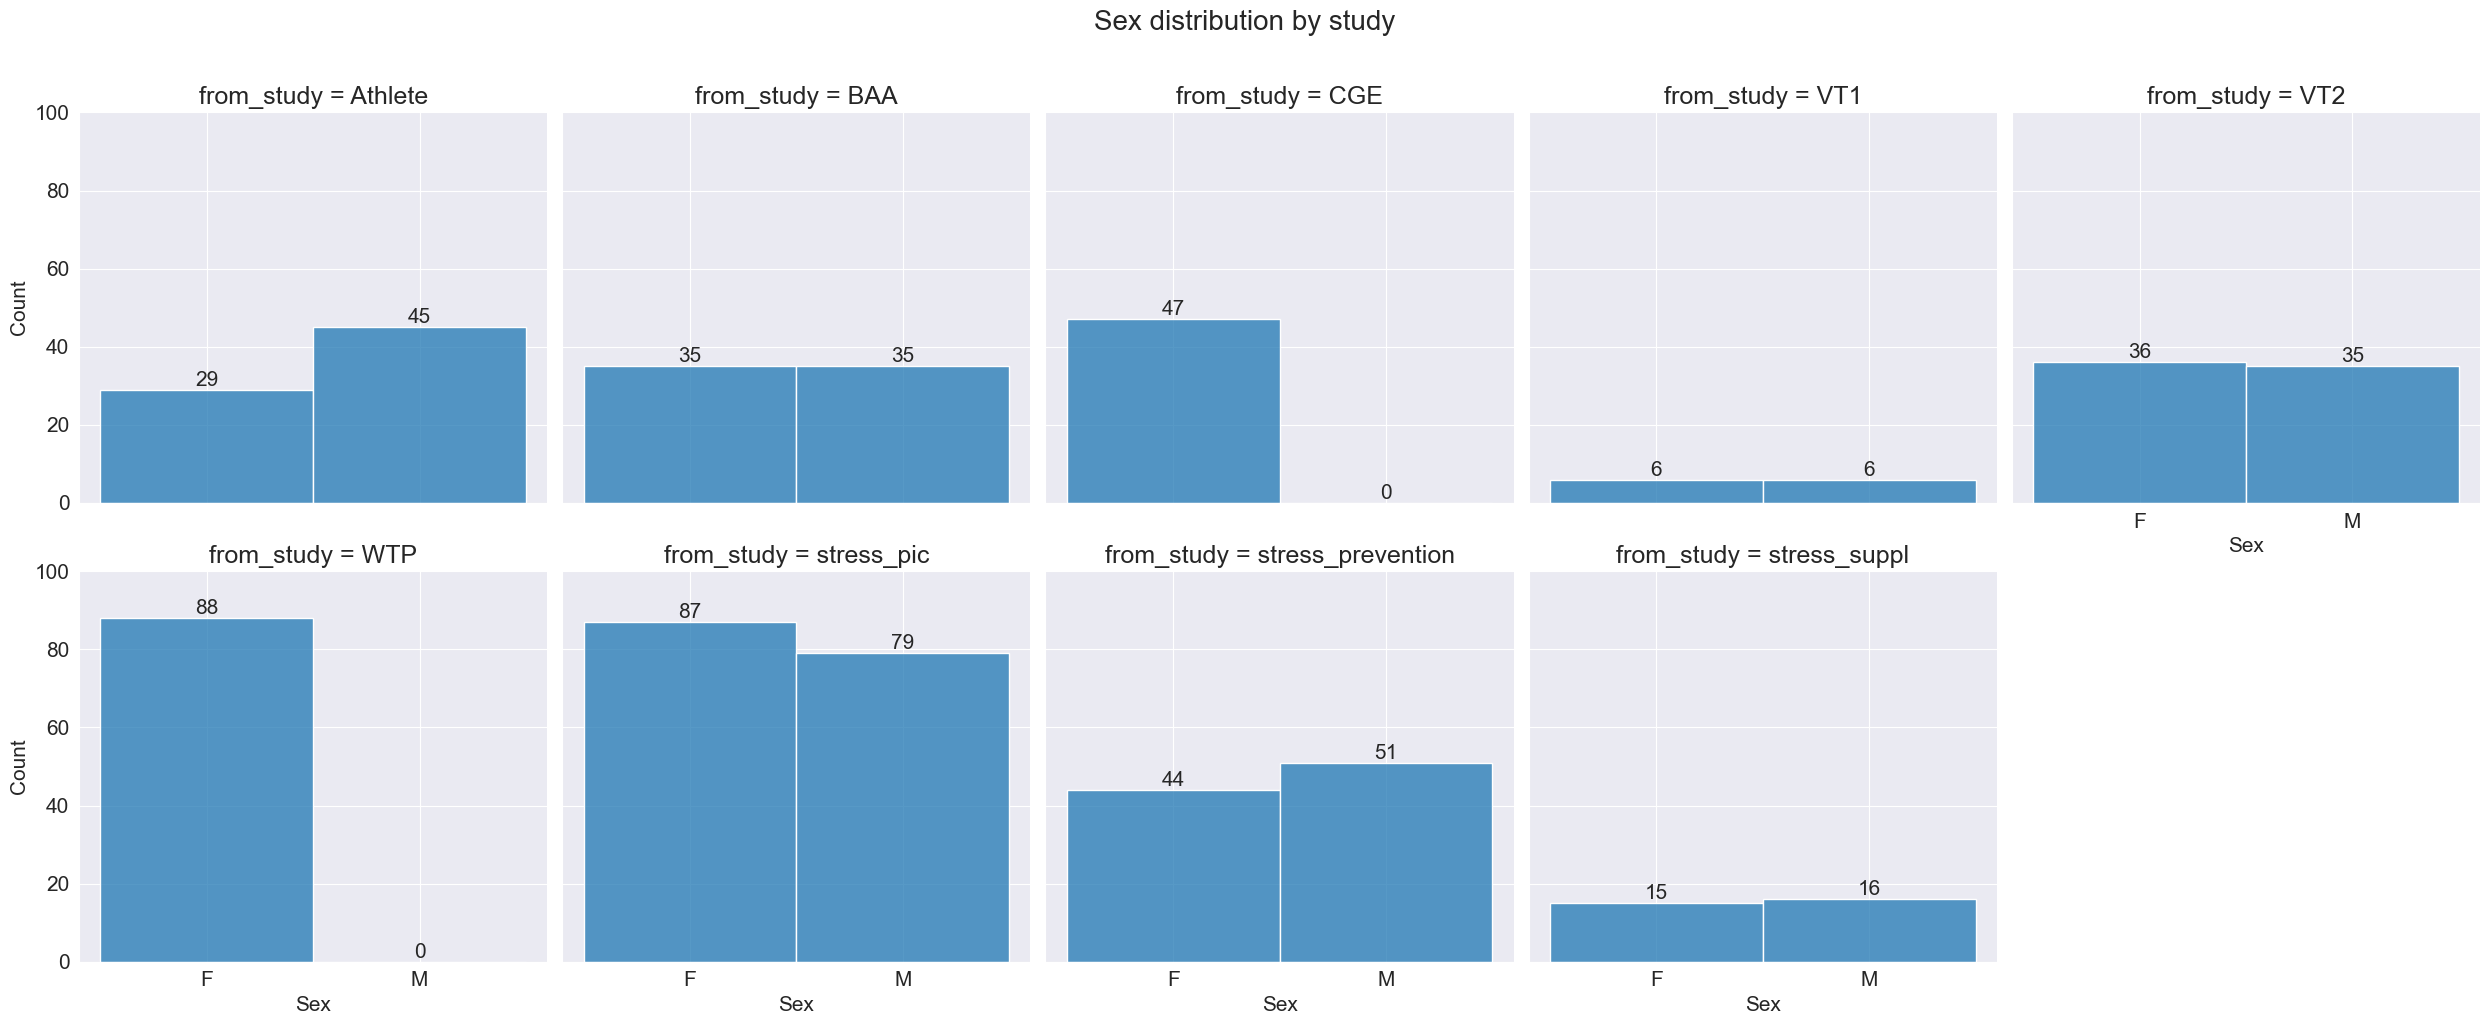

In [52]:
ax1 = sns.displot(
    data=physio_demo_df_B1,
    x='sex',
    col='from_study',
    col_wrap=5,
    # height=4,
    # aspect=1.2
)

for ax in ax1.axes.flat:
    ax.title.set_fontsize(18)
    ax.tick_params(axis='both', labelsize=15)
    if ax.containers:
        ax.bar_label(ax.containers[0], fontsize=15)
    ax.set_xlabel('Sex', fontsize=15)
    ax.set_ylabel('Count',fontsize=15)
    ax.set_yticks(np.arange(0,101,20))

plt.suptitle('Sex distribution by study', y=1.02, fontsize=20)

plt.tight_layout()
plt.show()

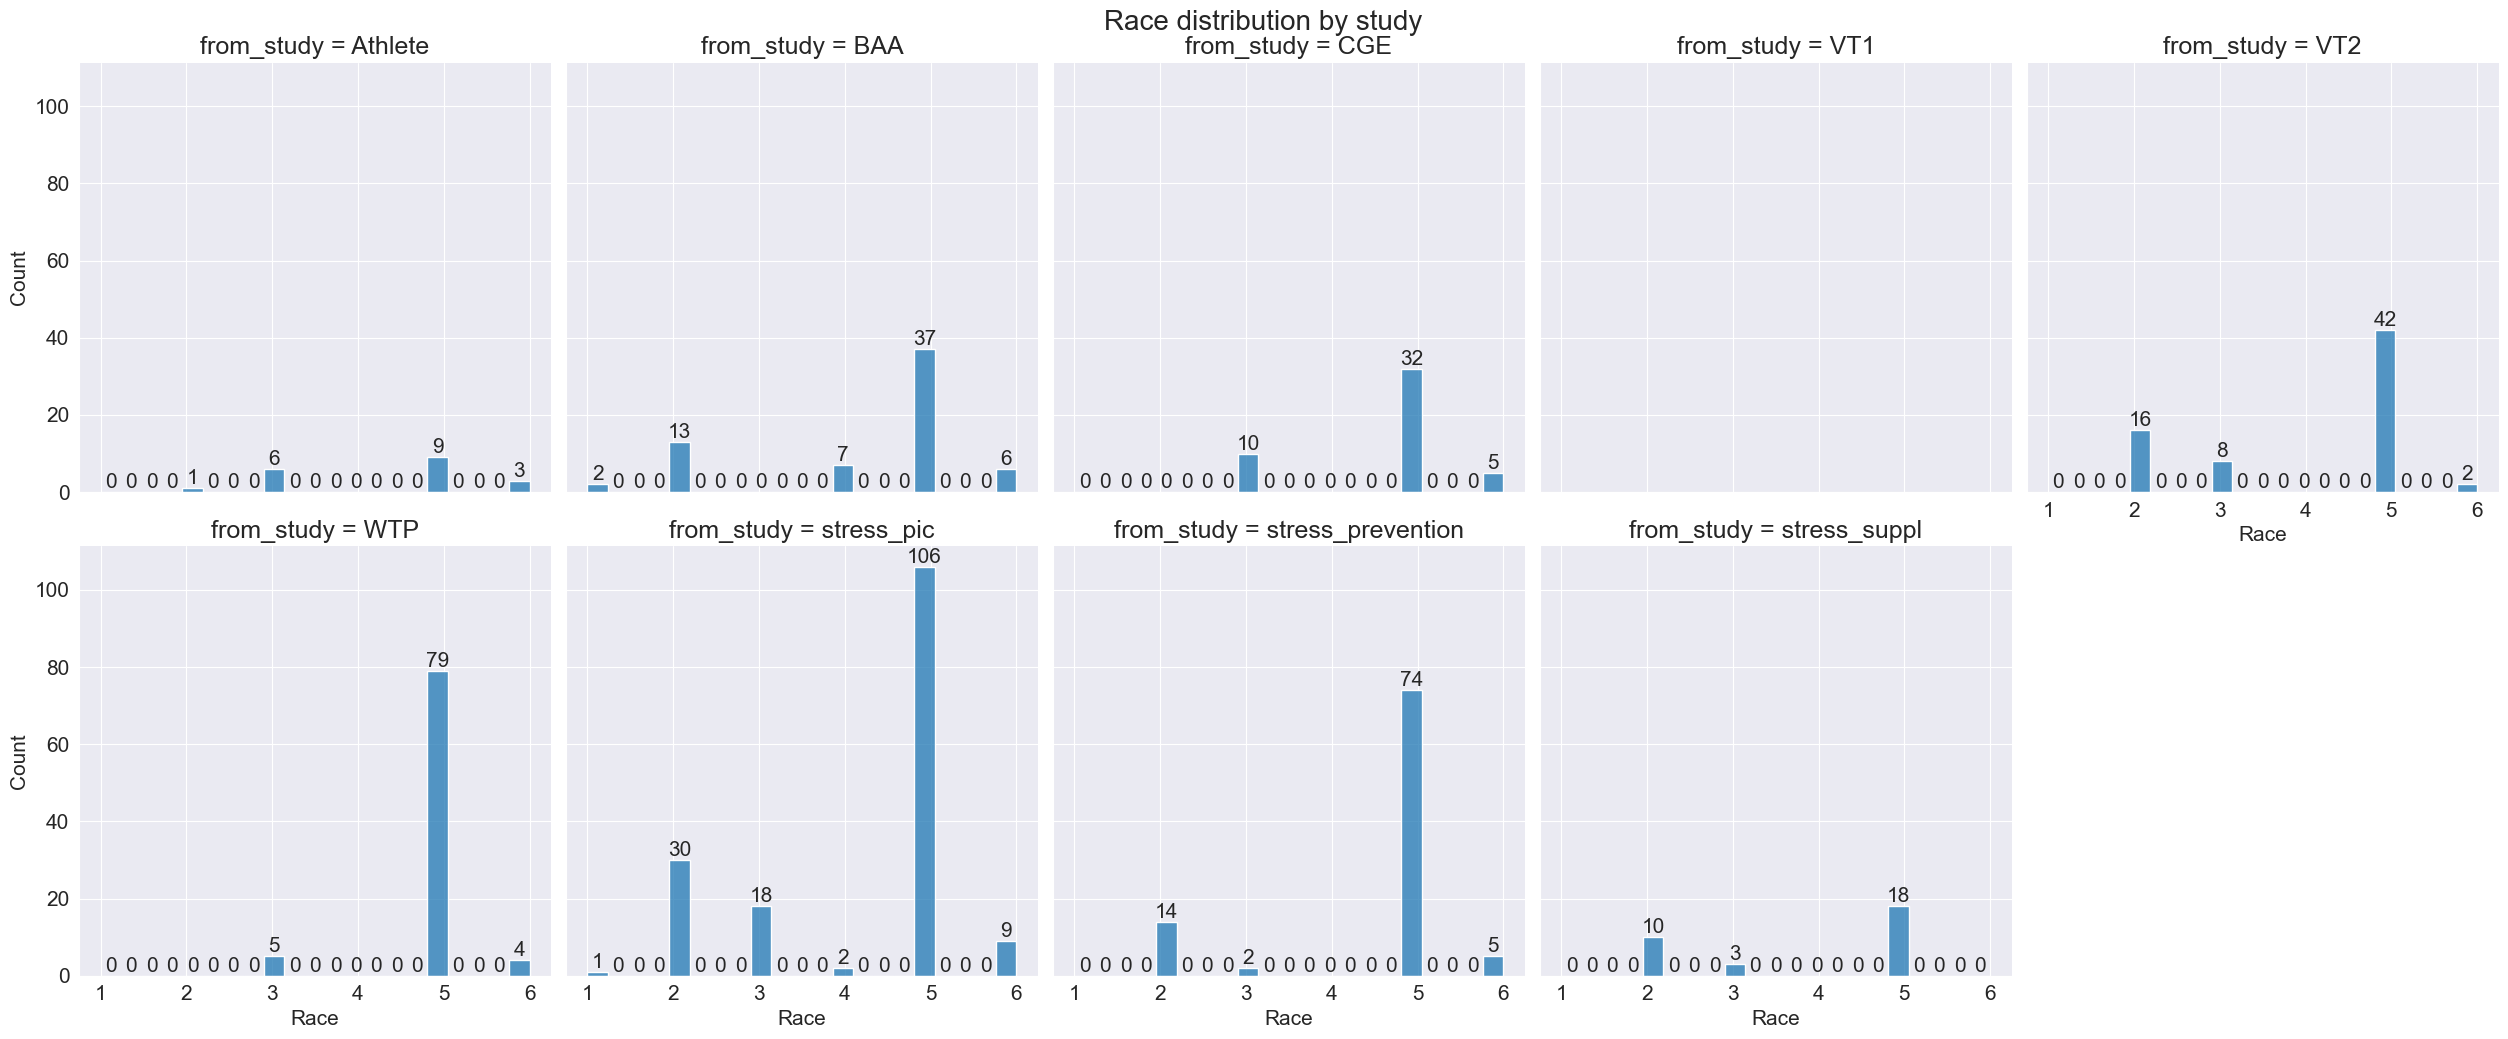

In [53]:
ax1 = sns.displot(
    data=physio_demo_df_B1,
    x='race_code_cleaned',
    col='from_study',
    col_wrap=5,
    # height=4,
    # aspect=1.2
)

for ax in ax1.axes.flat:
    ax.title.set_fontsize(18)
    ax.tick_params(axis='both', labelsize=15)
    if ax.containers:
        ax.bar_label(ax.containers[0], fontsize=15)
    ax.set_xlabel('Race', fontsize=15)
    ax.set_ylabel('Count',fontsize=15)
    ax.set_yticks(np.arange(0,101,20))

plt.suptitle('Race distribution by study', y=1.02, fontsize=20)

# plt.tight_layout()
plt.show()

In [54]:
demo_df_sex_race = physio_demo_df_B1.groupby(['sex', 'race_text'], observed=True).size().reset_index(name='count')

demo_df_sex_race['percentage'] = ((demo_df_sex_race['count'] / demo_df_sex_race['count'].sum())*100).round(2)

demo_df_sex_race.sort_values(by=['race_text','percentage'], ascending=[False,True]).reset_index(drop=True, inplace=True)

demo_df_sex_race

,sex,race_text,count,percentage
0,F,American Indian or Alaska Native,2,0.35
1,F,Asian,45,7.77
2,F,Black or African American,36,6.22
3,F,Native Hawaiian or Other Pacific Islander,7,1.21
4,F,Other,19,3.28
5,F,White,249,43.01
6,M,American Indian or Alaska Native,1,0.17
7,M,Asian,39,6.74
8,M,Black or African American,16,2.76
9,M,Native Hawaiian or Other Pacific Islander,2,0.35


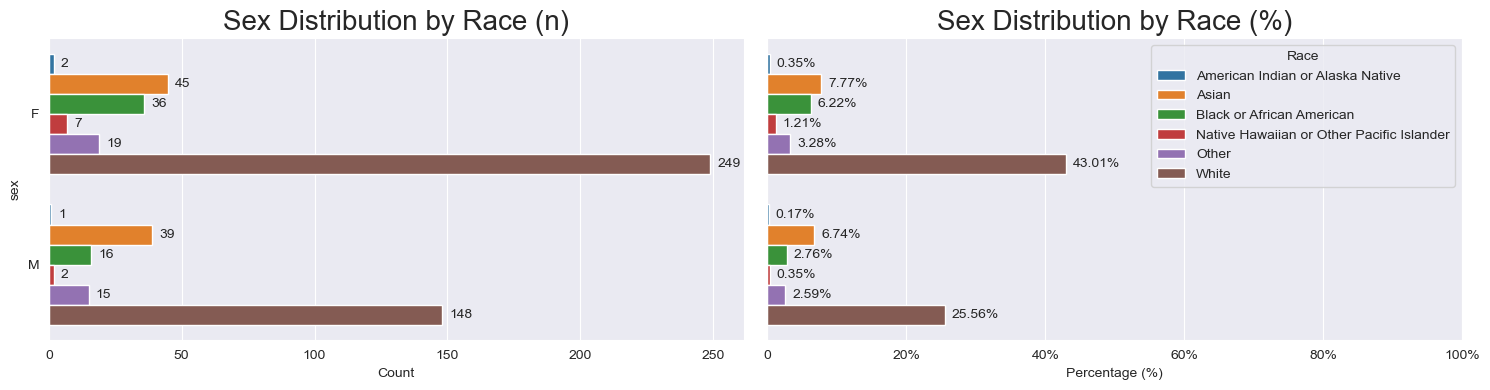

In [55]:
fig, ax = plt.subplots(1,2, sharey=True, figsize=(15,4))

ax1 = sns.barplot(data=demo_df_sex_race, x='count', y='sex',hue='race_text', errorbar=None, ax=ax[0])


ax1.set_xlabel('Count')
ax1.set_title('Sex Distribution by Race (n)', fontsize=20)

for container in ax1.containers:
    ax1.bar_label(container, fontsize=10, padding=5)


ax1.get_legend().remove()

ax2 = sns.barplot(data=demo_df_sex_race, x='percentage', y='sex', hue='race_text', errorbar=None, ax=ax[1])

ax2.set_xlabel('Percentage (%)')
ax2.set_title('Sex Distribution by Race (%)', fontsize=20)

for container in ax2.containers:
    ax2.bar_label(container, labels=[f'{v.get_width():.2f}%' for v in container], fontsize=10, padding= 5)

ax2.set_xticks(np.arange(0,101,20), labels=['0', '20%', '40%', '60%', '80%', '100%'])

ax2.get_legend().set_title('Race')

plt.tight_layout()
plt.show()

### Quick reference plot of all demographic variables side-by-side.

/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_66383/4065070038.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right', fontsize=12)
/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_66383/4065070038.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax6.set_xticklabels(ax6.get_xticklabels(), rotation=45, ha='right', fontsize=12)


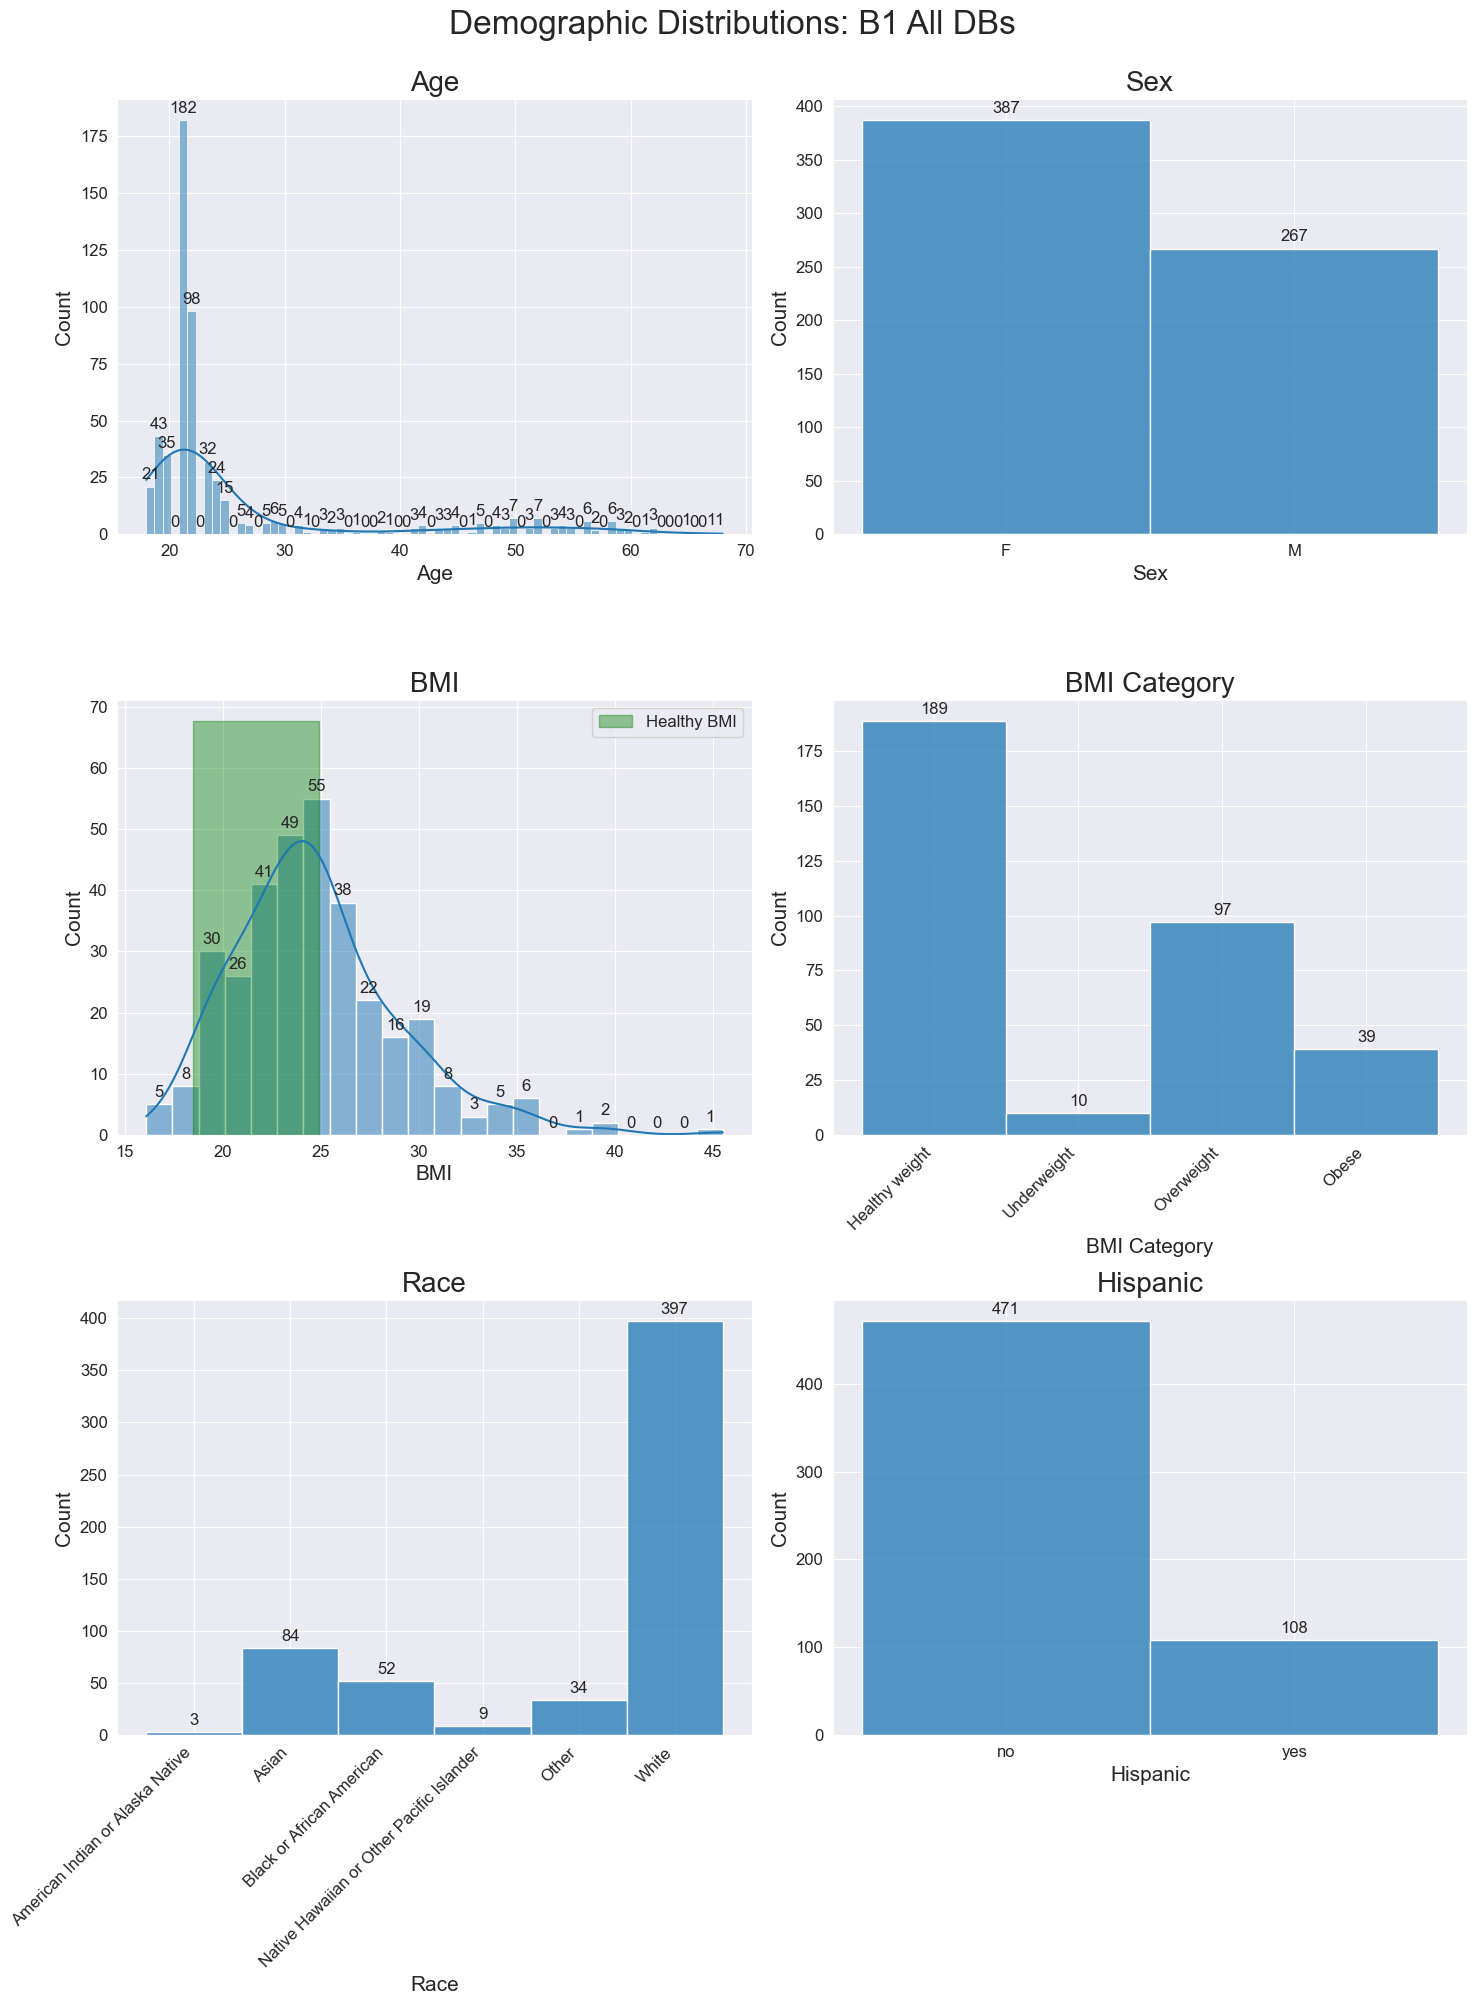

In [56]:
fig, ax = plt.subplots(3,2, figsize=(15,20))

ax1 = sns.histplot(data=physio_demo_df_B1, x='age',kde=True, ax=ax[0,0])
ax1.bar_label(ax1.containers[0], fontsize=12, padding=3)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.set_title('Age', fontsize=20)
ax1.set_ylabel('Count', fontsize=15)
ax1.set_xlabel('Age', fontsize=15)

ax2 = sns.histplot(data=physio_demo_df_B1, x='sex', ax=ax[0,1])
ax2.bar_label(ax2.containers[0], fontsize=12, padding=3)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.set_title('Sex', fontsize=20)
ax2.set_ylabel('Count', fontsize=15)
ax2.set_xlabel('Sex', fontsize=15)

ax3 = sns.histplot(data=physio_demo_df_B1, x='bmi', kde=True, ax=ax[1,0])
ax3.bar_label(ax3.containers[0], fontsize=12, padding=3)
ax3.tick_params(axis='both', which='major', labelsize=12)
ax3.set_xticks(np.arange(0,51,5))
ax3.set_title('BMI', fontsize=20)
ax3.set_ylabel('Count', fontsize=15)
ax3.set_xlabel('BMI', fontsize=15)
ax3.fill_between(x=[18.5, 24.9], y1=0, y2=ax3.get_ylim()[1]+10, color='green', alpha=0.4, label='Healthy BMI')
ax3.legend(fontsize=12)

ax4 = sns.histplot(data=physio_demo_df_B1, x='bmi_cat', ax=ax[1,1])
ax4.bar_label(ax4.containers[0], fontsize=12, padding=3)
ax4.tick_params(axis='both', which='major', labelsize=12)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right', fontsize=12)
ax4.set_title('BMI Category', fontsize=20)
ax4.set_ylabel('Count', fontsize=15)
ax4.set_xlabel('BMI Category', fontsize=15)

# ax5 = sns.histplot(data=physio_demo_df_B1, x='bmi_cat_simple'

ax6 = sns.histplot(data=physio_demo_df_B1, x='race_text', ax=ax[2,0])
ax6.bar_label(ax6.containers[0], fontsize=12, padding=3)
ax6.tick_params(axis='both', which='major', labelsize=12)
ax6.set_xticklabels(ax6.get_xticklabels(), rotation=45, ha='right', fontsize=12)
ax6.set_title('Race', fontsize=20)
ax6.set_ylabel('Count', fontsize=15)
ax6.set_xlabel('Race', fontsize=15)

ax7 = sns.histplot(data=physio_demo_df_B1, x='hispanic', ax=ax[2,1])
ax7.bar_label(ax7.containers[0], fontsize=12, padding=3)
ax7.tick_params(axis='both', which='major', labelsize=12)
ax7.set_title('Hispanic', fontsize=20)
ax7.set_ylabel('Count', fontsize=15)
ax7.set_xlabel('Hispanic', fontsize=15)

plt.suptitle('Demographic Distributions: B1 All DBs', fontsize=24, y=1.0)
plt.tight_layout()
plt.show()

# Export full dataset

In [57]:
physio_demo_df.to_excel("physio_demo_data_cleaned_06.01.26.xlsx", index=False)

## Placing data export here for full df as everything is cleaned before looking at individual DB datasets.

# Individual Study (database) Exploratory Data Analysis

### Create individual dfs for each database to explore each dataset's characteristics

In [58]:
## Loop through physio_demo_df to create new sub_dfs (e.g., baa_df)

dataset_names = list(physio_demo_df['from_study'].unique())

dataset_names

## noting that VT3 isn't in here yet, nor is Athlete

['BAA',
 'CGE',
 'stress_pic',
 'stress_prevention',
 'stress_suppl',
 'VT1',
 'VT2',
 'WTP',
 'Athlete']

In [59]:
## get the list of unique dataset names from the 'from_study' column in physio_demo_df, then loop through that list to create new dataframes for each dataset (e.g., baa_df, etc.)
dataset_names = list(physio_demo_df['from_study'].unique())
### missing VT3 for some reason
print(dataset_names)


['BAA', 'CGE', 'stress_pic', 'stress_prevention', 'stress_suppl', 'VT1', 'VT2', 'WTP', 'Athlete']


In [60]:
## Run the loop to create the new dataframes for each dataset (e.g., baa_df, etc.)

for dataset in dataset_names:
    globals()[f"{dataset}_df"] = physio_demo_df[physio_demo_df['from_study'] == dataset].copy().reset_index(drop=True)

### BAA data

In [61]:
BAA_df.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,weight,bmi,sex,race,race_text,race_code_cleaned,ethnicity,hispanic,bmi_cat,bmi_code_cat
0,141000,BAA,B1,616.0,791.0,688.0,16.0,0.5,27.0,2.3,...,NaN,NaN,F,2.0,Asian,2.0,1.0,yes,NaN,NaN
1,141001,BAA,B1,462.0,1300.0,1079.0,116.0,59.9,117.0,10.7,...,NaN,NaN,F,6.0,Other,6.0,5.0,no,NaN,NaN
2,141002,BAA,B1,802.0,1560.0,1227.0,148.0,71.8,116.0,12.1,...,NaN,NaN,F,5.0,White,5.0,5.0,no,NaN,NaN
3,141003,BAA,B1,729.0,977.0,843.0,58.0,49.2,54.0,6.9,...,NaN,NaN,F,2.0,Asian,2.0,1.0,yes,NaN,NaN
4,141005,BAA,B1,710.0,1124.0,955.0,79.0,61.3,77.0,8.3,...,NaN,NaN,F,2.0,Asian,2.0,1.0,no,NaN,NaN


In [62]:
baa_missing_values_df = pd.DataFrame({
    'count': BAA_df.isnull().sum(),
    'percent': (BAA_df.isnull().sum() / len(BAA_df)) * 100 
}).sort_values(by='percent', ascending=False).round(2).reset_index().rename(columns={'index': 'column'})

print(baa_missing_values_df)

               column  count  percent
0        bmi_code_cat    140   100.00
1              weight    140   100.00
2              height    140   100.00
3                 bmi    140   100.00
4             bmi_cat    140   100.00
5            hispanic     14    10.00
6           ethnicity     10     7.14
7   race_code_cleaned     10     7.14
8           race_text     10     7.14
9                race     10     7.14
10                age     10     7.14
11                RRI      1     0.71
12                sex      0     0.00
13         from_study      0     0.00
14             RVFDev      0     0.00
15            RVFMean      0     0.00
16           RRIWMean      0     0.00
17            RRISnHf      0     0.00
18            RRISnLf      0     0.00
19                ID6      0     0.00
20             RRISHf      0     0.00
21             RRISLf      0     0.00
22          timepoint      0     0.00
23             RRIMin      0     0.00
24             RRImax      0     0.00
25          

In [63]:
baa_missing_cols_only = baa_missing_values_df[baa_missing_values_df['percent']>0].copy().reset_index(drop=True)

baa_missing_cols_only

,column,count,percent
0,bmi_code_cat,140,100.00
1,weight,140,100.00
2,height,140,100.00
3,bmi,140,100.00
4,bmi_cat,140,100.00
5,hispanic,14,10.00
6,ethnicity,10,7.14
7,race_code_cleaned,10,7.14
8,race_text,10,7.14
9,race,10,7.14


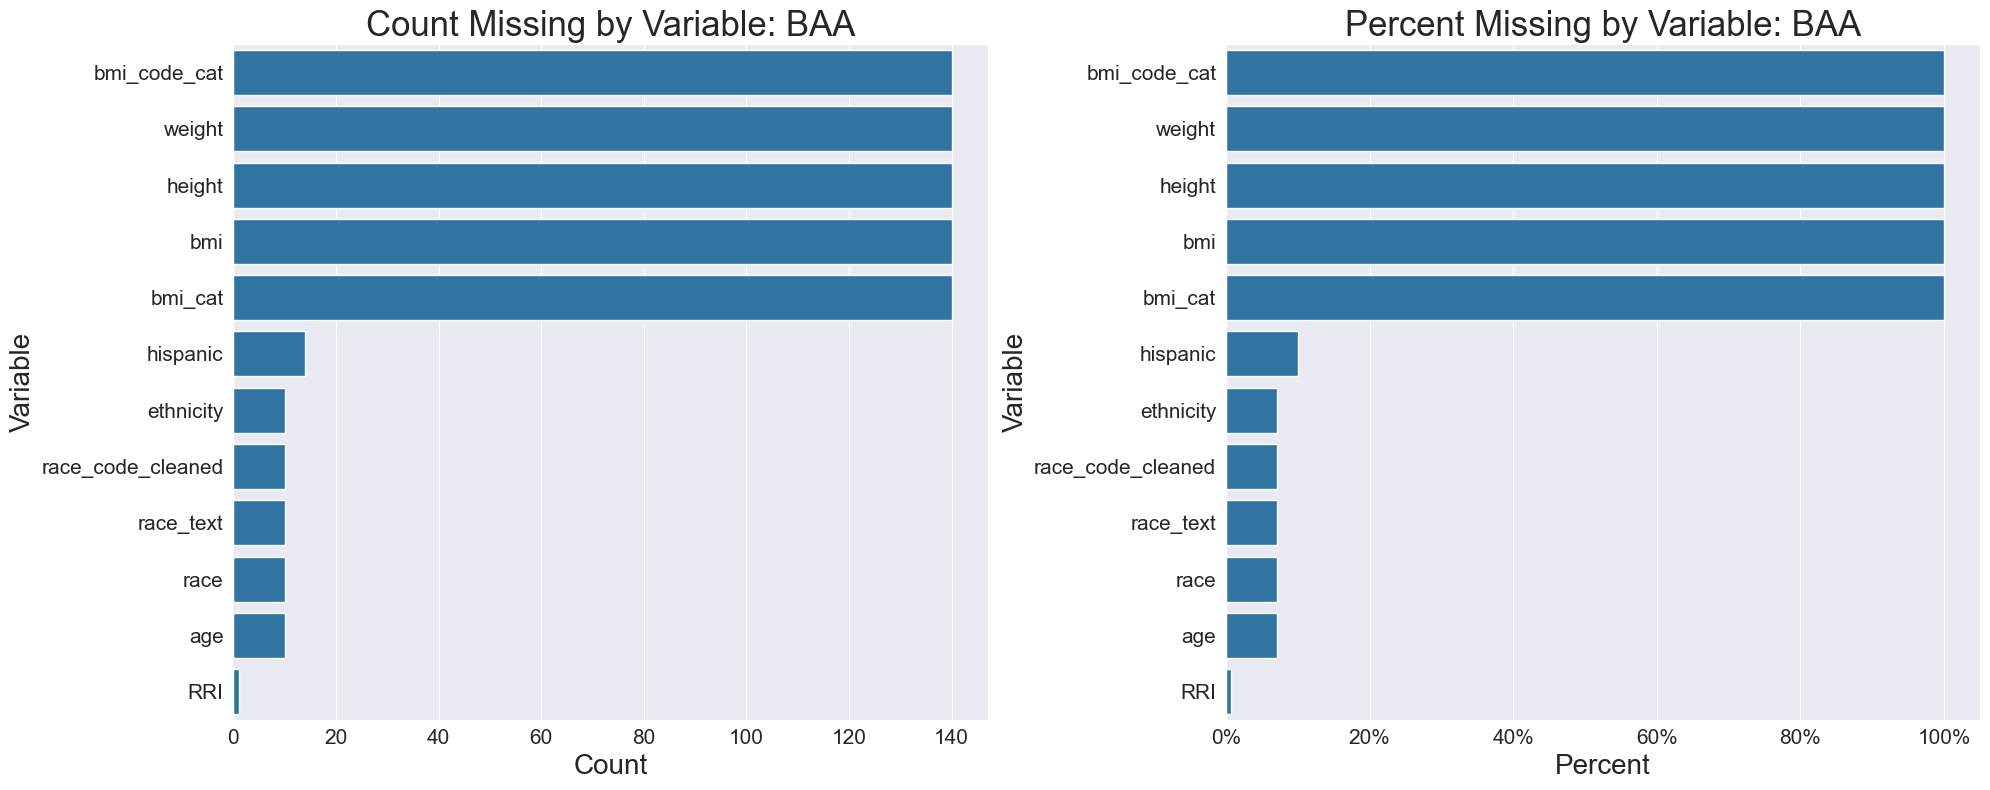

In [64]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1,2,figsize=(20,8))

### Plot 1: Count missing by variable
ax1= sns.barplot(x=baa_missing_cols_only['count'], y=baa_missing_cols_only['column'], ax=ax[0])

ax1.set_xlabel('Count', fontsize=20)
ax1.set_ylabel('Variable', fontsize=20)
ax1.tick_params(axis='both', labelsize=15)

ax1.set_title('Count Missing by Variable: BAA', fontsize=25)


### Plot 2- Percent missing by variable
ax2= sns.barplot(x=baa_missing_cols_only['percent'], y=baa_missing_cols_only['column'], ax=ax[1])

ax2.set_xlabel('Percent', fontsize=20)
ax2.set_ylabel('Variable', fontsize=20)
ax2.set_xticks(np.arange(0,101,20), labels=['0%', '20%', '40%', '60%', '80%', '100%'])
ax2.tick_params(axis='both', labelsize=15)


ax2.set_title('Percent Missing by Variable: BAA', fontsize=25)

plt.tight_layout()
plt.show()

In [65]:
### BAA demographics

BAA_b1_df = BAA_df[BAA_df['timepoint'] == 'B1'].copy().reset_index(drop=True)

BAA_b1_df.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,weight,bmi,sex,race,race_text,race_code_cleaned,ethnicity,hispanic,bmi_cat,bmi_code_cat
0,141000,BAA,B1,616.0,791.0,688.0,16.0,0.5,27.0,2.3,...,NaN,NaN,F,2.0,Asian,2.0,1.0,yes,NaN,NaN
1,141001,BAA,B1,462.0,1300.0,1079.0,116.0,59.9,117.0,10.7,...,NaN,NaN,F,6.0,Other,6.0,5.0,no,NaN,NaN
2,141002,BAA,B1,802.0,1560.0,1227.0,148.0,71.8,116.0,12.1,...,NaN,NaN,F,5.0,White,5.0,5.0,no,NaN,NaN
3,141003,BAA,B1,729.0,977.0,843.0,58.0,49.2,54.0,6.9,...,NaN,NaN,F,2.0,Asian,2.0,1.0,yes,NaN,NaN
4,141005,BAA,B1,710.0,1124.0,955.0,79.0,61.3,77.0,8.3,...,NaN,NaN,F,2.0,Asian,2.0,1.0,no,NaN,NaN


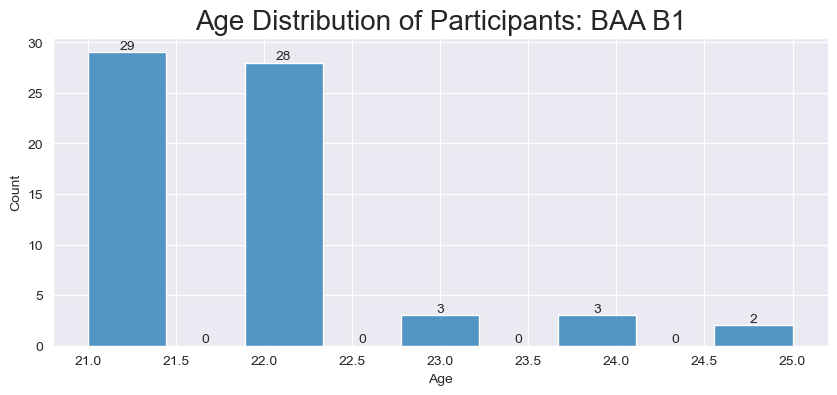

In [66]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=BAA_b1_df, x='age')

ax1.set_xlabel('Age')
ax1.set_title('Age Distribution of Participants: BAA B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

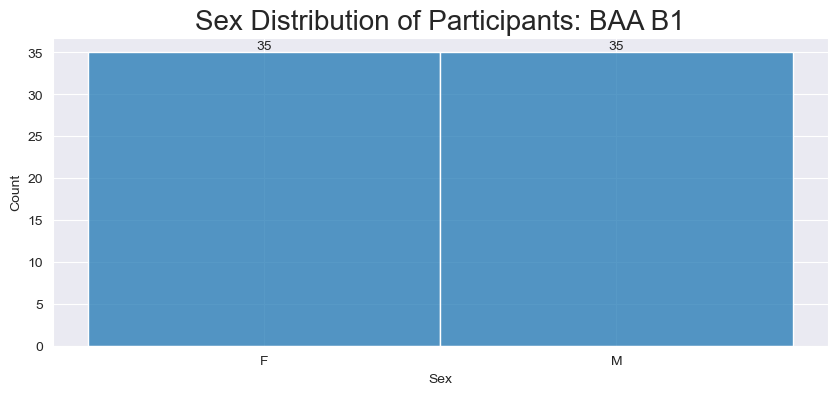

In [67]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=BAA_b1_df, x='sex')

ax1.set_xlabel('Sex')
ax1.set_title('Sex Distribution of Participants: BAA B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

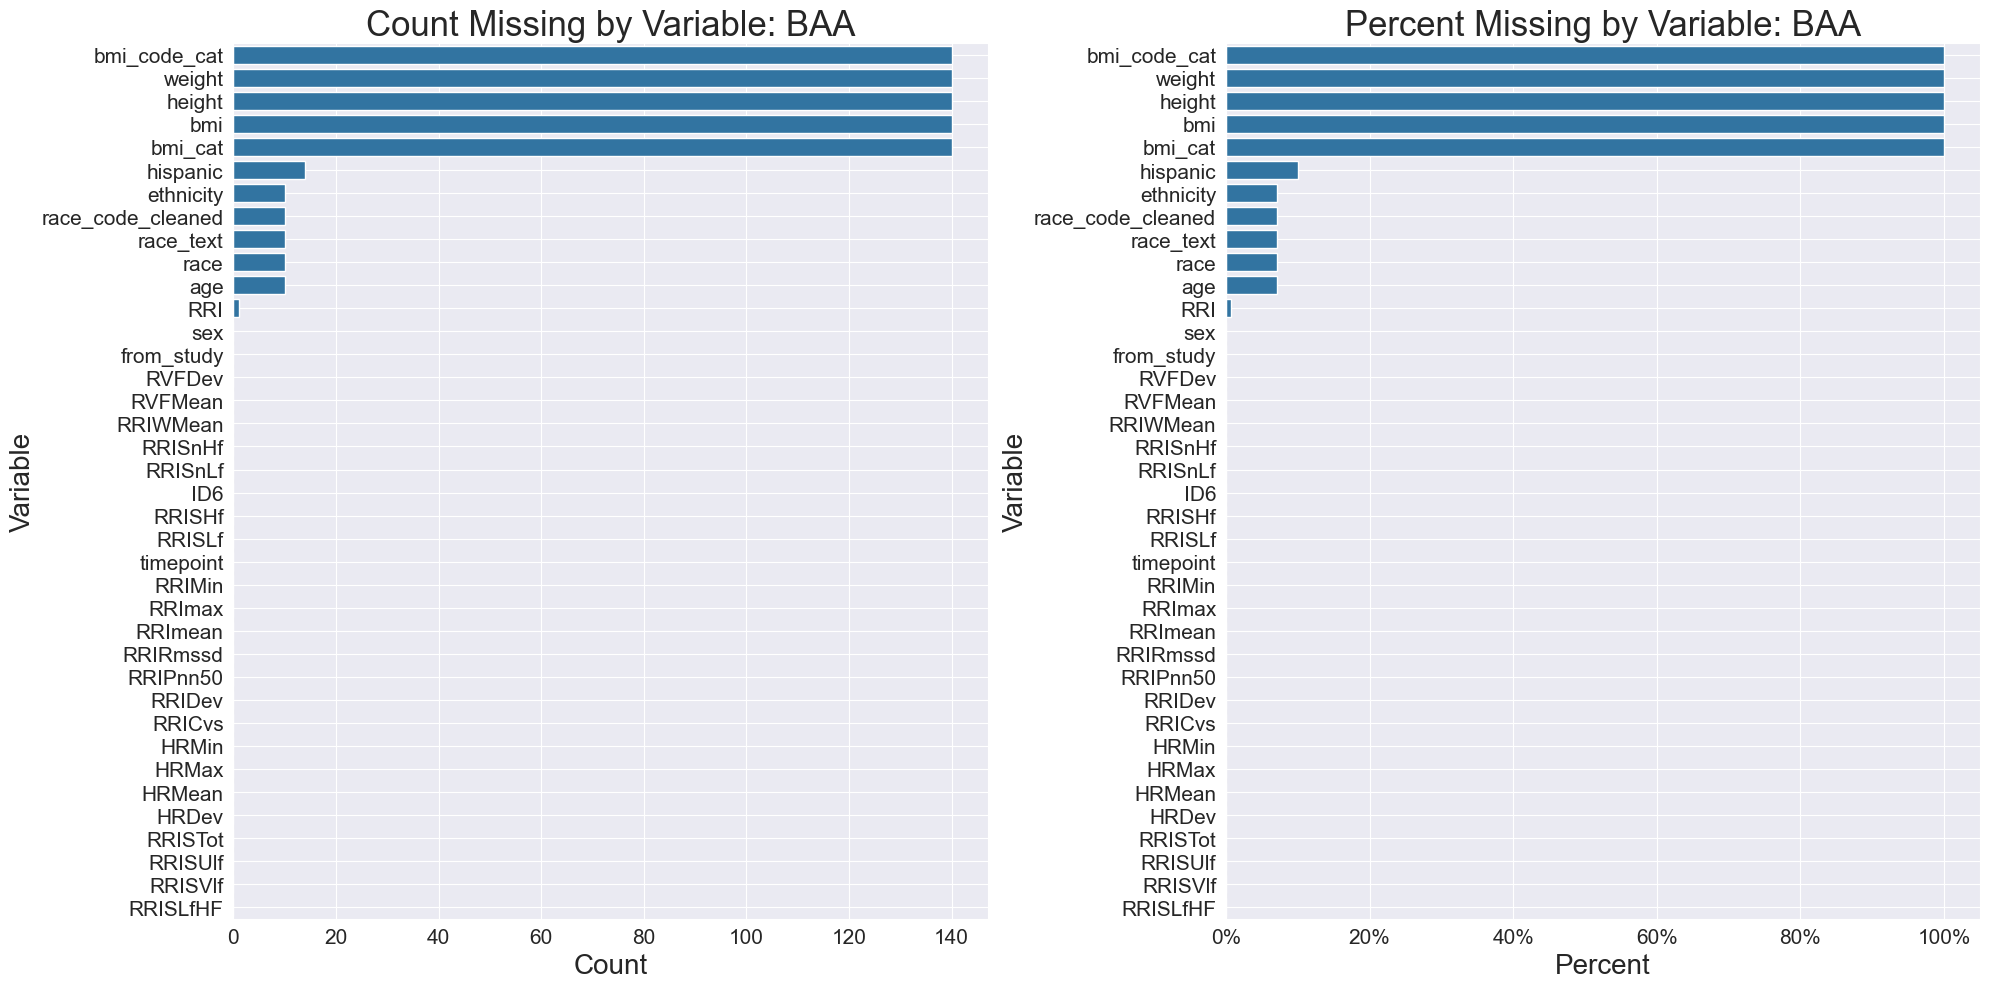

In [68]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1,2,figsize=(20,10))

### Plot 1: Count missing by variable
ax1= sns.barplot(x=baa_missing_values_df['count'], y=baa_missing_values_df['column'], ax=ax[0])

ax1.set_xlabel('Count', fontsize=20)
ax1.set_ylabel('Variable', fontsize=20)
ax1.tick_params(axis='both', labelsize=15)

ax1.set_title('Count Missing by Variable: BAA', fontsize=25)
ax1.grid(True)

### Plot 2- Percent missing by variable
ax2= sns.barplot(x=baa_missing_values_df['percent'], y=baa_missing_values_df['column'], ax=ax[1])

ax2.set_xlabel('Percent', fontsize=20)
ax2.set_ylabel('Variable', fontsize=20)
ax2.set_xticks(np.arange(0,101,20), labels=['0%', '20%', '40%', '60%', '80%', '100%'])
ax2.tick_params(axis='both', labelsize=15)


ax2.set_title('Percent Missing by Variable: BAA', fontsize=25)

ax2.grid(True)
plt.tight_layout()
plt.show()

### CGE data

In [69]:
CGE_df.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,weight,bmi,sex,race,race_text,race_code_cleaned,ethnicity,hispanic,bmi_cat,bmi_code_cat
0,265001,CGE,B1,765.0,975.0,905.0,38.0,20.1,36.0,4.2,...,NaN,NaN,F,3.0,Black or African American,3.0,0.0,no,NaN,NaN
1,265003,CGE,B1,578.0,1145.0,739.0,89.0,42.5,98.0,12.1,...,NaN,NaN,F,5.0,White,5.0,0.0,no,NaN,NaN
2,265004,CGE,B1,903.0,1168.0,1030.0,36.0,15.5,39.0,3.5,...,NaN,NaN,F,5.0,White,5.0,0.0,no,NaN,NaN
3,265005,CGE,B1,1184.0,1437.0,1363.0,50.0,29.5,37.0,3.7,...,NaN,NaN,F,5.0,White,5.0,0.0,no,NaN,NaN
4,265008,CGE,B1,805.0,1222.0,995.0,68.0,41.8,75.0,6.9,...,NaN,NaN,F,5.0,White,5.0,0.0,no,NaN,NaN


In [70]:
list(CGE_df.columns)

['ID6',
 'from_study',
 'timepoint',
 'RRIMin',
 'RRImax',
 'RRImean',
 'RRIRmssd',
 'RRIPnn50',
 'RRIDev',
 'RRICvs',
 'HRMin',
 'HRMax',
 'HRMean',
 'HRDev',
 'RRISTot',
 'RRISUlf',
 'RRISVlf',
 'RRISLf',
 'RRISHf',
 'RRISLfHF',
 'RRISnLf',
 'RRISnHf',
 'RRI',
 'RRIWMean',
 'RVFMean',
 'RVFDev',
 'age',
 'height',
 'weight',
 'bmi',
 'sex',
 'race',
 'race_text',
 'race_code_cleaned',
 'ethnicity',
 'hispanic',
 'bmi_cat',
 'bmi_code_cat']

In [71]:
CGE_df.shape

(102, 38)

In [72]:
CGE_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 38 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   ID6                102 non-null    int64   
 1   from_study         102 non-null    category
 2   timepoint          102 non-null    category
 3   RRIMin             102 non-null    float64 
 4   RRImax             102 non-null    float64 
 5   RRImean            102 non-null    float64 
 6   RRIRmssd           102 non-null    float64 
 7   RRIPnn50           102 non-null    float64 
 8   RRIDev             102 non-null    float64 
 9   RRICvs             102 non-null    float64 
 10  HRMin              102 non-null    float64 
 11  HRMax              102 non-null    float64 
 12  HRMean             102 non-null    float64 
 13  HRDev              102 non-null    float64 
 14  RRISTot            102 non-null    float64 
 15  RRISUlf            102 non-null    float64 
 16  RRISVlf 

In [73]:
CGE_missing_values_df = pd.DataFrame({
    "count": CGE_df.isnull().sum(),
    "percent": (CGE_df.isnull().sum() / len(CGE_df)) * 100
}).reset_index().rename(columns={'index': 'column'})


print(CGE_missing_values_df)

               column  count     percent
0                 ID6      0    0.000000
1          from_study      0    0.000000
2           timepoint      0    0.000000
3              RRIMin      0    0.000000
4              RRImax      0    0.000000
5             RRImean      0    0.000000
6            RRIRmssd      0    0.000000
7            RRIPnn50      0    0.000000
8              RRIDev      0    0.000000
9              RRICvs      0    0.000000
10              HRMin      0    0.000000
11              HRMax      0    0.000000
12             HRMean      0    0.000000
13              HRDev      0    0.000000
14            RRISTot      0    0.000000
15            RRISUlf      0    0.000000
16            RRISVlf      0    0.000000
17             RRISLf      0    0.000000
18             RRISHf      0    0.000000
19           RRISLfHF      0    0.000000
20            RRISnLf      0    0.000000
21            RRISnHf      1    0.980392
22                RRI      3    2.941176
23           RRI

In [74]:
CGE_missing_values_only = CGE_missing_values_df[CGE_missing_values_df['percent'] > 0].copy().sort_values('percent', ascending=False).reset_index(drop=True)

CGE_missing_values_only.head()

,column,count,percent
0,height,102,100.0
1,weight,102,100.0
2,bmi,102,100.0
3,bmi_cat,102,100.0
4,bmi_code_cat,102,100.0


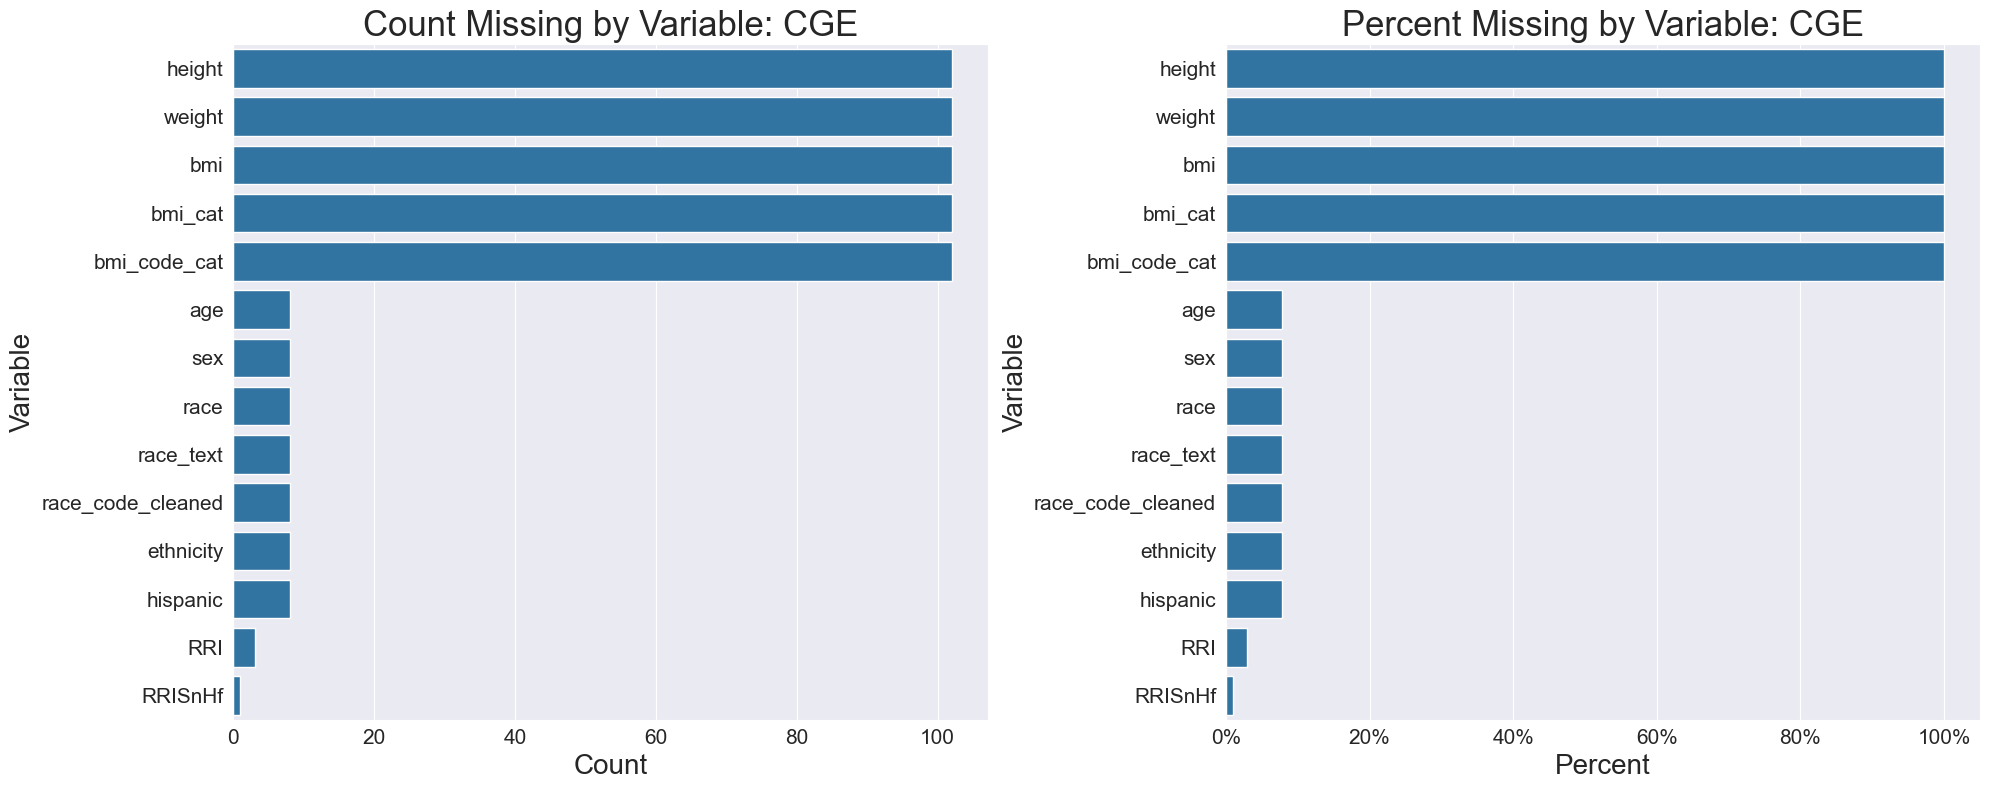

In [75]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1,2,figsize=(20,8))

### Plot 1: Count missing by variable
ax1= sns.barplot(x=CGE_missing_values_only['count'], y=CGE_missing_values_only['column'], ax=ax[0])

ax1.set_xlabel('Count', fontsize=20)
ax1.set_ylabel('Variable', fontsize=20)
ax1.tick_params(axis='both', labelsize=15)

ax1.set_title('Count Missing by Variable: CGE', fontsize=25)


### Plot 2- Percent missing by variable
ax2= sns.barplot(x=CGE_missing_values_only['percent'], y=CGE_missing_values_only['column'], ax=ax[1])

ax2.set_xlabel('Percent', fontsize=20)
ax2.set_ylabel('Variable', fontsize=20)
ax2.set_xticks(np.arange(0,101,20), labels=['0%', '20%', '40%', '60%', '80%', '100%'])
ax2.tick_params(axis='both', labelsize=15)


ax2.set_title('Percent Missing by Variable: CGE', fontsize=25)

plt.tight_layout()
plt.show()

In [76]:
CGE_b1_df = CGE_df[CGE_df['timepoint'] == 'B1'].copy().reset_index(drop=True)

CGE_b1_df.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,weight,bmi,sex,race,race_text,race_code_cleaned,ethnicity,hispanic,bmi_cat,bmi_code_cat
0,265001,CGE,B1,765.0,975.0,905.0,38.0,20.1,36.0,4.2,...,NaN,NaN,F,3.0,Black or African American,3.0,0.0,no,NaN,NaN
1,265003,CGE,B1,578.0,1145.0,739.0,89.0,42.5,98.0,12.1,...,NaN,NaN,F,5.0,White,5.0,0.0,no,NaN,NaN
2,265004,CGE,B1,903.0,1168.0,1030.0,36.0,15.5,39.0,3.5,...,NaN,NaN,F,5.0,White,5.0,0.0,no,NaN,NaN
3,265005,CGE,B1,1184.0,1437.0,1363.0,50.0,29.5,37.0,3.7,...,NaN,NaN,F,5.0,White,5.0,0.0,no,NaN,NaN
4,265008,CGE,B1,805.0,1222.0,995.0,68.0,41.8,75.0,6.9,...,NaN,NaN,F,5.0,White,5.0,0.0,no,NaN,NaN


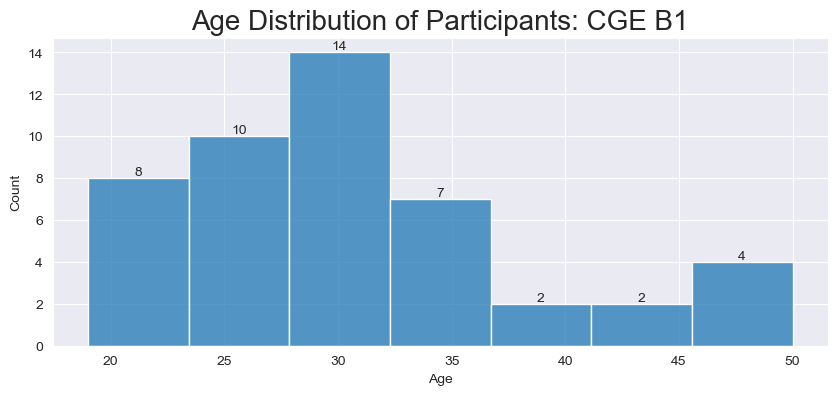

In [77]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=CGE_b1_df, x='age')

ax1.set_xlabel('Age')
ax1.set_title('Age Distribution of Participants: CGE B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

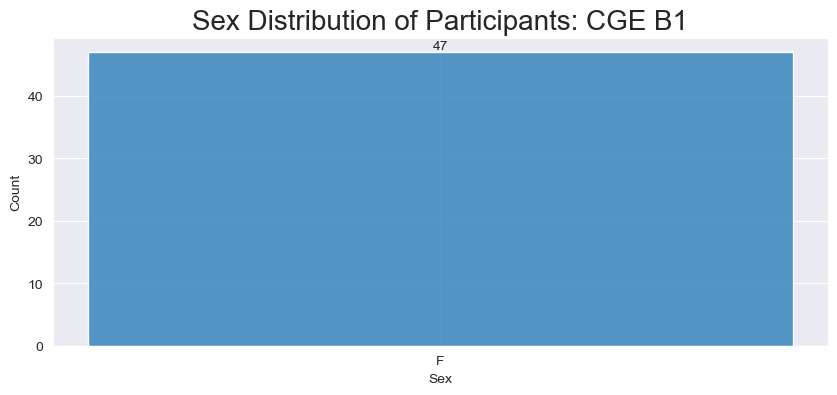

In [78]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=CGE_b1_df, x='sex')

ax1.set_xlabel('Sex')
ax1.set_title('Sex Distribution of Participants: CGE B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

### Stress_pic data

In [79]:
stress_pic_df.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,weight,bmi,sex,race,race_text,race_code_cleaned,ethnicity,hispanic,bmi_cat,bmi_code_cat
0,110001,stress_pic,B1,632.0,859.0,758.0,27.0,4.8,40.0,3.6,...,70.5,26.86,F,5.0,White,5.0,2.0,no,Overweight,3
1,110002,stress_pic,B1,655.0,1093.0,926.0,84.0,62.7,102.0,9.1,...,64.1,24.13,F,5.0,White,5.0,2.0,no,Healthy weight,2
2,110003,stress_pic,B1,763.0,1252.0,1006.0,87.0,58.1,110.0,8.7,...,64.6,23.44,F,3.0,Native Hawaiian or Other Pacific Islander,4.0,1.0,yes,Healthy weight,2
3,110004,stress_pic,B1,648.0,934.0,753.0,32.0,5.0,39.0,4.2,...,61.0,22.14,F,5.0,White,5.0,2.0,no,Healthy weight,2
4,110005,stress_pic,B1,704.0,1002.0,841.0,57.0,43.4,58.0,6.7,...,77.1,29.38,F,5.0,White,5.0,2.0,no,Overweight,3


In [80]:
stress_pic_df.shape

(332, 38)

In [81]:
stress_pic_df_missing_values_df = pd.DataFrame({
    'count': stress_pic_df.isnull().sum(),
    'percent': (stress_pic_df.isnull().sum() / len(stress_pic_df)) * 100 
}).sort_values(by='percent', ascending=False).round(2).reset_index().rename(columns={'index': 'column'})

print(stress_pic_df_missing_values_df)

               column  count  percent
0            RRIWMean    332   100.00
1        bmi_code_cat     24     7.23
2            hispanic      2     0.60
3           ethnicity      2     0.60
4              height      0     0.00
5             RRISnHf      0     0.00
6                 RRI      0     0.00
7             RVFMean      0     0.00
8              RVFDev      0     0.00
9                 age      0     0.00
10                bmi      0     0.00
11             weight      0     0.00
12         from_study      0     0.00
13                sex      0     0.00
14               race      0     0.00
15          race_text      0     0.00
16  race_code_cleaned      0     0.00
17            bmi_cat      0     0.00
18            RRISnLf      0     0.00
19                ID6      0     0.00
20             RRISHf      0     0.00
21             RRISLf      0     0.00
22          timepoint      0     0.00
23             RRIMin      0     0.00
24             RRImax      0     0.00
25          

In [82]:
stress_pic_df_missing_cols_only = stress_pic_df_missing_values_df[stress_pic_df_missing_values_df['percent'] > 0].copy().sort_values('percent', ascending=False).reset_index(drop=True)

stress_pic_df_missing_cols_only

,column,count,percent
0,RRIWMean,332,100.00
1,bmi_code_cat,24,7.23
2,hispanic,2,0.60
3,ethnicity,2,0.60


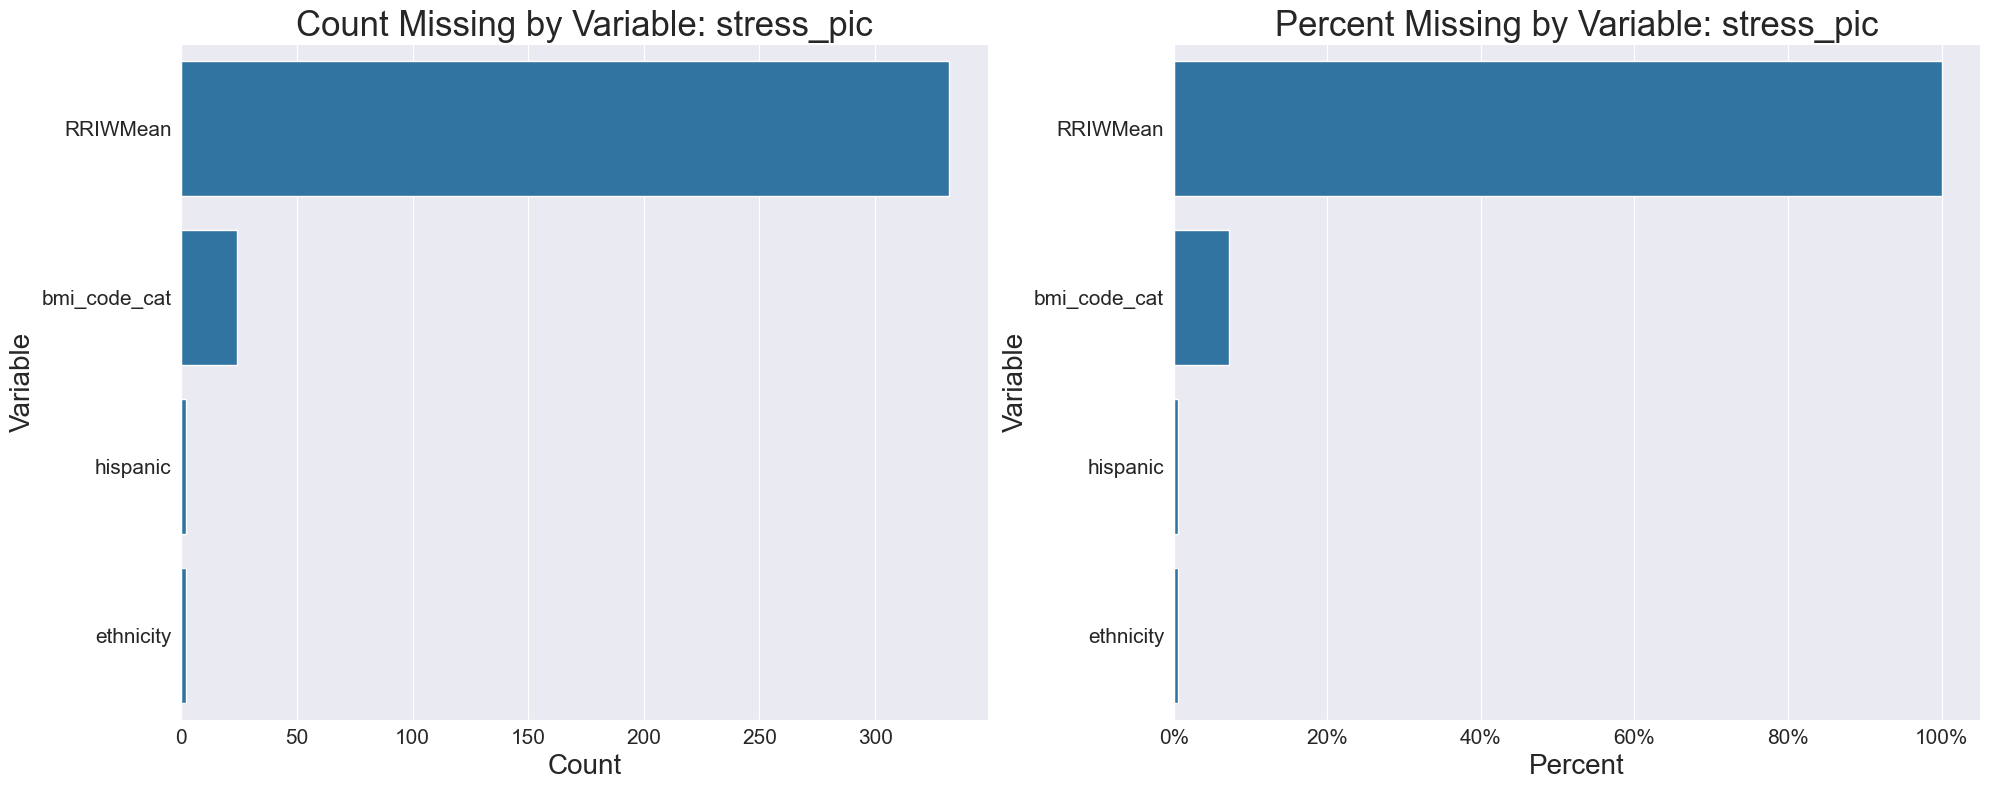

In [83]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1,2,figsize=(20,8))

### Plot 1: Count missing by variable
ax1= sns.barplot(x=stress_pic_df_missing_cols_only['count'], y=stress_pic_df_missing_cols_only['column'], ax=ax[0])

ax1.set_xlabel('Count', fontsize=20)
ax1.set_ylabel('Variable', fontsize=20)
ax1.tick_params(axis='both', labelsize=15)

ax1.set_title('Count Missing by Variable: stress_pic', fontsize=25)


### Plot 2- Percent missing by variable
ax2= sns.barplot(x=stress_pic_df_missing_cols_only['percent'], y=stress_pic_df_missing_cols_only['column'], ax=ax[1])

ax2.set_xlabel('Percent', fontsize=20)
ax2.set_ylabel('Variable', fontsize=20)
ax2.set_xticks(np.arange(0,101,20), labels=['0%', '20%', '40%', '60%', '80%', '100%'])
ax2.tick_params(axis='both', labelsize=15)


ax2.set_title('Percent Missing by Variable: stress_pic', fontsize=25)

plt.tight_layout()
plt.show()

In [84]:
stress_pic_df_b1 = stress_pic_df[stress_pic_df['timepoint'] == 'B1'].copy().reset_index(drop=True)

stress_pic_df_b1.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,weight,bmi,sex,race,race_text,race_code_cleaned,ethnicity,hispanic,bmi_cat,bmi_code_cat
0,110001,stress_pic,B1,632.0,859.0,758.0,27.0,4.8,40.0,3.6,...,70.5,26.86,F,5.0,White,5.0,2.0,no,Overweight,3
1,110002,stress_pic,B1,655.0,1093.0,926.0,84.0,62.7,102.0,9.1,...,64.1,24.13,F,5.0,White,5.0,2.0,no,Healthy weight,2
2,110003,stress_pic,B1,763.0,1252.0,1006.0,87.0,58.1,110.0,8.7,...,64.6,23.44,F,3.0,Native Hawaiian or Other Pacific Islander,4.0,1.0,yes,Healthy weight,2
3,110004,stress_pic,B1,648.0,934.0,753.0,32.0,5.0,39.0,4.2,...,61.0,22.14,F,5.0,White,5.0,2.0,no,Healthy weight,2
4,110005,stress_pic,B1,704.0,1002.0,841.0,57.0,43.4,58.0,6.7,...,77.1,29.38,F,5.0,White,5.0,2.0,no,Overweight,3


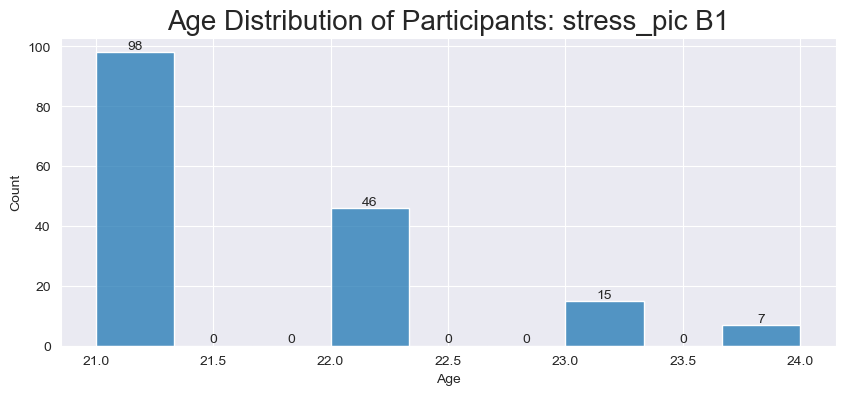

In [85]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=stress_pic_df_b1, x='age')

ax1.set_xlabel('Age')
ax1.set_title('Age Distribution of Participants: stress_pic B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

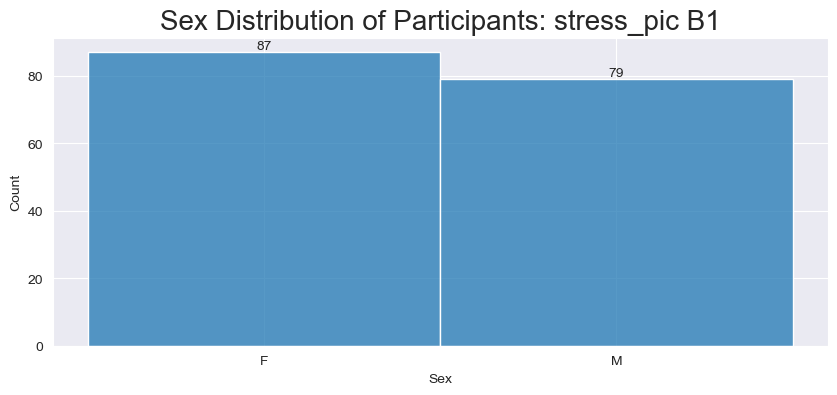

In [86]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=stress_pic_df_b1, x='sex')

ax1.set_xlabel('Sex')
ax1.set_title('Sex Distribution of Participants: stress_pic B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

### Stress_suppl data

In [87]:
stress_suppl_df.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,weight,bmi,sex,race,race_text,race_code_cleaned,ethnicity,hispanic,bmi_cat,bmi_code_cat
0,120210,stress_suppl,B1,164.0,1015.0,762.0,72.0,14.8,71.0,9.4,...,NaN,NaN,F,4.0,Black or African American,3.0,2.0,no,NaN,NaN
1,120211,stress_suppl,B1,704.0,905.0,830.0,33.0,12.7,36.0,4.0,...,NaN,NaN,F,2.0,Asian,2.0,2.0,no,NaN,NaN
2,120212,stress_suppl,B1,813.0,1063.0,969.0,49.0,37.5,46.0,5.1,...,NaN,NaN,F,5.0,White,5.0,2.0,no,NaN,NaN
3,120213,stress_suppl,B1,876.0,1312.0,1048.0,100.0,70.9,76.0,9.5,...,NaN,NaN,F,5.0,White,5.0,2.0,no,NaN,NaN
4,120214,stress_suppl,B1,717.0,992.0,891.0,53.0,38.9,51.0,5.9,...,NaN,NaN,F,2.0,Asian,2.0,2.0,no,NaN,NaN


In [88]:
stress_suppl_df.shape

(62, 38)

In [89]:
stress_suppl_missing_values_df = pd.DataFrame({
    'count': stress_suppl_df.isna().sum(),
    'percent': stress_suppl_df.isna().sum() / len(stress_suppl_df) * 100
}).sort_values(by='percent', ascending=False).round(2).reset_index().rename(columns={'index': 'column'})

stress_suppl_missing_values_df.head()

,column,count,percent
0,bmi_code_cat,62,100.0
1,weight,62,100.0
2,RRIWMean,62,100.0
3,height,62,100.0
4,bmi,62,100.0


In [90]:
stress_supple_missing_cols_only = stress_suppl_missing_values_df[stress_suppl_missing_values_df['percent']>0].sort_values(by='percent', ascending=True)

stress_supple_missing_cols_only

,column,count,percent
6,RRI,14,22.58
0,bmi_code_cat,62,100.00
1,weight,62,100.00
2,RRIWMean,62,100.00
3,height,62,100.00
4,bmi,62,100.00
5,bmi_cat,62,100.00


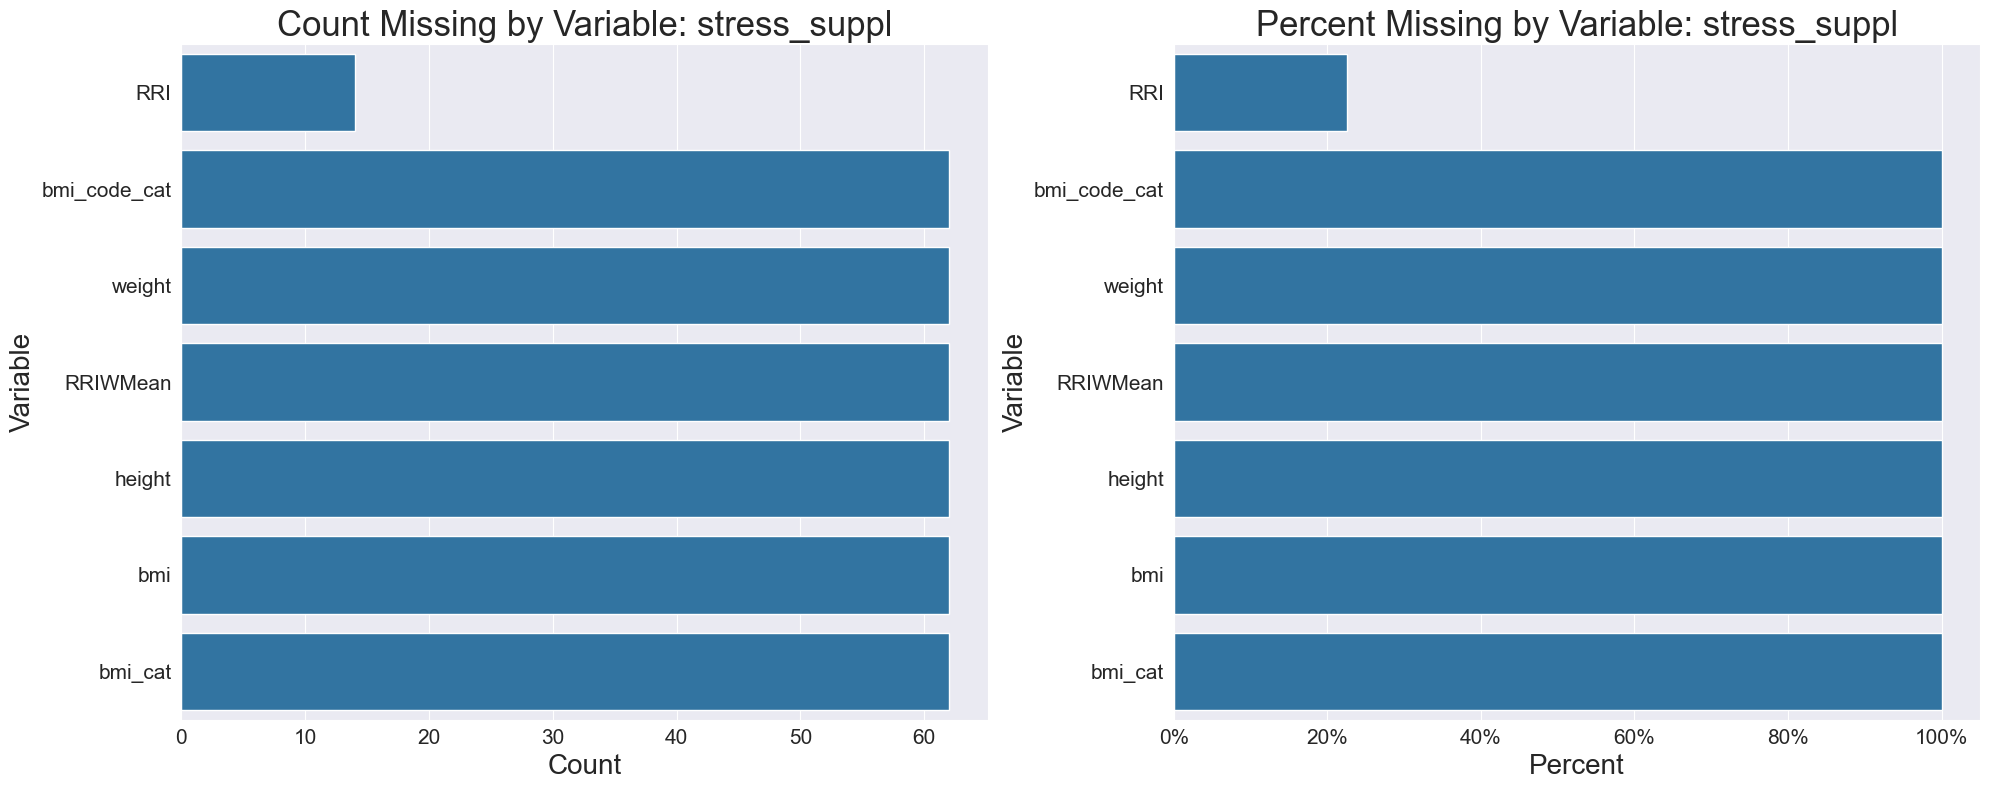

In [91]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1,2,figsize=(20,8))

### Plot 1: Count missing by variable
ax1= sns.barplot(x=stress_supple_missing_cols_only['count'], y=stress_supple_missing_cols_only['column'], ax=ax[0])

ax1.set_xlabel('Count', fontsize=20)
ax1.set_ylabel('Variable', fontsize=20)
ax1.tick_params(axis='both', labelsize=15)

ax1.set_title('Count Missing by Variable: stress_suppl', fontsize=25)


### Plot 2- Percent missing by variable
ax2= sns.barplot(x=stress_supple_missing_cols_only['percent'], y=stress_supple_missing_cols_only['column'], ax=ax[1])

ax2.set_xlabel('Percent', fontsize=20)
ax2.set_ylabel('Variable', fontsize=20)
ax2.set_xticks(np.arange(0,101,20), labels=['0%', '20%', '40%', '60%', '80%', '100%'])
ax2.tick_params(axis='both', labelsize=15)


ax2.set_title('Percent Missing by Variable: stress_suppl', fontsize=25)

plt.tight_layout()
plt.show()

In [92]:
stress_suppl_b1_df = stress_suppl_df[stress_suppl_df['timepoint']=='B1'].copy().reset_index(drop=True)

stress_suppl_b1_df.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,weight,bmi,sex,race,race_text,race_code_cleaned,ethnicity,hispanic,bmi_cat,bmi_code_cat
0,120210,stress_suppl,B1,164.0,1015.0,762.0,72.0,14.8,71.0,9.4,...,NaN,NaN,F,4.0,Black or African American,3.0,2.0,no,NaN,NaN
1,120211,stress_suppl,B1,704.0,905.0,830.0,33.0,12.7,36.0,4.0,...,NaN,NaN,F,2.0,Asian,2.0,2.0,no,NaN,NaN
2,120212,stress_suppl,B1,813.0,1063.0,969.0,49.0,37.5,46.0,5.1,...,NaN,NaN,F,5.0,White,5.0,2.0,no,NaN,NaN
3,120213,stress_suppl,B1,876.0,1312.0,1048.0,100.0,70.9,76.0,9.5,...,NaN,NaN,F,5.0,White,5.0,2.0,no,NaN,NaN
4,120214,stress_suppl,B1,717.0,992.0,891.0,53.0,38.9,51.0,5.9,...,NaN,NaN,F,2.0,Asian,2.0,2.0,no,NaN,NaN


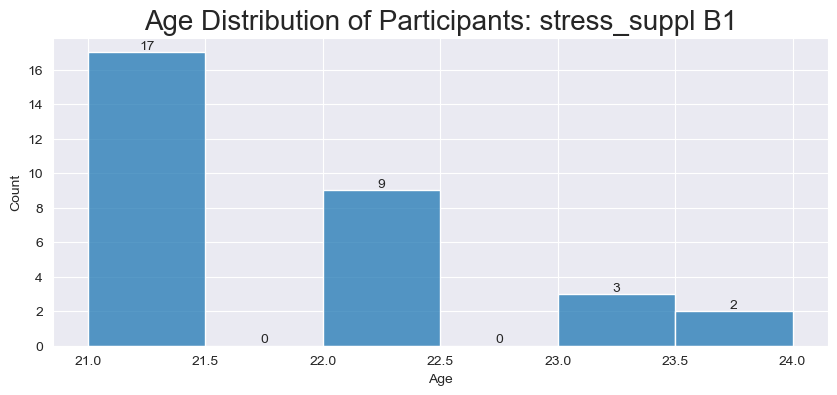

In [93]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=stress_suppl_b1_df, x='age')

ax1.set_xlabel('Age')
ax1.set_title('Age Distribution of Participants: stress_suppl B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

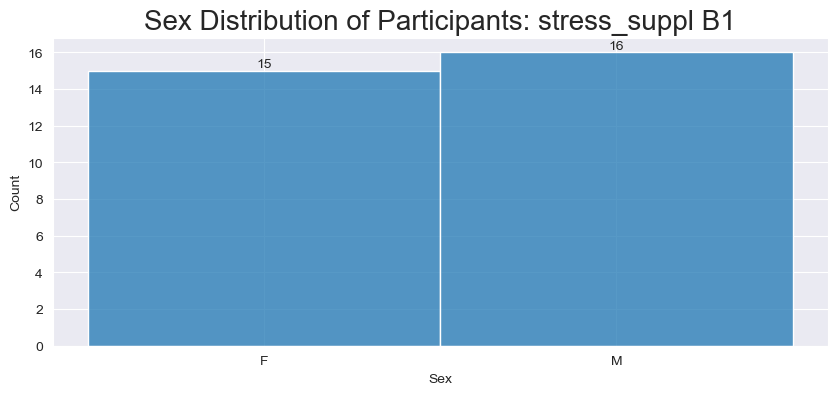

In [94]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=stress_suppl_b1_df, x='sex')

ax1.set_xlabel('Sex')
ax1.set_title('Sex Distribution of Participants: stress_suppl B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

### Stress_prevention data

In [95]:
stress_prevention_df.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,weight,bmi,sex,race,race_text,race_code_cleaned,ethnicity,hispanic,bmi_cat,bmi_code_cat
0,130501,stress_prevention,B1,465.0,1324.0,976.0,91.0,19.9,83.0,9.3,...,NaN,NaN,F,5.0,White,5.0,2.0,no,NaN,NaN
1,130502,stress_prevention,B1,995.0,1477.0,1240.0,97.0,65.7,86.0,7.8,...,NaN,NaN,F,2.0,Asian,2.0,2.0,no,NaN,NaN
2,130503,stress_prevention,B1,713.0,1096.0,925.0,72.0,51.7,79.0,7.8,...,NaN,NaN,F,5.0,White,5.0,2.0,no,NaN,NaN
3,130504,stress_prevention,B1,789.0,1173.0,1004.0,82.0,64.0,78.0,8.1,...,NaN,NaN,F,5.0,White,5.0,2.0,no,NaN,NaN
4,130505,stress_prevention,B1,582.0,865.0,718.0,34.0,14.0,51.0,4.7,...,NaN,NaN,F,5.0,White,5.0,2.0,no,NaN,NaN


In [96]:
stress_prevention_df.shape

(190, 38)

In [97]:
stress_prevention_missing_values_df = pd.DataFrame({
    'count': stress_prevention_df.isnull().sum(),
    'percent': (stress_prevention_df.isnull().sum() / len(stress_prevention_df)) * 100 
}).sort_values(by='percent', ascending=False).round(2).reset_index().rename(columns={'index': 'column'})

print(stress_prevention_missing_values_df)

               column  count  percent
0        bmi_code_cat    190   100.00
1              weight    190   100.00
2              height    190   100.00
3                 bmi    190   100.00
4             bmi_cat    190   100.00
5           ethnicity      2     1.05
6            hispanic      2     1.05
7             RRISnHf      1     0.53
8   race_code_cleaned      0     0.00
9           race_text      0     0.00
10               race      0     0.00
11                sex      0     0.00
12         from_study      0     0.00
13                age      0     0.00
14             RVFDev      0     0.00
15            RVFMean      0     0.00
16           RRIWMean      0     0.00
17                RRI      0     0.00
18            RRISnLf      0     0.00
19                ID6      0     0.00
20             RRISHf      0     0.00
21             RRISLf      0     0.00
22          timepoint      0     0.00
23             RRIMin      0     0.00
24             RRImax      0     0.00
25          

In [98]:
stress_prevention_df_missing_cols_only = stress_prevention_missing_values_df[stress_prevention_missing_values_df['percent'] > 0].copy().sort_values('percent', ascending=False).reset_index(drop=True)

print(stress_prevention_df_missing_cols_only)

         column  count  percent
0  bmi_code_cat    190   100.00
1        weight    190   100.00
2        height    190   100.00
3           bmi    190   100.00
4       bmi_cat    190   100.00
5     ethnicity      2     1.05
6      hispanic      2     1.05
7       RRISnHf      1     0.53


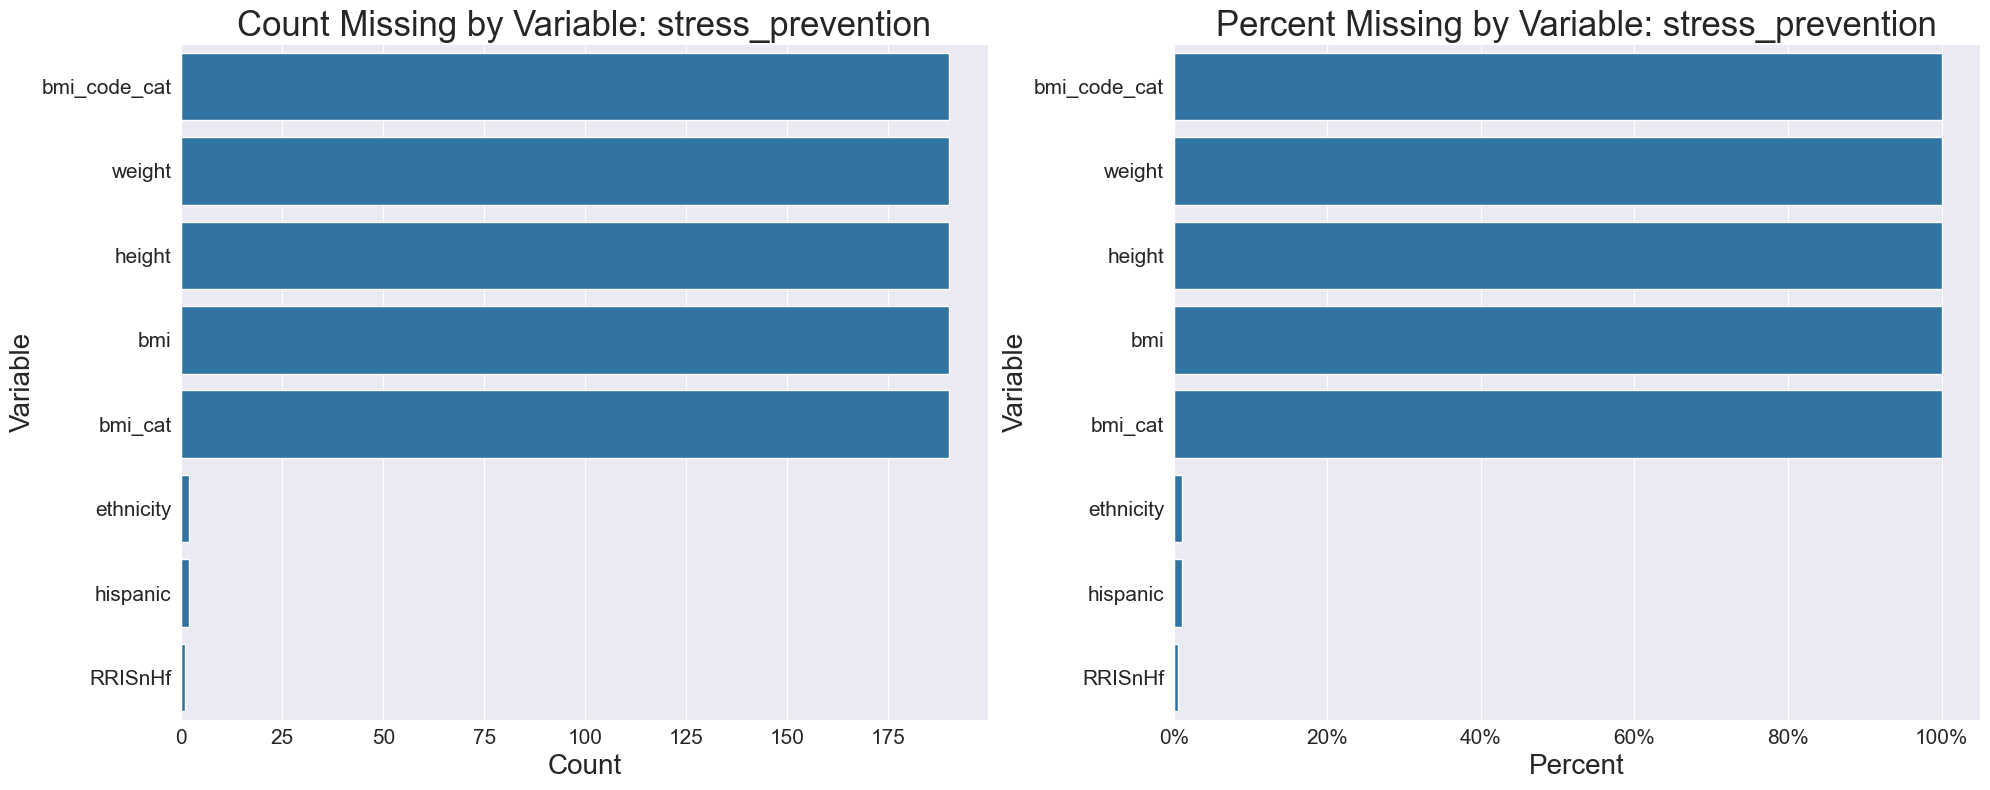

In [99]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1,2,figsize=(20,8))

### Plot 1: Count missing by variable
ax1= sns.barplot(x=stress_prevention_df_missing_cols_only['count'], y=stress_prevention_df_missing_cols_only['column'], ax=ax[0])

ax1.set_xlabel('Count', fontsize=20)
ax1.set_ylabel('Variable', fontsize=20)
ax1.tick_params(axis='both', labelsize=15)

ax1.set_title('Count Missing by Variable: stress_prevention', fontsize=25)


### Plot 2- Percent missing by variable
ax2= sns.barplot(x=stress_prevention_df_missing_cols_only['percent'], y=stress_prevention_df_missing_cols_only['column'], ax=ax[1])

ax2.set_xlabel('Percent', fontsize=20)
ax2.set_ylabel('Variable', fontsize=20)
ax2.set_xticks(np.arange(0,101,20), labels=['0%', '20%', '40%', '60%', '80%', '100%'])
ax2.tick_params(axis='both', labelsize=15)


ax2.set_title('Percent Missing by Variable: stress_prevention', fontsize=25)

plt.tight_layout()
plt.show()

In [100]:
stress_prevention_b1_df = stress_prevention_df[stress_prevention_df['timepoint']=='B1'].copy().reset_index(drop=True)

stress_prevention_b1_df.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,weight,bmi,sex,race,race_text,race_code_cleaned,ethnicity,hispanic,bmi_cat,bmi_code_cat
0,130501,stress_prevention,B1,465.0,1324.0,976.0,91.0,19.9,83.0,9.3,...,NaN,NaN,F,5.0,White,5.0,2.0,no,NaN,NaN
1,130502,stress_prevention,B1,995.0,1477.0,1240.0,97.0,65.7,86.0,7.8,...,NaN,NaN,F,2.0,Asian,2.0,2.0,no,NaN,NaN
2,130503,stress_prevention,B1,713.0,1096.0,925.0,72.0,51.7,79.0,7.8,...,NaN,NaN,F,5.0,White,5.0,2.0,no,NaN,NaN
3,130504,stress_prevention,B1,789.0,1173.0,1004.0,82.0,64.0,78.0,8.1,...,NaN,NaN,F,5.0,White,5.0,2.0,no,NaN,NaN
4,130505,stress_prevention,B1,582.0,865.0,718.0,34.0,14.0,51.0,4.7,...,NaN,NaN,F,5.0,White,5.0,2.0,no,NaN,NaN


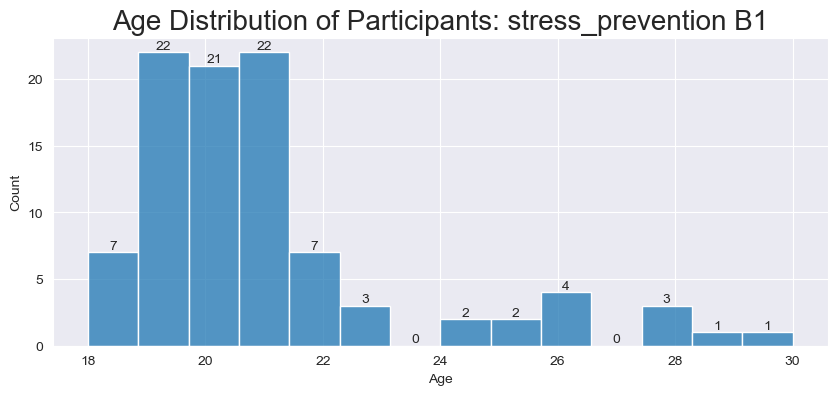

In [101]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=stress_prevention_b1_df, x='age')

ax1.set_xlabel('Age')
ax1.set_title('Age Distribution of Participants: stress_prevention B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

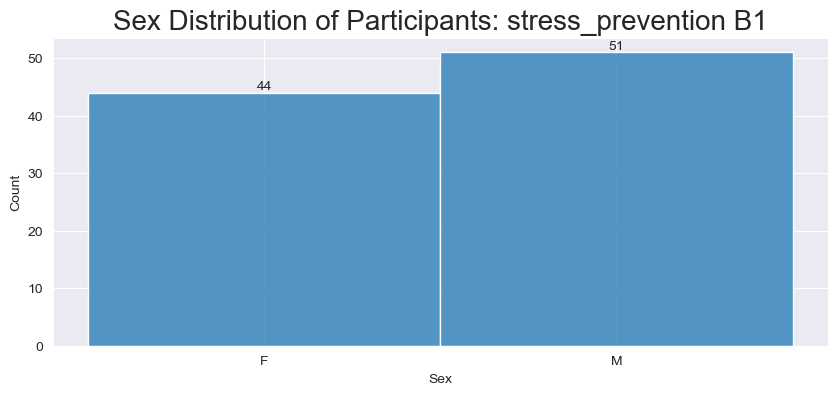

In [102]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=stress_prevention_b1_df, x='sex')

ax1.set_xlabel('Sex')
ax1.set_title('Sex Distribution of Participants: stress_prevention B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

### VT1 data

In [103]:
VT1_df.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,weight,bmi,sex,race,race_text,race_code_cleaned,ethnicity,hispanic,bmi_cat,bmi_code_cat
0,152000,VT1,B1,689.0,1066.0,838.0,39.0,19.7,53.0,4.7,...,83.7,25.83,M,NaN,NaN,NaN,NaN,NaN,Overweight,3
1,152002,VT1,B1,673.0,992.0,850.0,33.0,10.6,57.0,3.9,...,64.3,23.62,M,NaN,NaN,NaN,NaN,NaN,Healthy weight,2
2,152004,VT1,B1,702.0,961.0,814.0,24.0,1.4,38.0,2.9,...,78.6,25.09,M,NaN,NaN,NaN,NaN,NaN,Overweight,3
3,152006,VT1,B1,620.0,829.0,707.0,20.0,2.1,35.0,2.9,...,81.5,29.22,M,NaN,NaN,NaN,NaN,NaN,Overweight,3
4,152008,VT1,B1,725.0,1052.0,918.0,29.0,8.0,51.0,3.2,...,64.3,20.29,M,NaN,NaN,NaN,NaN,NaN,Healthy weight,2


In [104]:
VT1_df.shape

(24, 38)

In [105]:
VT1_df['ID6'].unique()

array([152000, 152002, 152004, 152006, 152008, 152010, 152020, 152024,
       152026, 152028, 152030, 152032])

In [106]:
VT1_df.isna().sum()

ID6                   0
from_study            0
timepoint             0
RRIMin                0
RRImax                0
RRImean               0
RRIRmssd              0
RRIPnn50              0
RRIDev                0
RRICvs                0
HRMin                 0
HRMax                 0
HRMean                0
HRDev                 0
RRISTot               0
RRISUlf               0
RRISVlf               0
RRISLf                0
RRISHf                0
RRISLfHF              0
RRISnLf               0
RRISnHf              13
RRI                   0
RRIWMean              0
RVFMean               0
RVFDev                0
age                   0
height                0
weight                0
bmi                   0
sex                   0
race                 24
race_text            24
race_code_cleaned    24
ethnicity            24
hispanic             24
bmi_cat               0
bmi_code_cat          0
dtype: int64

In [107]:
VT1_missing_values_df = pd.DataFrame({
    'count': VT1_df.isnull().sum(),
    'percent': (VT1_df.isnull().sum() / len(VT1_df)) * 100
}).sort_values(by='percent', ascending=False).round(2).reset_index().rename(columns={'index': 'column'})

VT1_missing_values_df.head()

,column,count,percent
0,hispanic,24,100.0
1,ethnicity,24,100.0
2,race_code_cleaned,24,100.0
3,race_text,24,100.0
4,race,24,100.0


In [108]:
VT1_missing_cols_only = VT1_missing_values_df[VT1_missing_values_df['percent']>0].copy().reset_index(drop=True)

VT1_missing_cols_only.head()

,column,count,percent
0,hispanic,24,100.0
1,ethnicity,24,100.0
2,race_code_cleaned,24,100.0
3,race_text,24,100.0
4,race,24,100.0


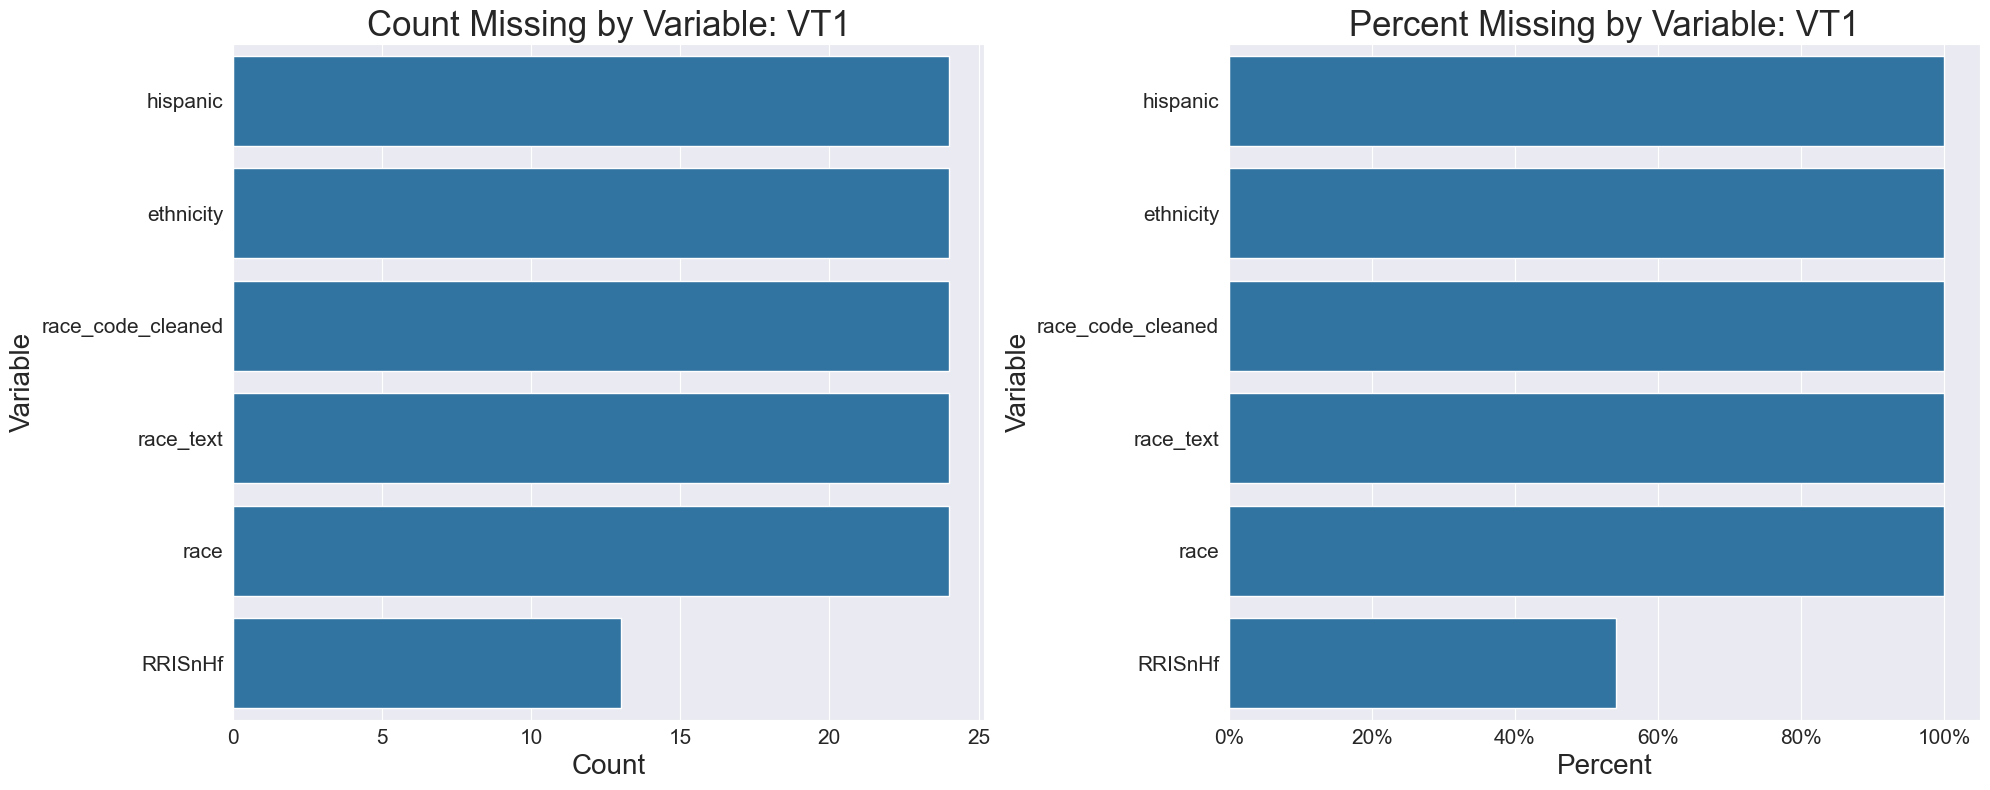

In [109]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1,2,figsize=(20,8))

### Plot 1: Count missing by variable
ax1= sns.barplot(x=VT1_missing_cols_only['count'], y=VT1_missing_cols_only['column'], ax=ax[0])

ax1.set_xlabel('Count', fontsize=20)
ax1.set_ylabel('Variable', fontsize=20)
ax1.tick_params(axis='both', labelsize=15)

ax1.set_title('Count Missing by Variable: VT1', fontsize=25)


### Plot 2- Percent missing by variable
ax2= sns.barplot(x=VT1_missing_cols_only['percent'], y=VT1_missing_cols_only['column'], ax=ax[1])

ax2.set_xlabel('Percent', fontsize=20)
ax2.set_ylabel('Variable', fontsize=20)
ax2.set_xticks(np.arange(0,101,20), labels=['0%', '20%', '40%', '60%', '80%', '100%'])
ax2.tick_params(axis='both', labelsize=15)


ax2.set_title('Percent Missing by Variable: VT1', fontsize=25)

plt.tight_layout()
plt.show()

### VT2 data

In [110]:
VT2_df.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,weight,bmi,sex,race,race_text,race_code_cleaned,ethnicity,hispanic,bmi_cat,bmi_code_cat
0,152039,VT2,B1,786.0,1085.0,950.0,36.0,15.9,52.0,3.8,...,76.0,24.54,M,NaN,NaN,NaN,0.0,no,Healthy weight,2
1,152040,VT2,B1,720.0,1092.0,892.0,70.0,49.7,60.0,7.8,...,94.0,29.34,M,2.0,Asian,2.0,0.0,no,Overweight,3
2,152042,VT2,B1,692.0,1052.0,844.0,51.0,29.3,75.0,6.0,...,77.1,26.06,M,2.0,Asian,2.0,0.0,no,Overweight,3
3,152043,VT2,B1,822.0,1298.0,1111.0,72.0,51.7,75.0,6.5,...,97.5,27.59,M,5.0,White,5.0,0.0,no,Overweight,3
4,152045,VT2,B1,750.0,1064.0,875.0,47.0,30.1,54.0,5.3,...,82.5,30.67,M,5.0,White,5.0,1.0,yes,Obese,NaN


In [111]:
VT2_df.shape

(142, 38)

In [112]:
VT2_df_missing_values_df = pd.DataFrame({
    'count': VT2_df.isnull().sum(),
    'percent': (VT2_df.isnull().sum() / len(VT2_df)) * 100 
}).sort_values(by='percent', ascending=False).round(2).reset_index().rename(columns={'index': 'column'})

print(VT2_df_missing_values_df)

               column  count  percent
0        bmi_code_cat     10     7.04
1           race_text      6     4.23
2                race      6     4.23
3   race_code_cleaned      6     4.23
4              height      4     2.82
5              weight      4     2.82
6                 bmi      4     2.82
7             bmi_cat      4     2.82
8           ethnicity      0     0.00
9                 sex      0     0.00
10         from_study      0     0.00
11           hispanic      0     0.00
12                age      0     0.00
13             RVFDev      0     0.00
14            RVFMean      0     0.00
15           RRIWMean      0     0.00
16                RRI      0     0.00
17            RRISnHf      0     0.00
18            RRISnLf      0     0.00
19                ID6      0     0.00
20             RRISHf      0     0.00
21             RRISLf      0     0.00
22          timepoint      0     0.00
23             RRIMin      0     0.00
24             RRImax      0     0.00
25          

In [113]:
VT2_df_missing_cols_only = VT2_df_missing_values_df[VT2_df_missing_values_df['percent'] > 0].copy().sort_values('percent', ascending=False).reset_index(drop=True)

print(VT2_df_missing_cols_only)

              column  count  percent
0       bmi_code_cat     10     7.04
1          race_text      6     4.23
2               race      6     4.23
3  race_code_cleaned      6     4.23
4             height      4     2.82
5             weight      4     2.82
6                bmi      4     2.82
7            bmi_cat      4     2.82


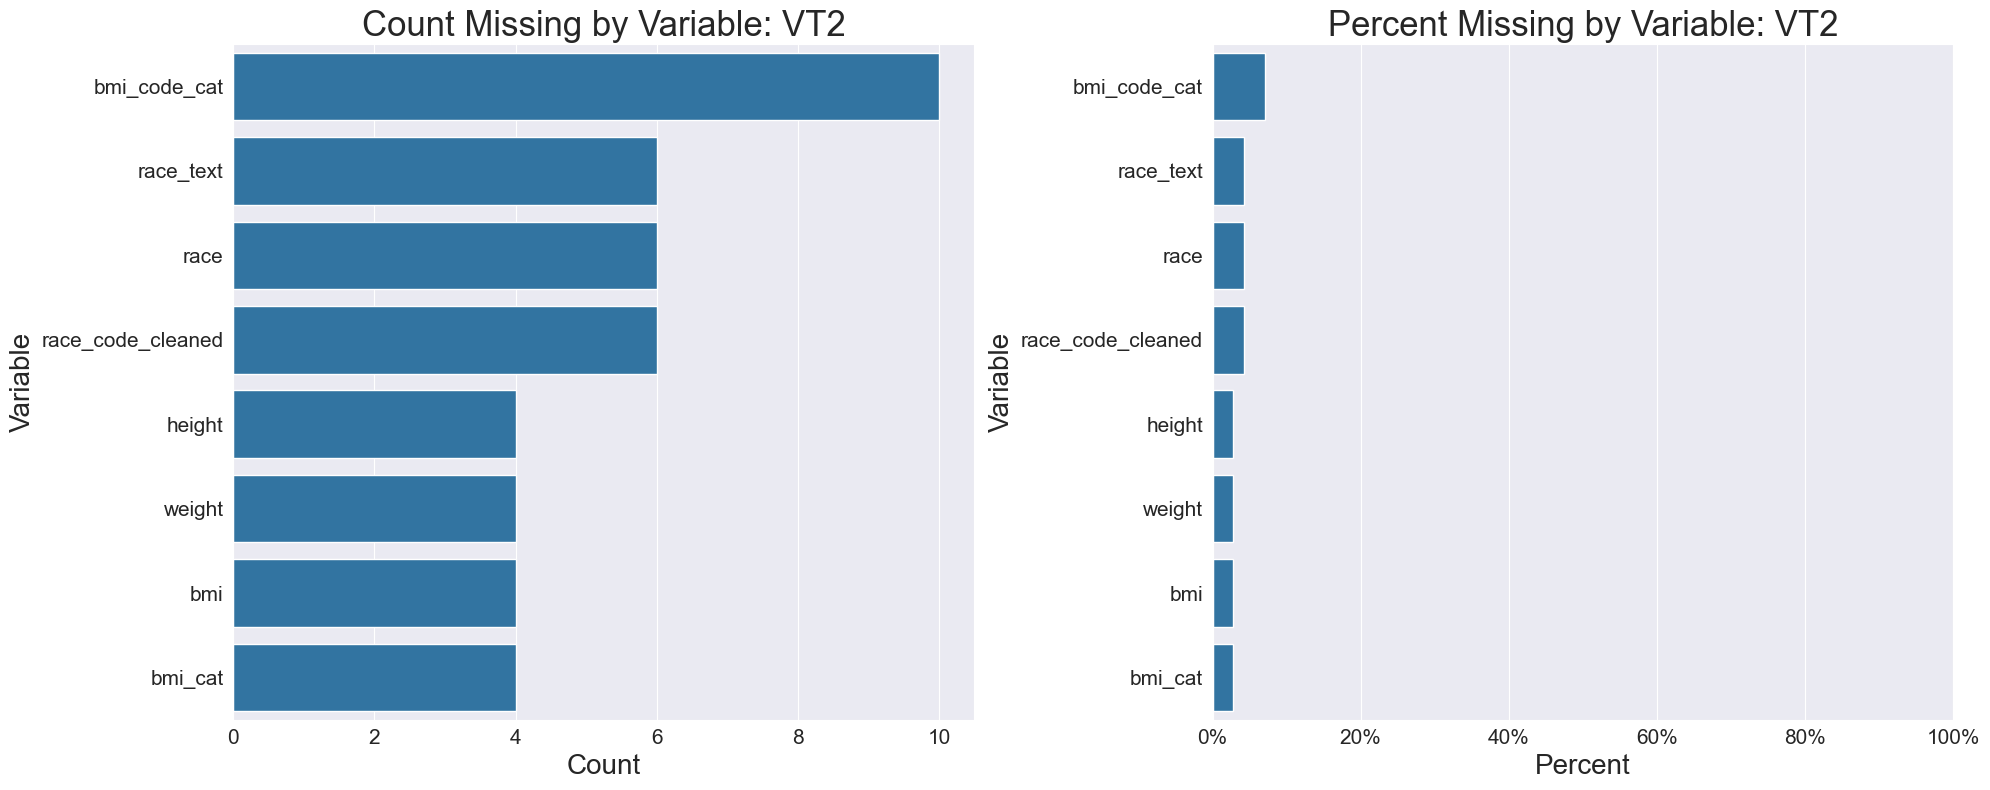

In [114]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1,2,figsize=(20,8))

### Plot 1: Count missing by variable
ax1= sns.barplot(x=VT2_df_missing_cols_only['count'], y=VT2_df_missing_cols_only['column'], ax=ax[0])

ax1.set_xlabel('Count', fontsize=20)
ax1.set_ylabel('Variable', fontsize=20)
ax1.tick_params(axis='both', labelsize=15)

ax1.set_title('Count Missing by Variable: VT2', fontsize=25)

### Plot 2- Percent missing by variable
ax2= sns.barplot(x=VT2_df_missing_cols_only['percent'], y=VT2_df_missing_cols_only['column'], ax=ax[1])

ax2.set_xlabel('Percent', fontsize=20)
ax2.set_ylabel('Variable', fontsize=20)
ax2.set_xticks(np.arange(0,101,20), labels=['0%', '20%', '40%', '60%', '80%', '100%'])
ax2.tick_params(axis='both', labelsize=15)

ax2.set_title('Percent Missing by Variable: VT2', fontsize=25)

plt.tight_layout()
plt.show()

In [115]:
VT1_b1_df = VT1_df[VT1_df['timepoint']=='B1'].copy().reset_index(drop=True)

VT1_b1_df.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,weight,bmi,sex,race,race_text,race_code_cleaned,ethnicity,hispanic,bmi_cat,bmi_code_cat
0,152000,VT1,B1,689.0,1066.0,838.0,39.0,19.7,53.0,4.7,...,83.7,25.83,M,NaN,NaN,NaN,NaN,NaN,Overweight,3
1,152002,VT1,B1,673.0,992.0,850.0,33.0,10.6,57.0,3.9,...,64.3,23.62,M,NaN,NaN,NaN,NaN,NaN,Healthy weight,2
2,152004,VT1,B1,702.0,961.0,814.0,24.0,1.4,38.0,2.9,...,78.6,25.09,M,NaN,NaN,NaN,NaN,NaN,Overweight,3
3,152006,VT1,B1,620.0,829.0,707.0,20.0,2.1,35.0,2.9,...,81.5,29.22,M,NaN,NaN,NaN,NaN,NaN,Overweight,3
4,152008,VT1,B1,725.0,1052.0,918.0,29.0,8.0,51.0,3.2,...,64.3,20.29,M,NaN,NaN,NaN,NaN,NaN,Healthy weight,2


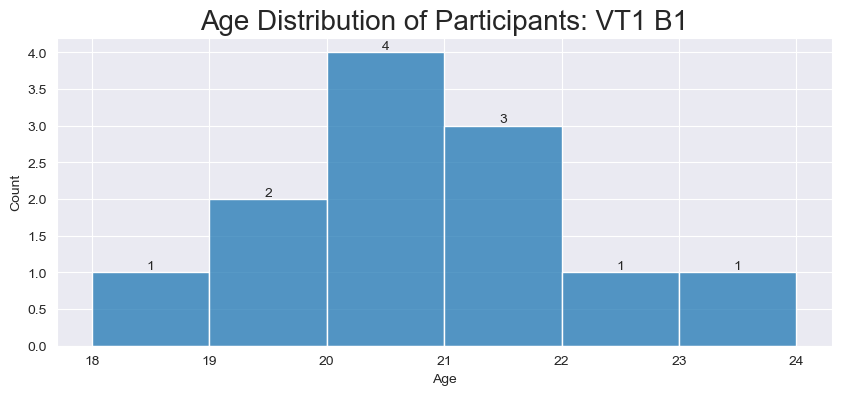

In [116]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=VT1_b1_df, x='age')

ax1.set_xlabel('Age')
ax1.set_title('Age Distribution of Participants: VT1 B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

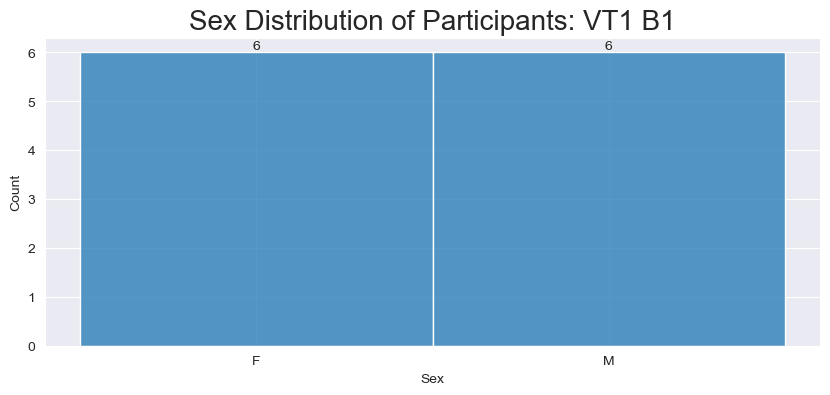

In [117]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=VT1_b1_df, x='sex')

ax1.set_xlabel('Sex')
ax1.set_title('Sex Distribution of Participants: VT1 B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

In [118]:
VT2_b1_df = VT2_df[VT2_df['timepoint']=='B1'].copy().reset_index(drop=True)

VT2_b1_df.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,weight,bmi,sex,race,race_text,race_code_cleaned,ethnicity,hispanic,bmi_cat,bmi_code_cat
0,152039,VT2,B1,786.0,1085.0,950.0,36.0,15.9,52.0,3.8,...,76.0,24.54,M,NaN,NaN,NaN,0.0,no,Healthy weight,2
1,152040,VT2,B1,720.0,1092.0,892.0,70.0,49.7,60.0,7.8,...,94.0,29.34,M,2.0,Asian,2.0,0.0,no,Overweight,3
2,152042,VT2,B1,692.0,1052.0,844.0,51.0,29.3,75.0,6.0,...,77.1,26.06,M,2.0,Asian,2.0,0.0,no,Overweight,3
3,152043,VT2,B1,822.0,1298.0,1111.0,72.0,51.7,75.0,6.5,...,97.5,27.59,M,5.0,White,5.0,0.0,no,Overweight,3
4,152045,VT2,B1,750.0,1064.0,875.0,47.0,30.1,54.0,5.3,...,82.5,30.67,M,5.0,White,5.0,1.0,yes,Obese,NaN


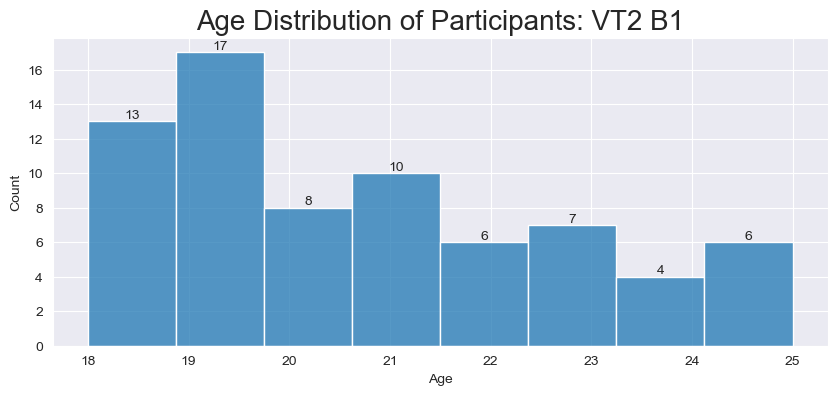

In [119]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=VT2_b1_df, x='age')

ax1.set_xlabel('Age')
ax1.set_title('Age Distribution of Participants: VT2 B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

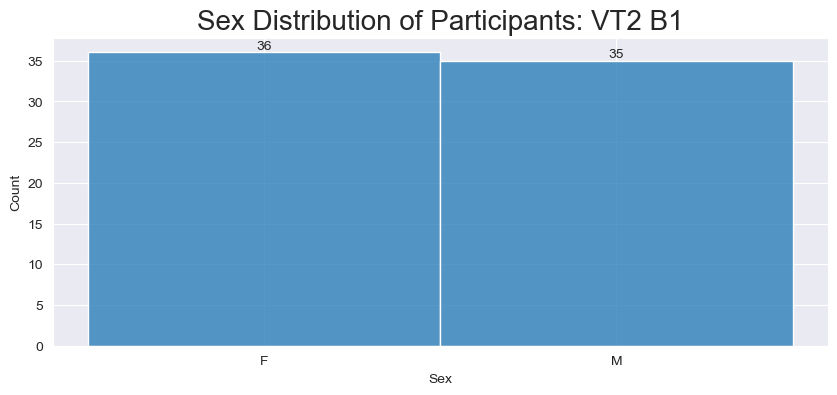

In [120]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=VT2_b1_df, x='sex')

ax1.set_xlabel('Sex')
ax1.set_title('Sex Distribution of Participants: VT2 B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

### VT3 data

In [121]:
# sns.set_style('darkgrid')

# fig, ax = plt.subplots(1,2,figsize=(20,8))

# ### Plot 1: Count missing by variable
# ax1= sns.barplot(x=baa_missing_cols_only['count'], y=baa_missing_cols_only['column'], ax=ax[0])

# ax1.set_xlabel('Count', fontsize=20)
# ax1.set_ylabel('Variable', fontsize=20)
# ax1.tick_params(axis='both', labelsize=15)

# ax1.set_title('Count Missing by Variable: BAA', fontsize=25)


# ### Plot 2- Percent missing by variable
# ax2= sns.barplot(x=baa_missing_cols_only['percent'], y=baa_missing_cols_only['column'], ax=ax[1])

# ax2.set_xlabel('Percent', fontsize=20)
# ax2.set_ylabel('Variable', fontsize=20)
# ax2.set_xticks(np.arange(0,101,20), labels=['0%', '20%', '40%', '60%', '80%', '100%'])
# ax2.tick_params(axis='both', labelsize=15)


# ax2.set_title('Percent Missing by Variable: BAA', fontsize=25)

# plt.tight_layout()
# plt.show()

### WTP data

In [122]:
WTP_df.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,weight,bmi,sex,race,race_text,race_code_cleaned,ethnicity,hispanic,bmi_cat,bmi_code_cat
0,9501,WTP,B1,958.0,1081.0,1033.0,21.0,2.1,23.0,2.1,...,63.64,22.02,F,5.0,White,5.0,2.0,no,Healthy weight,2
1,9502,WTP,B1,851.0,1048.0,946.0,18.0,1.9,29.0,1.9,...,81.82,30.05,F,5.0,White,5.0,2.0,no,Obese,NaN
2,9504,WTP,B1,802.0,1080.0,966.0,46.0,29.9,44.0,4.7,...,65.91,22.81,F,5.0,White,5.0,2.0,no,Healthy weight,2
3,9505,WTP,B1,881.0,1075.0,972.0,24.0,2.6,34.0,2.4,...,50.00,20.28,F,5.0,White,5.0,2.0,no,Healthy weight,2
4,9511,WTP,B1,753.0,897.0,817.0,15.0,0.3,27.0,1.8,...,67.73,26.46,F,5.0,White,5.0,2.0,no,Overweight,3


In [123]:
WTP_missing_values_df = pd.DataFrame({
    'count': WTP_df.isnull().sum(),
    'percent': (WTP_df.isnull().sum() / len(WTP_df)) * 100 
}).sort_values(by='percent', ascending=False).round(2).reset_index().rename(columns={'index': 'column'})

print(WTP_missing_values_df)

               column  count  percent
0        bmi_code_cat     50    28.09
1                race      2     1.12
2                 age      2     1.12
3              height      2     1.12
4              weight      2     1.12
5                 sex      2     1.12
6                 bmi      2     1.12
7           race_text      2     1.12
8   race_code_cleaned      2     1.12
9           ethnicity      2     1.12
10           hispanic      2     1.12
11            bmi_cat      2     1.12
12         from_study      0     0.00
13             RVFDev      0     0.00
14            RVFMean      0     0.00
15           RRIWMean      0     0.00
16                RRI      0     0.00
17            RRISnHf      0     0.00
18            RRISnLf      0     0.00
19                ID6      0     0.00
20             RRISHf      0     0.00
21             RRISLf      0     0.00
22          timepoint      0     0.00
23             RRIMin      0     0.00
24             RRImax      0     0.00
25          

In [124]:
WTP_df_missing_cols_only = WTP_missing_values_df[WTP_missing_values_df['percent'] > 0].copy().sort_values('percent', ascending=False).reset_index(drop=True)

print(WTP_df_missing_cols_only)

               column  count  percent
0        bmi_code_cat     50    28.09
1                race      2     1.12
2                 age      2     1.12
3              height      2     1.12
4              weight      2     1.12
5                 sex      2     1.12
6                 bmi      2     1.12
7           race_text      2     1.12
8   race_code_cleaned      2     1.12
9           ethnicity      2     1.12
10           hispanic      2     1.12
11            bmi_cat      2     1.12


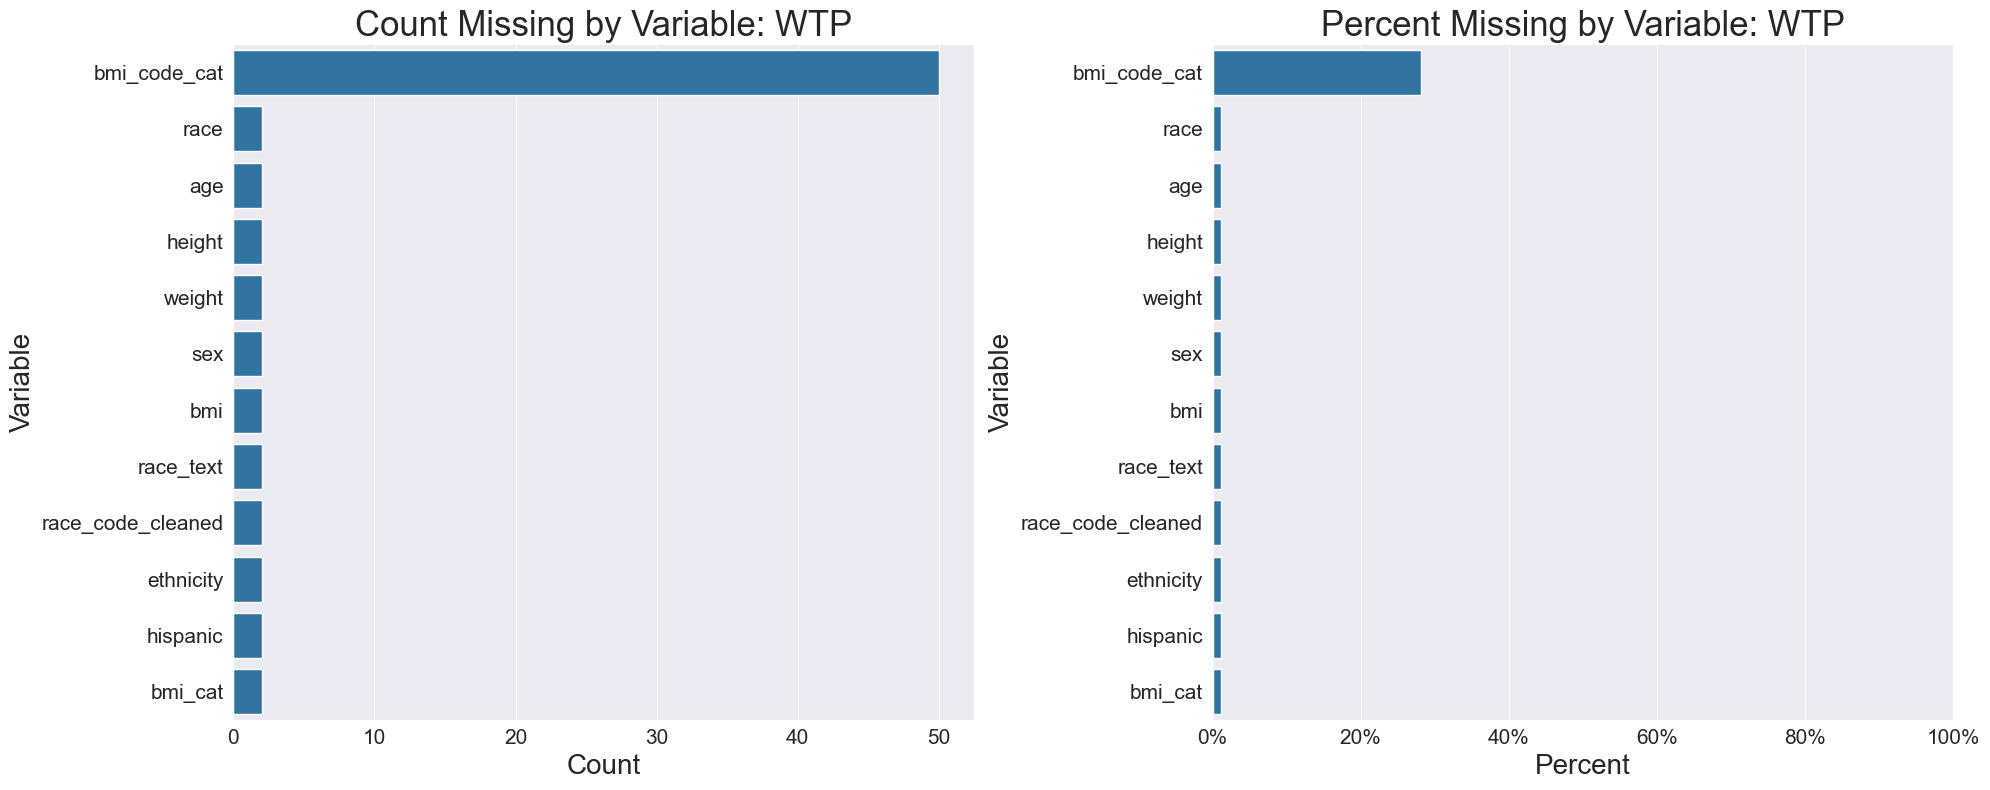

In [125]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1,2,figsize=(20,8))

### Plot 1: Count missing by variable
ax1= sns.barplot(x=WTP_df_missing_cols_only['count'], y=WTP_df_missing_cols_only['column'], ax=ax[0])

ax1.set_xlabel('Count', fontsize=20)
ax1.set_ylabel('Variable', fontsize=20)
ax1.tick_params(axis='both', labelsize=15)

ax1.set_title('Count Missing by Variable: WTP', fontsize=25)


### Plot 2- Percent missing by variable
ax2= sns.barplot(x=WTP_df_missing_cols_only['percent'], y=WTP_df_missing_cols_only['column'], ax=ax[1])

ax2.set_xlabel('Percent', fontsize=20)
ax2.set_ylabel('Variable', fontsize=20)
ax2.set_xticks(np.arange(0,101,20), labels=['0%', '20%', '40%', '60%', '80%', '100%'])
ax2.tick_params(axis='both', labelsize=15)


ax2.set_title('Percent Missing by Variable: WTP', fontsize=25)

plt.tight_layout()
plt.show()

In [126]:
WTP_b1_df = WTP_df[WTP_df['timepoint']=='B1'].copy().reset_index(drop=True)

WTP_b1_df.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,weight,bmi,sex,race,race_text,race_code_cleaned,ethnicity,hispanic,bmi_cat,bmi_code_cat
0,9501,WTP,B1,958.0,1081.0,1033.0,21.0,2.1,23.0,2.1,...,63.64,22.02,F,5.0,White,5.0,2.0,no,Healthy weight,2
1,9502,WTP,B1,851.0,1048.0,946.0,18.0,1.9,29.0,1.9,...,81.82,30.05,F,5.0,White,5.0,2.0,no,Obese,NaN
2,9504,WTP,B1,802.0,1080.0,966.0,46.0,29.9,44.0,4.7,...,65.91,22.81,F,5.0,White,5.0,2.0,no,Healthy weight,2
3,9505,WTP,B1,881.0,1075.0,972.0,24.0,2.6,34.0,2.4,...,50.00,20.28,F,5.0,White,5.0,2.0,no,Healthy weight,2
4,9511,WTP,B1,753.0,897.0,817.0,15.0,0.3,27.0,1.8,...,67.73,26.46,F,5.0,White,5.0,2.0,no,Overweight,3


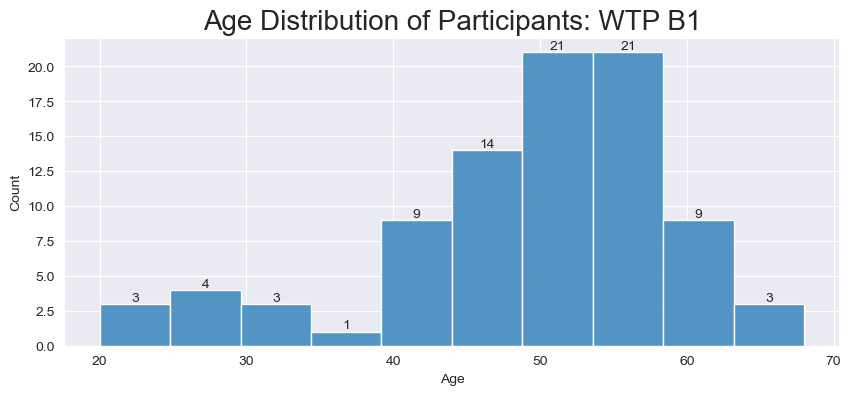

In [127]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=WTP_b1_df, x='age')

ax1.set_xlabel('Age')
ax1.set_title('Age Distribution of Participants: WTP B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

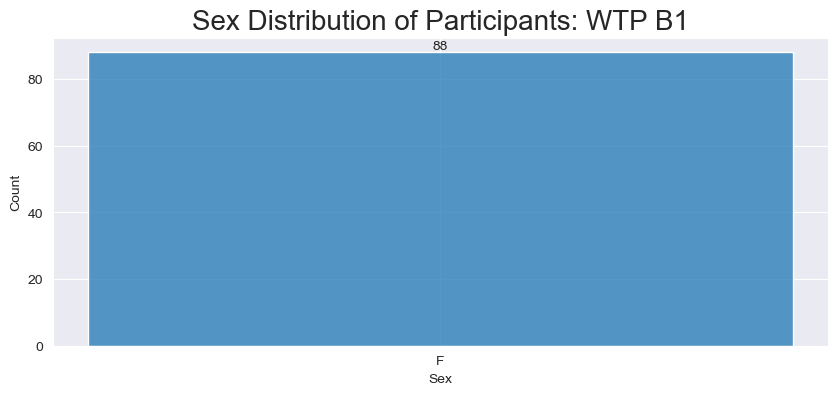

In [128]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=WTP_b1_df, x='sex')

ax1.set_xlabel('Sex')
ax1.set_title('Sex Distribution of Participants: WTP B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

### Athlete

In [129]:
Athlete_df.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,weight,bmi,sex,race,race_text,race_code_cleaned,ethnicity,hispanic,bmi_cat,bmi_code_cat
0,220513,Athlete,B1,NaN,NaN,NaN,25.0,4.4,48.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,222084,Athlete,B1,NaN,NaN,NaN,141.0,63.3,133.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,222513,Athlete,B1,NaN,NaN,NaN,47.0,25.8,80.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,222538,Athlete,B1,NaN,NaN,NaN,43.0,20.9,66.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,223018,Athlete,B1,NaN,NaN,NaN,19.0,0.7,35.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [130]:
Athlete_missing_values_df = pd.DataFrame({
    'count': Athlete_df.isnull().sum(),
    'percent': (Athlete_df.isnull().sum() / len(Athlete_df)) * 100 
}).sort_values(by='percent', ascending=False).round(2).reset_index().rename(columns={'index': 'column'})

print(Athlete_missing_values_df)

               column  count  percent
0            RRISLfHF    218   100.00
1             RRISUlf    218   100.00
2             bmi_cat    218   100.00
3                 bmi    218   100.00
4              weight    218   100.00
5              height    218   100.00
6                 age    218   100.00
7              RVFDev    218   100.00
8             RVFMean    218   100.00
9            RRIWMean    218   100.00
10                RRI    218   100.00
11            RRISnHf    218   100.00
12            RRISnLf    218   100.00
13            RRISVlf    218   100.00
14       bmi_code_cat    218   100.00
15             RRIMin    218   100.00
16              HRMax    218   100.00
17              HRMin    218   100.00
18             RRICvs    218   100.00
19              HRDev    218   100.00
20            RRImean    218   100.00
21             RRImax    218   100.00
22  race_code_cleaned    180    82.57
23          race_text    180    82.57
24               race    180    82.57
25          

In [131]:
Athlete_missing__missing_cols_only = Athlete_missing_values_df[Athlete_missing_values_df['percent'] > 0].copy().sort_values('percent', ascending=False).reset_index(drop=True)

print(Athlete_missing__missing_cols_only)

               column  count  percent
0            RRISLfHF    218   100.00
1             RRISnLf    218   100.00
2              RRImax    218   100.00
3             RRImean    218   100.00
4               HRDev    218   100.00
5              RRICvs    218   100.00
6             RRISUlf    218   100.00
7               HRMax    218   100.00
8              RRIMin    218   100.00
9        bmi_code_cat    218   100.00
10            RRISVlf    218   100.00
11              HRMin    218   100.00
12            RRISnHf    218   100.00
13                RRI    218   100.00
14           RRIWMean    218   100.00
15            RVFMean    218   100.00
16             RVFDev    218   100.00
17                age    218   100.00
18             height    218   100.00
19             weight    218   100.00
20                bmi    218   100.00
21            bmi_cat    218   100.00
22               race    180    82.57
23          race_text    180    82.57
24  race_code_cleaned    180    82.57
25          

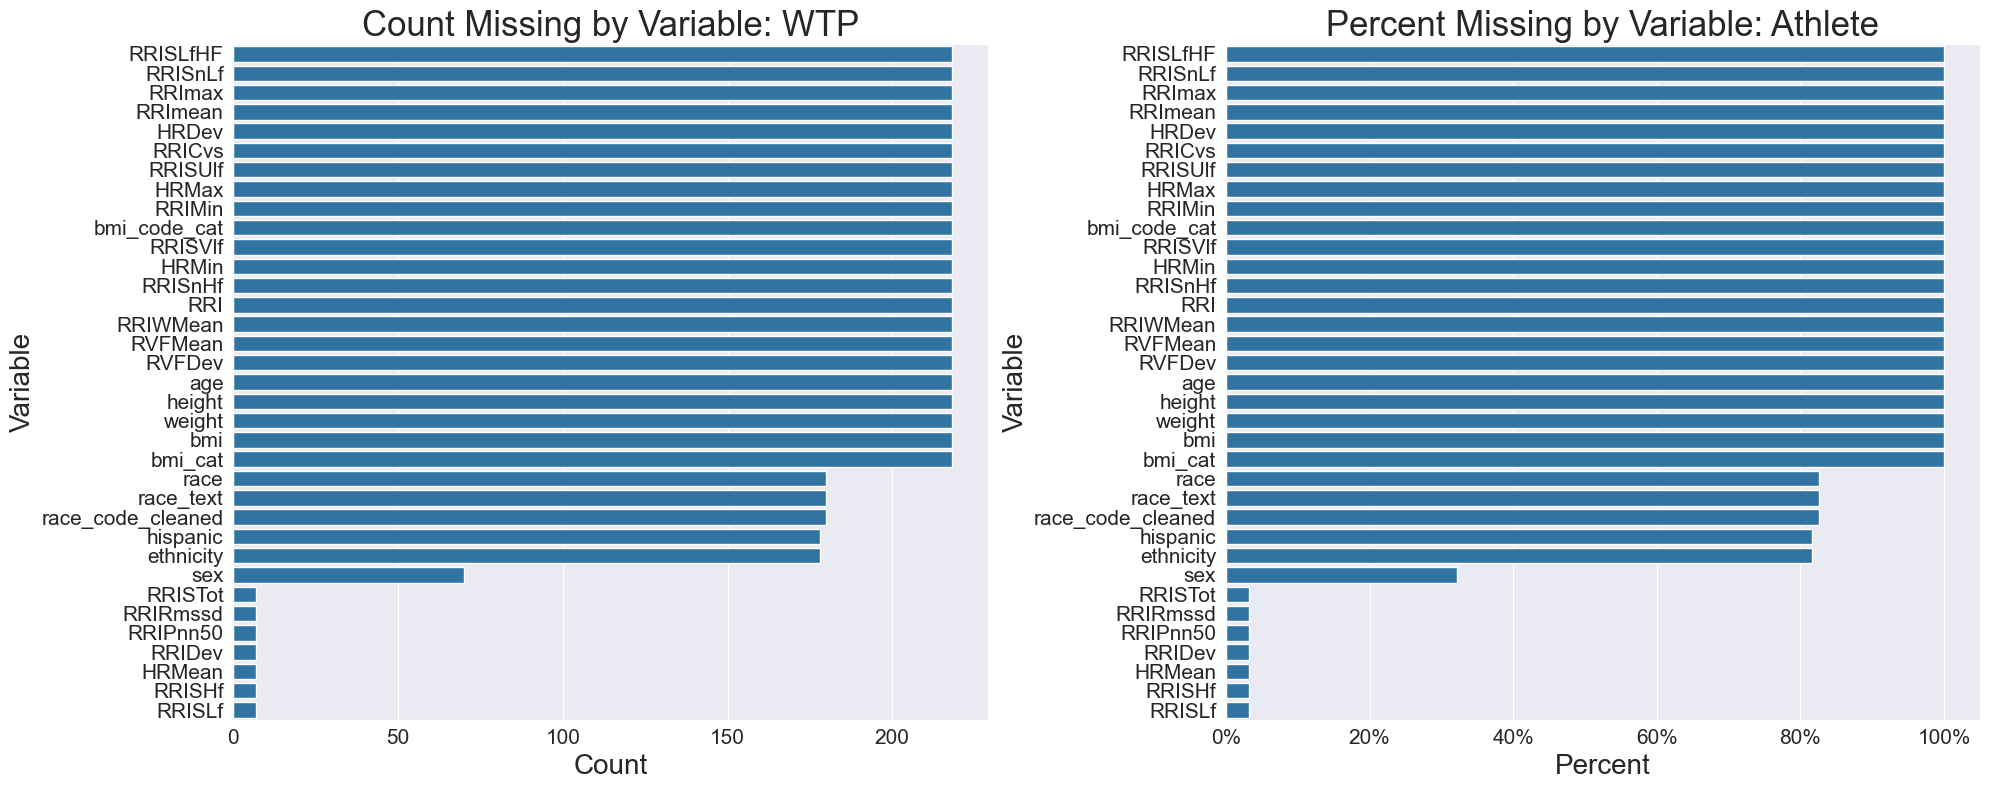

In [132]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1,2,figsize=(20,8))

### Plot 1: Count missing by variable
ax1= sns.barplot(x=Athlete_missing__missing_cols_only['count'], y=Athlete_missing__missing_cols_only['column'], ax=ax[0])

ax1.set_xlabel('Count', fontsize=20)
ax1.set_ylabel('Variable', fontsize=20)
ax1.tick_params(axis='both', labelsize=15)

ax1.set_title('Count Missing by Variable: WTP', fontsize=25)


### Plot 2- Percent missing by variable
ax2= sns.barplot(x=Athlete_missing__missing_cols_only['percent'], y=Athlete_missing__missing_cols_only['column'], ax=ax[1])

ax2.set_xlabel('Percent', fontsize=20)
ax2.set_ylabel('Variable', fontsize=20)
ax2.set_xticks(np.arange(0,101,20), labels=['0%', '20%', '40%', '60%', '80%', '100%'])
ax2.tick_params(axis='both', labelsize=15)


ax2.set_title('Percent Missing by Variable: Athlete', fontsize=25)

plt.tight_layout()
plt.show()